In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Classification records:", len(classification_manifest))

print("\nClasses:")
print(classification_manifest["tumor_label"].value_counts())

print("\nSplits:")
print(classification_manifest["split"].value_counts())

Project directory: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor
Dataset directory: D:\MSC Bioinformatics\INTERNSHIP\brisc2025
Classification records: 6000

Classes:
tumor_label
pituitary     1757
meningioma    1635
glioma        1401
no_tumor      1207
Name: count, dtype: int64

Splits:
split
train    5000
test     1000
Name: count, dtype: int64


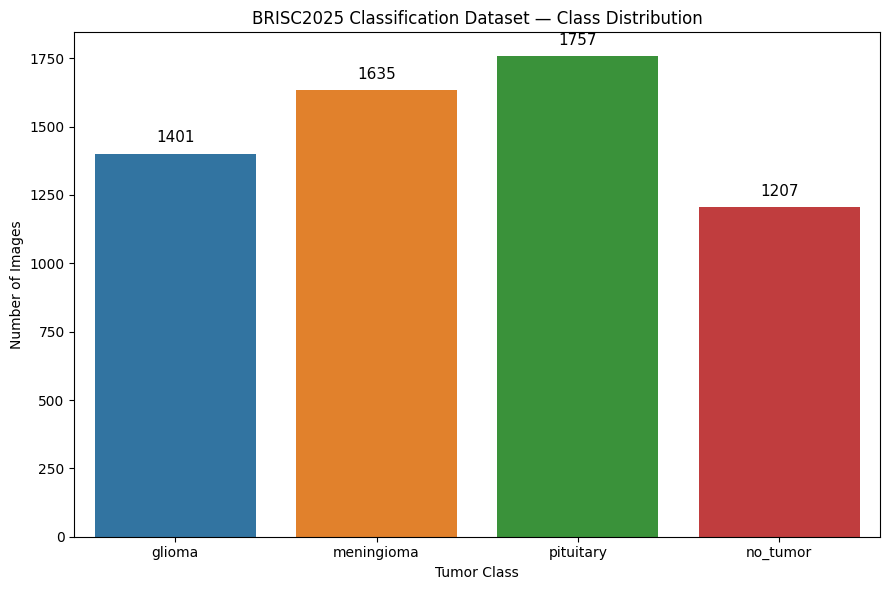

In [2]:
class_counts = (
    classification_manifest["tumor_label"]
    .value_counts()
    .reindex(["glioma", "meningioma", "pituitary", "no_tumor"])
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("BRISC2025 Classification Dataset — Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

for i, value in enumerate(class_counts.values):
    ax.text(
        i,
        value + 30,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

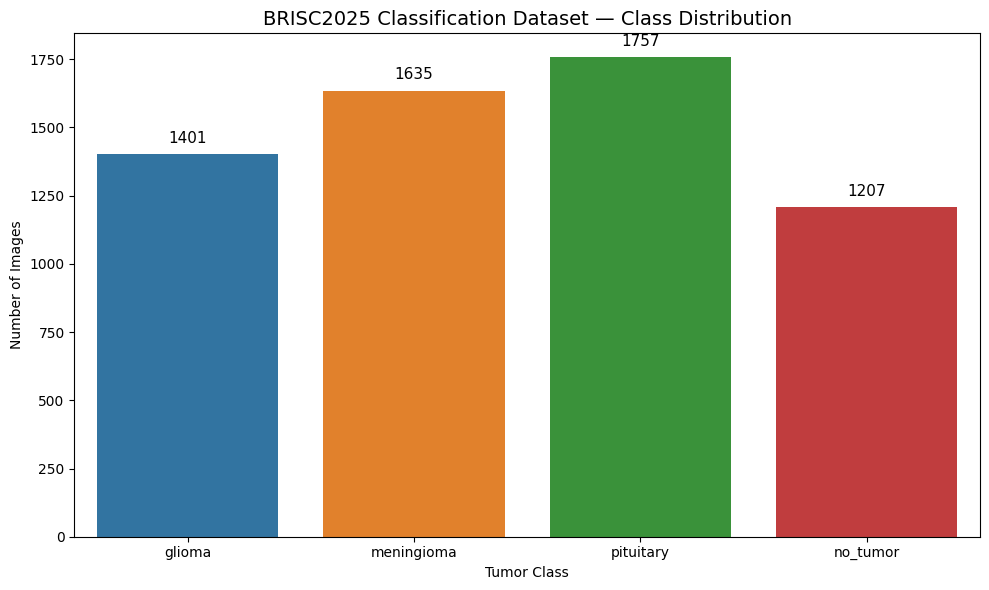

Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\01_class_distribution.png


In [3]:
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

class_counts = (
    classification_manifest["tumor_label"]
    .value_counts()
    .reindex(["glioma", "meningioma", "pituitary", "no_tumor"])
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("BRISC2025 Classification Dataset — Class Distribution", fontsize=14)
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

for i, value in enumerate(class_counts.values):
    ax.text(
        i,
        value + 30,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

figure_path = FIGURES_DIR / "01_class_distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [4]:
thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "w", encoding="utf-8") as f:
    f.write("# BRISC2025 Dataset Analysis — Thesis Records\n\n")

    f.write("## 1. Dataset Overview\n\n")
    f.write("- Classification dataset: 6,000 images\n")
    f.write("- Training images: 5,000\n")
    f.write("- Test images: 1,000\n")
    f.write("- Number of tumor classes: 4\n")
    f.write("- MRI sequence: T1\n")
    f.write("- MRI planes: axial, coronal, sagittal\n\n")

    f.write("## 2. Class Distribution\n\n")
    f.write("| Class | Number of Images | Percentage |\n")
    f.write("|---|---:|---:|\n")

    total = len(classification_manifest)

    for class_name, count in class_counts.items():
        percentage = (count / total) * 100
        f.write(
            f"| {class_name} | {count} | {percentage:.2f}% |\n"
        )

    f.write("\n### Interpretation\n\n")
    f.write(
        "The classification dataset contains four classes with moderate "
        "class imbalance. Pituitary tumor images constitute the largest "
        "class, while no-tumor images constitute the smallest class. "
        "The imbalance should be considered during model training and "
        "evaluation, with class-wise metrics reported alongside overall accuracy.\n\n"
    )

    f.write("### Figure\n\n")
    f.write(
        "Figure: BRISC2025 classification dataset class distribution. "
        "Saved as `outputs/figures/01_class_distribution.png`.\n"
    )

print("Thesis record saved to:")
print(thesis_record)

Thesis record saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


Train/Test class counts:


split,test,train
tumor_label,,
glioma,254,1147
meningioma,306,1329
pituitary,300,1457
no_tumor,140,1067


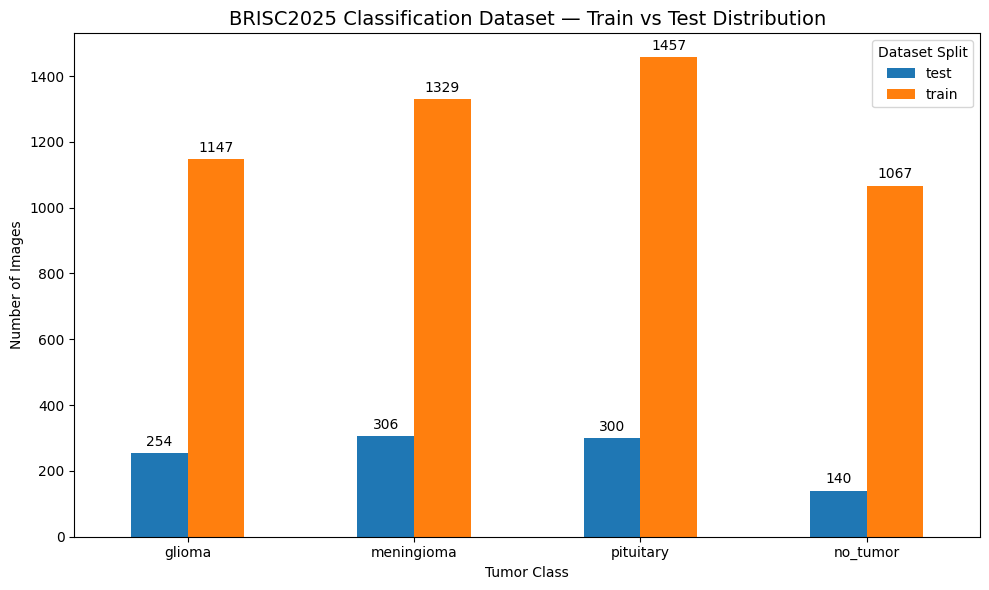

Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\02_train_test_class_distribution.png


In [5]:
split_class_counts = (
    classification_manifest
    .groupby(["tumor_label", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(["glioma", "meningioma", "pituitary", "no_tumor"])
)

print("Train/Test class counts:")
display(split_class_counts)

ax = split_class_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("BRISC2025 Classification Dataset — Train vs Test Distribution", fontsize=14)
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()

figure_path = FIGURES_DIR / "02_train_test_class_distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [6]:
with open(thesis_record, "a", encoding="utf-8") as f:
    f.write("\n## 3. Train-Test Class Distribution\n\n")

    f.write("| Class | Train | Test | Total |\n")
    f.write("|---|---:|---:|---:|\n")

    for class_name in ["glioma", "meningioma", "pituitary", "no_tumor"]:
        train_count = split_class_counts.loc[class_name, "train"]
        test_count = split_class_counts.loc[class_name, "test"]
        total_count = train_count + test_count

        f.write(
            f"| {class_name} | {train_count} | "
            f"{test_count} | {total_count} |\n"
        )

    f.write("\n### Interpretation\n\n")
    f.write(
        "The BRISC2025 classification dataset contains a predefined "
        "training set of 5,000 images and a test set of 1,000 images. "
        "All four tumor classes are represented in both splits. "
        "The class proportions differ between the training and test "
        "sets, therefore model evaluation should include class-wise "
        "performance metrics in addition to overall accuracy.\n\n"
    )

    f.write(
        "Figure: Train versus test class distribution. "
        "Saved as `outputs/figures/02_train_test_class_distribution.png`.\n"
    )

print("Train/test analysis added to thesis records.")
print(thesis_record)

Train/test analysis added to thesis records.
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


RGB vs GRAYSCALE DISTRIBUTION


mode,L,RGB
tumor_label,,
glioma,1227,174
meningioma,709,926
pituitary,930,827
no_tumor,0,1207



Overall image-mode distribution:
mode
RGB    3134
L      2866
Name: count, dtype: int64

Percentage distribution within each class:


mode,L,RGB
tumor_label,,
glioma,87.58,12.42
meningioma,43.36,56.64
pituitary,52.93,47.07
no_tumor,0.00,100.00


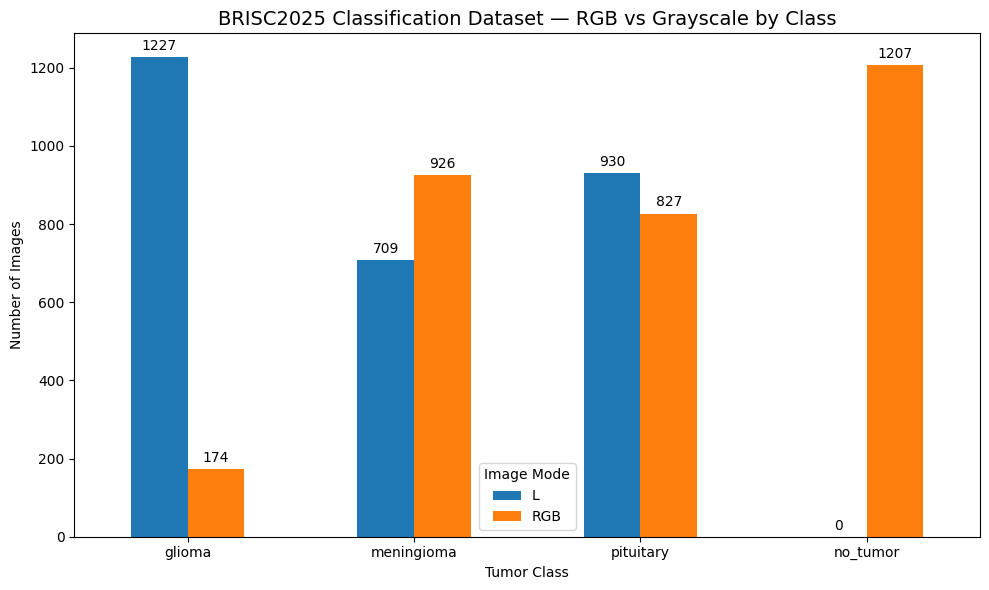


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\03_rgb_grayscale_by_class.png

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


In [7]:
# =========================================================
# CELL 6 — RGB vs Grayscale Analysis
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Project and dataset paths
PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

# Output directories
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Load manifest
MANIFEST_PATH = DATASET_DIR / "manifest.csv"
manifest = pd.read_csv(MANIFEST_PATH)

# Keep classification dataset only
classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# Determine actual image mode
def get_image_mode(relative_path):
    image_path = DATASET_DIR / relative_path

    try:
        with Image.open(image_path) as image:
            return image.mode
    except Exception:
        return "Unreadable"

classification_manifest["mode"] = (
    classification_manifest["relative_path"]
    .apply(get_image_mode)
)

# ---------------------------------------------------------
# Numerical analysis
# ---------------------------------------------------------

mode_class_counts = pd.crosstab(
    classification_manifest["tumor_label"],
    classification_manifest["mode"]
).reindex(
    ["glioma", "meningioma", "pituitary", "no_tumor"]
).fillna(0).astype(int)

print("=" * 60)
print("RGB vs GRAYSCALE DISTRIBUTION")
print("=" * 60)

display(mode_class_counts)

print("\nOverall image-mode distribution:")
print(
    classification_manifest["mode"]
    .value_counts()
)

# ---------------------------------------------------------
# Calculate percentages within each class
# ---------------------------------------------------------

mode_percentages = (
    mode_class_counts
    .div(mode_class_counts.sum(axis=1), axis=0)
    * 100
)

print("\nPercentage distribution within each class:")
display(mode_percentages.round(2))

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

ax = mode_class_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "BRISC2025 Classification Dataset — RGB vs Grayscale by Class",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Image Mode")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

figure_path = FIGURES_DIR / "03_rgb_grayscale_by_class.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save results to thesis record
# ---------------------------------------------------------

thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "a", encoding="utf-8") as f:

    f.write("\n\n## 4. RGB vs Grayscale Image Representation\n\n")

    f.write(
        "The classification dataset contains both RGB and grayscale "
        "images. Image mode was determined directly from the image files "
        "using the Pillow library.\n\n"
    )

    f.write("| Class | Grayscale | RGB | Total |\n")
    f.write("|---|---:|---:|---:|\n")

    for class_name in [
        "glioma",
        "meningioma",
        "pituitary",
        "no_tumor"
    ]:

        grayscale = mode_class_counts.loc[class_name].get("L", 0)
        rgb = mode_class_counts.loc[class_name].get("RGB", 0)

        total = grayscale + rgb

        f.write(
            f"| {class_name} | {grayscale} | "
            f"{rgb} | {total} |\n"
        )

    f.write("\n### Within-Class Percentages\n\n")

    f.write("| Class | Grayscale (%) | RGB (%) |\n")
    f.write("|---|---:|---:|\n")

    for class_name in [
        "glioma",
        "meningioma",
        "pituitary",
        "no_tumor"
    ]:

        grayscale_pct = mode_percentages.loc[class_name].get("L", 0)
        rgb_pct = mode_percentages.loc[class_name].get("RGB", 0)

        f.write(
            f"| {class_name} | {grayscale_pct:.2f} | "
            f"{rgb_pct:.2f} |\n"
        )

    f.write("\n### Interpretation\n\n")

    f.write(
        "A substantial difference in image representation was observed "
        "between tumor classes. In particular, all no-tumor images in the "
        "classification dataset were stored as RGB, whereas glioma, "
        "meningioma, and pituitary classes contained both RGB and "
        "grayscale images. Because image representation is associated "
        "with the class label, directly training on the original image "
        "modes could allow a model to exploit representation-related "
        "features rather than pathology-related features. Therefore, "
        "the planned preprocessing pipeline will standardize all "
        "classification images to a common RGB representation before "
        "model training.\n\n"
    )

    f.write(
        "Figure: RGB versus grayscale distribution by tumor class. "
        "Saved as `outputs/figures/03_rgb_grayscale_by_class.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

RGB vs GRAYSCALE BY CLASS AND DATASET SPLIT


mode                  L   RGB
tumor_label split            
glioma      train  1038   109
            test    189    65
meningioma  train   549   780
            test    160   146
pituitary   train   697   760
            test    233    67
no_tumor    train     0  1067
            test      0   140


OVERALL IMAGE MODE BY SPLIT:


mode,L,RGB
split,,
test,582,418
train,2284,2716



PERCENTAGE WITHIN EACH CLASS AND SPLIT:


mode                   L     RGB
tumor_label split               
glioma      train  90.50    9.50
            test   74.41   25.59
meningioma  train  41.31   58.69
            test   52.29   47.71
pituitary   train  47.84   52.16
            test   77.67   22.33
no_tumor    train   0.00  100.00
            test    0.00  100.00

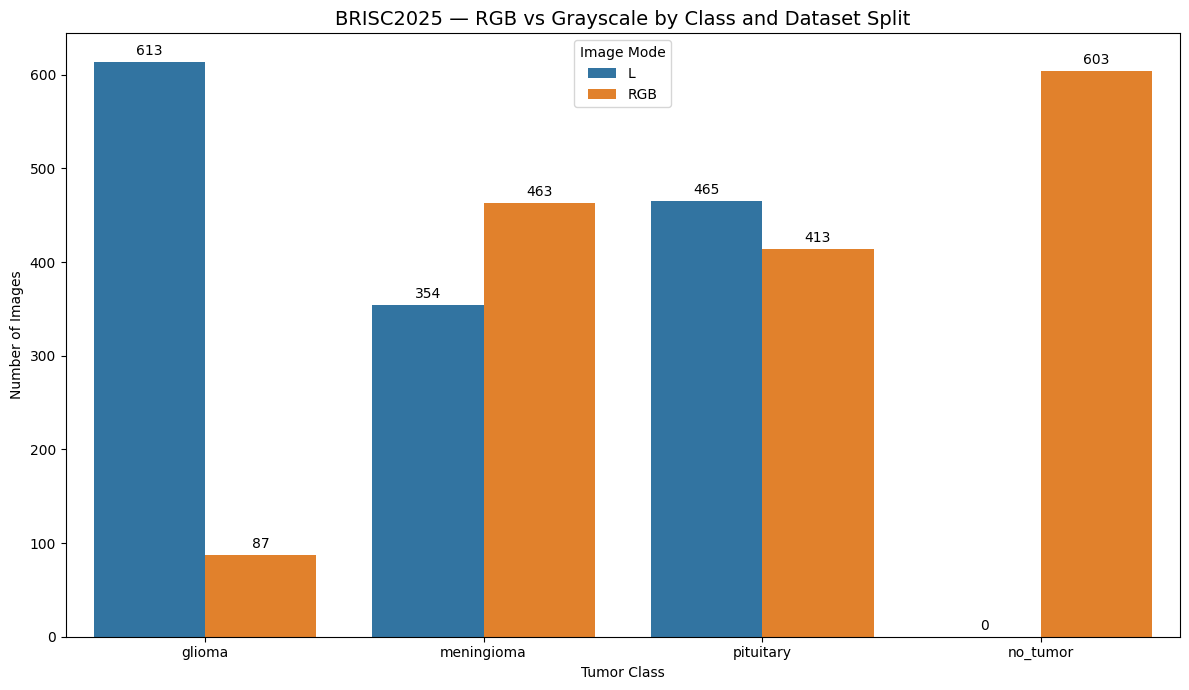


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\04_rgb_grayscale_by_class_and_split.png

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


In [8]:
# =========================================================
# CELL 7 — RGB vs Grayscale by Train/Test Split
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Determine image mode
# ---------------------------------------------------------

def get_image_mode(relative_path):
    image_path = DATASET_DIR / relative_path

    try:
        with Image.open(image_path) as image:
            return image.mode
    except Exception:
        return "Unreadable"

classification_manifest["mode"] = (
    classification_manifest["relative_path"]
    .apply(get_image_mode)
)

# ---------------------------------------------------------
# Create split × mode × class table
# ---------------------------------------------------------

mode_split_class = pd.crosstab(
    [
        classification_manifest["tumor_label"],
        classification_manifest["split"]
    ],
    classification_manifest["mode"]
)

mode_split_class = mode_split_class.reindex(
    pd.MultiIndex.from_product(
        [
            ["glioma", "meningioma", "pituitary", "no_tumor"],
            ["train", "test"]
        ],
        names=["tumor_label", "split"]
    ),
    fill_value=0
)

print("=" * 70)
print("RGB vs GRAYSCALE BY CLASS AND DATASET SPLIT")
print("=" * 70)

display(mode_split_class)

# ---------------------------------------------------------
# Overall train/test mode distribution
# ---------------------------------------------------------

overall_split_mode = pd.crosstab(
    classification_manifest["split"],
    classification_manifest["mode"]
)

print("\nOVERALL IMAGE MODE BY SPLIT:")
display(overall_split_mode)

# ---------------------------------------------------------
# Calculate percentages within each class and split
# ---------------------------------------------------------

mode_split_percentages = (
    mode_split_class
    .div(mode_split_class.sum(axis=1), axis=0)
    * 100
)

print("\nPERCENTAGE WITHIN EACH CLASS AND SPLIT:")
display(mode_split_percentages.round(2))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plot_data = mode_split_class.reset_index()

plot_data = plot_data.melt(
    id_vars=["tumor_label", "split"],
    value_vars=["L", "RGB"],
    var_name="Image Mode",
    value_name="Number of Images"
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=plot_data,
    x="tumor_label",
    y="Number of Images",
    hue="Image Mode",
    errorbar=None
)

plt.title(
    "BRISC2025 — RGB vs Grayscale by Class and Dataset Split",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "04_rgb_grayscale_by_class_and_split.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "a", encoding="utf-8") as f:

    f.write(
        "\n\n## 5. RGB vs Grayscale Representation by Dataset Split\n\n"
    )

    f.write(
        "Image representation was further examined separately within "
        "the predefined training and test splits.\n\n"
    )

    f.write(
        "| Class | Split | Grayscale | RGB | Total |\n"
    )
    f.write(
        "|---|---|---:|---:|---:|\n"
    )

    for class_name in [
        "glioma",
        "meningioma",
        "pituitary",
        "no_tumor"
    ]:

        for split_name in ["train", "test"]:

            row = mode_split_class.loc[
                (class_name, split_name)
            ]

            grayscale = row.get("L", 0)
            rgb = row.get("RGB", 0)
            total = grayscale + rgb

            f.write(
                f"| {class_name} | {split_name} | "
                f"{grayscale} | {rgb} | {total} |\n"
            )

    f.write("\n### Interpretation\n\n")

    f.write(
        "The analysis demonstrates that the difference in image "
        "representation is present in both the training and test "
        "splits. Notably, all no-tumor images are represented as RGB "
        "in both splits. Consequently, the original image representation "
        "could potentially provide a non-pathological statistical cue "
        "associated with the target class. To reduce this potential "
        "shortcut, all classification images will be converted to a "
        "common RGB representation during preprocessing. This "
        "standardization will be applied consistently to training, "
        "validation, and test images.\n\n"
    )

    f.write(
        "Figure: RGB versus grayscale distribution by class and "
        "dataset split. Saved as "
        "`outputs/figures/04_rgb_grayscale_by_class_and_split.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

MRI PLANE DISTRIBUTION BY TUMOR CLASS


plane_label,axial,coronal,sagittal
tumor_label,,,
glioma,479,511,411
meningioma,560,512,563
pituitary,550,600,607
no_tumor,404,358,445



Overall plane distribution:


plane_label
axial       1993
coronal     1981
sagittal    2026
Name: count, dtype: int64


Percentage distribution within each class:


plane_label,axial,coronal,sagittal
tumor_label,,,
glioma,34.19,36.47,29.34
meningioma,34.25,31.31,34.43
pituitary,31.30,34.15,34.55
no_tumor,33.47,29.66,36.87



Plane distribution by class and split:


plane_label        axial  coronal  sagittal
tumor_label split                          
glioma      train    394      430       323
            test      85       81        88
meningioma  train    423      426       480
            test     137       86        83
pituitary   train    426      510       521
            test     124       90        86
no_tumor    train    352      310       405
            test      52       48        40

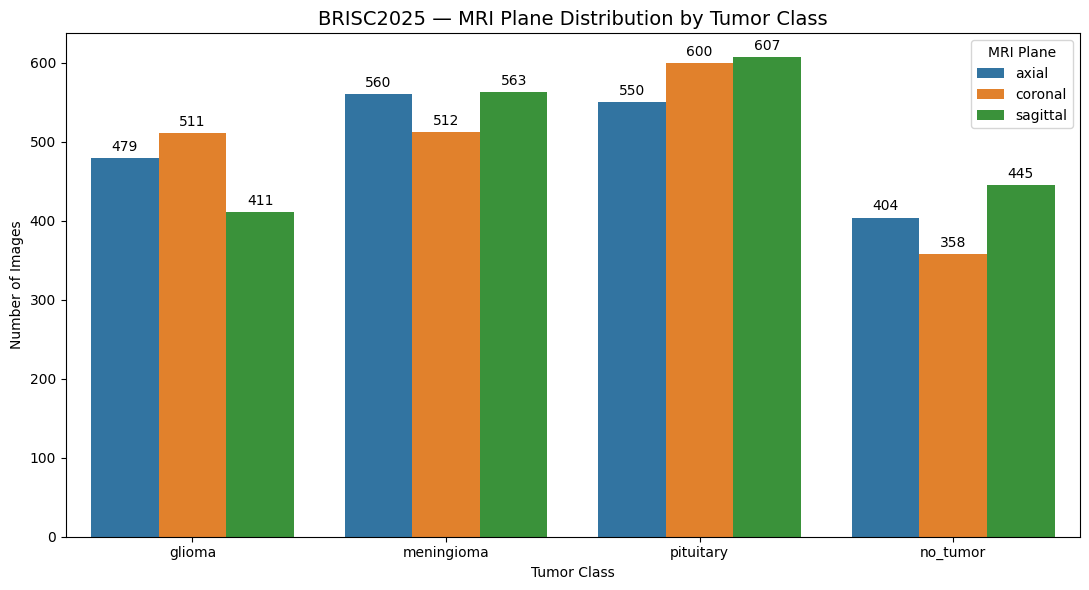


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\05_mri_plane_distribution_by_class.png

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


In [9]:
# =========================================================
# CELL 8 — MRI Plane Distribution by Tumor Class
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Plane distribution
# ---------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

plane_order = [
    "axial",
    "coronal",
    "sagittal"
]

plane_class_counts = pd.crosstab(
    classification_manifest["tumor_label"],
    classification_manifest["plane_label"]
).reindex(
    index=class_order,
    columns=plane_order,
    fill_value=0
)

print("=" * 70)
print("MRI PLANE DISTRIBUTION BY TUMOR CLASS")
print("=" * 70)

display(plane_class_counts)

print("\nOverall plane distribution:")

overall_plane_counts = (
    classification_manifest["plane_label"]
    .value_counts()
    .reindex(plane_order)
)

display(overall_plane_counts)

# ---------------------------------------------------------
# Percentages within each class
# ---------------------------------------------------------

plane_class_percentages = (
    plane_class_counts
    .div(plane_class_counts.sum(axis=1), axis=0)
    * 100
)

print("\nPercentage distribution within each class:")

display(
    plane_class_percentages.round(2)
)

# ---------------------------------------------------------
# Train/Test plane distribution
# ---------------------------------------------------------

plane_split_counts = pd.crosstab(
    [
        classification_manifest["tumor_label"],
        classification_manifest["split"]
    ],
    classification_manifest["plane_label"]
).reindex(
    pd.MultiIndex.from_product(
        [
            class_order,
            ["train", "test"]
        ],
        names=["tumor_label", "split"]
    ),
    fill_value=0
)

print("\nPlane distribution by class and split:")

display(plane_split_counts)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

plot_data = plane_class_counts.reset_index()

plot_data = plot_data.melt(
    id_vars="tumor_label",
    value_vars=plane_order,
    var_name="MRI Plane",
    value_name="Number of Images"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=plot_data,
    x="tumor_label",
    y="Number of Images",
    hue="MRI Plane",
    errorbar=None
)

plt.title(
    "BRISC2025 — MRI Plane Distribution by Tumor Class",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "05_mri_plane_distribution_by_class.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "a", encoding="utf-8") as f:

    f.write("\n\n## 6. MRI Plane Distribution\n\n")

    f.write(
        "The classification dataset contains images from three "
        "MRI anatomical planes: axial, coronal, and sagittal.\n\n"
    )

    f.write("| Class | Axial | Coronal | Sagittal | Total |\n")
    f.write("|---|---:|---:|---:|---:|\n")

    for class_name in class_order:

        axial = plane_class_counts.loc[class_name, "axial"]
        coronal = plane_class_counts.loc[class_name, "coronal"]
        sagittal = plane_class_counts.loc[class_name, "sagittal"]

        total = axial + coronal + sagittal

        f.write(
            f"| {class_name} | {axial} | {coronal} | "
            f"{sagittal} | {total} |\n"
        )

    f.write("\n### Overall Plane Distribution\n\n")

    f.write("| MRI Plane | Number of Images | Percentage |\n")
    f.write("|---|---:|---:|\n")

    total_images = len(classification_manifest)

    for plane in plane_order:

        count = overall_plane_counts[plane]
        percentage = (count / total_images) * 100

        f.write(
            f"| {plane} | {count} | {percentage:.2f}% |\n"
        )

    f.write("\n### Interpretation\n\n")

    f.write(
        "The classification dataset contains axial, coronal, and "
        "sagittal MRI images. The distribution of anatomical planes "
        "is relatively balanced across the four tumor classes, with "
        "no single plane being exclusive to a particular class. "
        "Therefore, all three anatomical planes will be retained "
        "during model development rather than excluding images based "
        "on plane orientation.\n\n"
    )

    f.write(
        "Figure: MRI plane distribution by tumor class. "
        "Saved as `outputs/figures/05_mri_plane_distribution_by_class.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

IMAGE DIMENSION ANALYSIS

Number of unique width × height combinations: 183

Top 20 most common image dimensions:


,width,height,count
157,512,512,4881
126,369,369,363
34,216,369,354
80,256,256,32
2,187,369,21
42,225,225,20
14,202,369,19
23,210,369,12
65,236,236,11
138,442,442,10



512 × 512 images: 4881
Percentage 512 × 512: 81.35 %

Non-512 × 512 images: 1119
Percentage non-512 × 512: 18.65 %

Width statistics:


count    6000.000000
mean      472.569500
std        96.616831
min       174.000000
25%       512.000000
50%       512.000000
75%       512.000000
max      1365.000000
Name: width, dtype: float64


Height statistics:


count    6000.000000
mean      483.878667
std        71.901930
min       195.000000
25%       512.000000
50%       512.000000
75%       512.000000
max      1427.000000
Name: height, dtype: float64

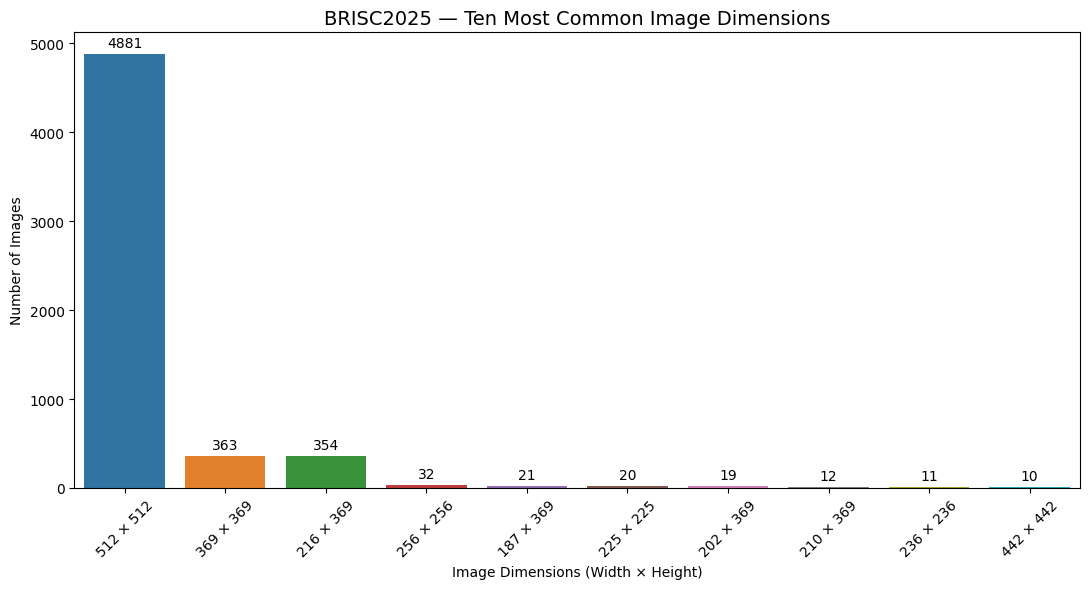


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\06_top_image_dimensions.png

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


In [10]:
# =========================================================
# CELL 9 — Image Dimension Analysis
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Dimension counts
# ---------------------------------------------------------

dimension_counts = (
    classification_manifest
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=" * 70)
print("IMAGE DIMENSION ANALYSIS")
print("=" * 70)

print(
    "\nNumber of unique width × height combinations:",
    len(dimension_counts)
)

print("\nTop 20 most common image dimensions:")

display(
    dimension_counts.head(20)
)

# ---------------------------------------------------------
# 512 × 512 analysis
# ---------------------------------------------------------

is_512 = (
    (classification_manifest["width"] == 512) &
    (classification_manifest["height"] == 512)
)

count_512 = is_512.sum()
percentage_512 = (count_512 / len(classification_manifest)) * 100

count_non_512 = len(classification_manifest) - count_512
percentage_non_512 = (count_non_512 / len(classification_manifest)) * 100

print("\n512 × 512 images:", count_512)
print("Percentage 512 × 512:", round(percentage_512, 2), "%")

print("\nNon-512 × 512 images:", count_non_512)
print(
    "Percentage non-512 × 512:",
    round(percentage_non_512, 2),
    "%"
)

# ---------------------------------------------------------
# Dimension statistics
# ---------------------------------------------------------

print("\nWidth statistics:")
display(
    classification_manifest["width"].describe()
)

print("\nHeight statistics:")
display(
    classification_manifest["height"].describe()
)

# ---------------------------------------------------------
# Most common dimensions plot
# ---------------------------------------------------------

top_dimensions = dimension_counts.head(10).copy()

top_dimensions["dimension"] = (
    top_dimensions["width"].astype(str)
    + " × "
    + top_dimensions["height"].astype(str)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_dimensions,
    x="dimension",
    y="count",
    errorbar=None
)

plt.title(
    "BRISC2025 — Ten Most Common Image Dimensions",
    fontsize=14
)

plt.xlabel("Image Dimensions (Width × Height)")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "06_top_image_dimensions.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "a", encoding="utf-8") as f:

    f.write("\n\n## 7. Image Dimension Analysis\n\n")

    f.write(
        f"The classification dataset contains "
        f"{len(dimension_counts)} unique width × height "
        f"combinations across 6,000 images.\n\n"
    )

    f.write("| Dimension Category | Number of Images | Percentage |\n")
    f.write("|---|---:|---:|\n")

    f.write(
        f"| 512 × 512 | {count_512} | "
        f"{percentage_512:.2f}% |\n"
    )

    f.write(
        f"| Other dimensions | {count_non_512} | "
        f"{percentage_non_512:.2f}% |\n"
    )

    f.write("\n### Top 20 Dimensions\n\n")

    f.write("| Rank | Width | Height | Count |\n")
    f.write("|---:|---:|---:|---:|\n")

    for rank, (_, row) in enumerate(
        dimension_counts.head(20).iterrows(),
        start=1
    ):

        f.write(
            f"| {rank} | {int(row['width'])} | "
            f"{int(row['height'])} | {int(row['count'])} |\n"
        )

    f.write("\n### Interpretation\n\n")

    f.write(
        "Substantial variation in image dimensions was observed in the "
        "classification dataset. Although 4,881 images (81.35%) have "
        "dimensions of 512 × 512 pixels, the remaining images exhibit "
        "multiple different width and height combinations. Therefore, "
        "a fixed input size will be required for CNN-based classification. "
        "The preprocessing pipeline will resize all images to a common "
        "model input resolution while preserving the anatomical image "
        "content as much as possible.\n\n"
    )

    f.write(
        "Figure: Ten most common image dimensions. "
        "Saved as `outputs/figures/06_top_image_dimensions.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

ASPECT RATIO AND SQUARE IMAGE ANALYSIS

Total classification images: 6000

Square images: 5341 (89.02%)
Non-square images: 659 (10.98%)

ASPECT RATIO STATISTICS:


,aspect_ratio
count,6000.000000
mean,0.969283
std,0.110219
min,0.506775
25%,1.000000
50%,1.000000
75%,1.000000
max,1.610256



MOST WIDE IMAGES:


,filename,tumor_label,split,width,height,aspect_ratio
284,brisc2025_test_00285_me_ax_t1.jpg,meningioma,test,314,195,1.610256
2998,brisc2025_train_01999_me_sa_t1.jpg,meningioma,train,420,264,1.590909
391,brisc2025_test_00392_me_co_t1.jpg,meningioma,test,440,278,1.582734
2608,brisc2025_train_01609_me_co_t1.jpg,meningioma,train,497,320,1.553125
2799,brisc2025_train_01800_me_co_t1.jpg,meningioma,train,507,340,1.491176
2999,brisc2025_train_02000_me_sa_t1.jpg,meningioma,train,630,423,1.489362
477,brisc2025_test_00478_me_sa_t1.jpg,meningioma,test,630,423,1.489362
488,brisc2025_test_00489_me_sa_t1.jpg,meningioma,test,645,439,1.469248
3011,brisc2025_train_02012_me_sa_t1.jpg,meningioma,train,645,439,1.469248
2607,brisc2025_train_01608_me_co_t1.jpg,meningioma,train,507,362,1.400552



MOST TALL IMAGES:


...


PERCENTAGE SQUARE vs NON-SQUARE BY CLASS:


,Non-square,Square
tumor_label,,
glioma,0.00,100.00
meningioma,12.78,87.22
no_tumor,36.70,63.30
pituitary,0.40,99.60



SQUARE vs NON-SQUARE BY SPLIT:


,Non-square,Square
split,,
test,176,824
train,483,4517


c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


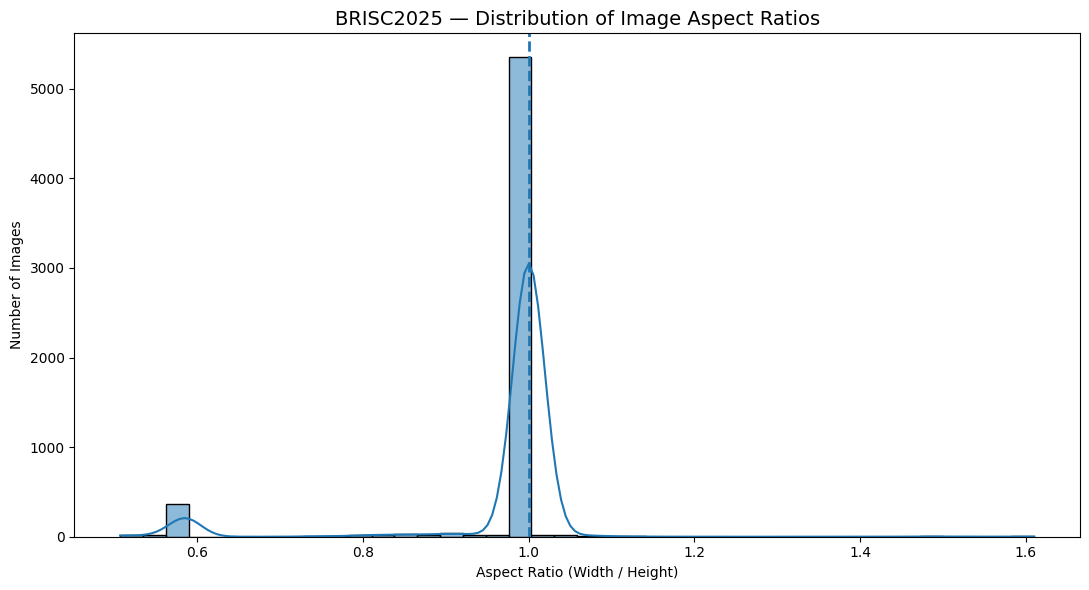


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\07_aspect_ratio_distribution.png

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md


In [11]:
# =========================================================
# CELL 10 — Aspect Ratio & Non-Square Image Analysis
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Calculate aspect ratio
# ---------------------------------------------------------

classification_manifest["aspect_ratio"] = (
    classification_manifest["width"] /
    classification_manifest["height"]
)

# ---------------------------------------------------------
# Square vs non-square
# ---------------------------------------------------------

classification_manifest["is_square"] = (
    classification_manifest["width"] ==
    classification_manifest["height"]
)

square_count = classification_manifest["is_square"].sum()
non_square_count = len(classification_manifest) - square_count

square_percentage = (
    square_count /
    len(classification_manifest)
) * 100

non_square_percentage = (
    non_square_count /
    len(classification_manifest)
) * 100

print("=" * 70)
print("ASPECT RATIO AND SQUARE IMAGE ANALYSIS")
print("=" * 70)

print("\nTotal classification images:", len(classification_manifest))

print(
    "\nSquare images:",
    square_count,
    f"({square_percentage:.2f}%)"
)

print(
    "Non-square images:",
    non_square_count,
    f"({non_square_percentage:.2f}%)"
)

# ---------------------------------------------------------
# Aspect ratio statistics
# ---------------------------------------------------------

print("\nASPECT RATIO STATISTICS:")

display(
    classification_manifest["aspect_ratio"]
    .describe()
    .to_frame()
)

# ---------------------------------------------------------
# Most extreme aspect ratios
# ---------------------------------------------------------

print("\nMOST WIDE IMAGES:")

wide_images = (
    classification_manifest
    .sort_values("aspect_ratio", ascending=False)
    [
        [
            "filename",
            "tumor_label",
            "split",
            "width",
            "height",
            "aspect_ratio"
        ]
    ]
    .head(10)
)

display(wide_images)

print("\nMOST TALL IMAGES:")

tall_images = (
    classification_manifest
    .sort_values("aspect_ratio", ascending=True)
    [
        [
            "filename",
            "tumor_label",
            "split",
            "width",
            "height",
            "aspect_ratio"
        ]
    ]
    .head(10)
)

display(tall_images)

# ---------------------------------------------------------
# Non-square images by class
# ---------------------------------------------------------

non_square_class = pd.crosstab(
    classification_manifest["tumor_label"],
    classification_manifest["is_square"]
)

non_square_class.columns = [
    "Non-square" if value is False else "Square"
    for value in non_square_class.columns
]

print("\nSQUARE vs NON-SQUARE BY CLASS:")

display(non_square_class)

# ---------------------------------------------------------
# Square/non-square percentages by class
# ---------------------------------------------------------

non_square_class_percent = (
    non_square_class
    .div(non_square_class.sum(axis=1), axis=0)
    * 100
)

print("\nPERCENTAGE SQUARE vs NON-SQUARE BY CLASS:")

display(
    non_square_class_percent.round(2)
)

# ---------------------------------------------------------
# Square/non-square by split
# ---------------------------------------------------------

square_split = pd.crosstab(
    classification_manifest["split"],
    classification_manifest["is_square"]
)

square_split.columns = [
    "Non-square" if value is False else "Square"
    for value in square_split.columns
]

print("\nSQUARE vs NON-SQUARE BY SPLIT:")

display(square_split)

# ---------------------------------------------------------
# Aspect ratio distribution
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.histplot(
    data=classification_manifest,
    x="aspect_ratio",
    bins=40,
    kde=True
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "BRISC2025 — Distribution of Image Aspect Ratios",
    fontsize=14
)

plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "07_aspect_ratio_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = REPORTS_DIR / "dataset_analysis_records.md"

with open(thesis_record, "a", encoding="utf-8") as f:

    f.write(
        "\n\n## 8. Aspect Ratio and Square Image Analysis\n\n"
    )

    f.write(
        f"The classification dataset contains {square_count} "
        f"square images ({square_percentage:.2f}%) and "
        f"{non_square_count} non-square images "
        f"({non_square_percentage:.2f}%).\n\n"
    )

    f.write(
        "| Image Geometry | Number of Images | Percentage |\n"
    )

    f.write(
        "|---|---:|---:|\n"
    )

    f.write(
        f"| Square | {square_count} | "
        f"{square_percentage:.2f}% |\n"
    )

    f.write(
        f"| Non-square | {non_square_count} | "
        f"{non_square_percentage:.2f}% |\n"
    )

    f.write("\n### Aspect Ratio Statistics\n\n")

    ratio_stats = (
        classification_manifest["aspect_ratio"]
        .describe()
    )

    f.write("| Statistic | Value |\n")
    f.write("|---|---:|\n")

    for statistic in [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]:

        f.write(
            f"| {statistic} | "
            f"{ratio_stats[statistic]:.4f} |\n"
        )

    f.write("\n### Interpretation\n\n")

    f.write(
        "The classification dataset contains both square and "
        "non-square MRI images, with variation in aspect ratio. "
        "This finding is important for CNN preprocessing because "
        "direct resizing to a square input resolution may distort "
        "the anatomical structures in non-square images. The final "
        "preprocessing pipeline will therefore consider an approach "
        "that standardizes the model input dimensions while "
        "minimizing geometric distortion, such as aspect-ratio "
        "preserving resizing with appropriate padding where required.\n\n"
    )

    f.write(
        "Figure: Distribution of image aspect ratios. "
        "Saved as `outputs/figures/07_aspect_ratio_distribution.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

PIXEL INTENSITY ANALYSIS

Processing glioma: 100 images

Processing meningioma: 100 images

Processing pituitary: 100 images

Processing no_tumor: 100 images

PIXEL INTENSITY SUMMARY BY CLASS


mean_intensity                                   std_intensity  \
                     mean        std        min         max          mean   
class                                                                       
glioma          33.189999   8.270000  13.690000   58.580002     39.330002   
meningioma      46.029999  16.559999  22.059999  103.129997     48.320000   
no_tumor        51.130001  13.740000  17.270000   87.750000     53.070000   
pituitary       48.200001   7.830000  25.799999   66.940002     41.000000   

                                        min_intensity        ...  \
              std        min        max          mean   std  ...   
class                                                        ...   
glioma       5.89  20.830000  55.349998          0.00  0.00  ...   
meningioma  10.22  29.219999  82.559998          0.25  2.06  ...   
no_tumor    10.53  35.520000  84.639999          0.02  0.14  ...   
pituitary    4.52  27.590000  53.520000          0.00  0.00  ...   

           max_intensity        median_intensity                         \
                     min    max             mean        std  min    max   
class                                                                     
glioma             249.0  255.0        13.440000  15.430000  1.0   61.0   
meningioma         236.0  255.0        28.650000  26.840000  2.0  113.0   
no_tumor           230.0  255.0        34.419998  27.780001  0.0   97.0   
pituitary          246.0  255.0        44.349998  18.500000  4.0   71.0   

           percent_nonzero                        
                      mean    std    min     max  
class                                             
glioma               78.50  11.23  64.63   98.14  
meningioma           86.02  11.41  57.73  100.00  
no_tumor             75.21  16.40  39.68  100.00  
pituitary            91.53   9.84  70.84   98.94  

[4 rows x 24 columns]


COMPACT SUMMARY:


,mean_intensity_mean,mean_intensity_std,intensity_std_mean,median_intensity_mean,percent_nonzero_mean
class,,,,,
glioma,33.189999,8.270000,39.330002,13.440000,78.50
meningioma,46.029999,16.559999,48.320000,28.650000,86.02
no_tumor,51.130001,13.740000,53.070000,34.419998,75.21
pituitary,48.200001,7.830000,41.000000,44.349998,91.53


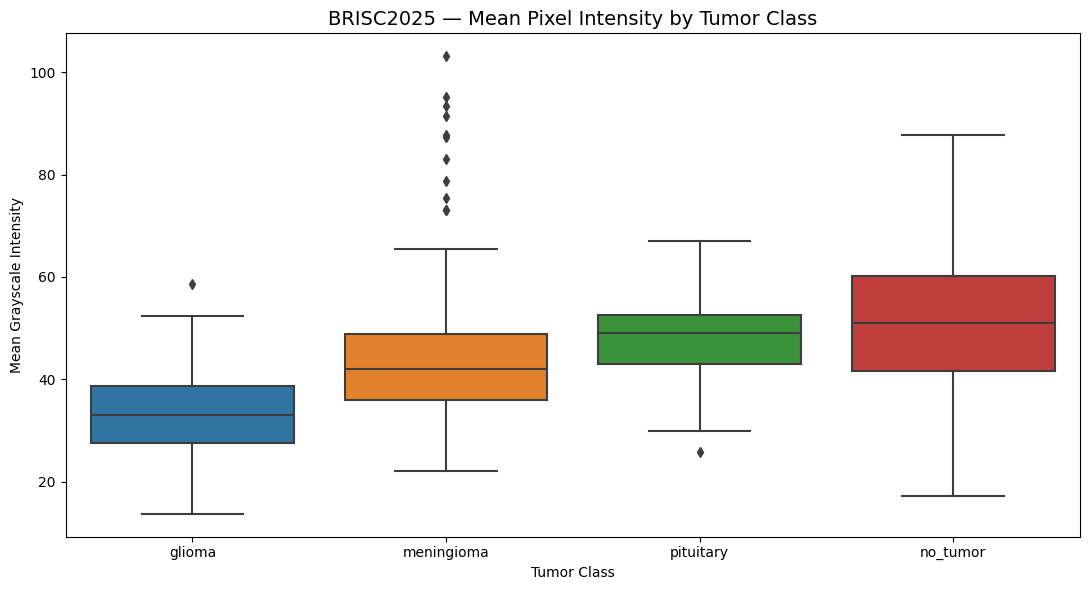


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\08_mean_pixel_intensity_by_class.png


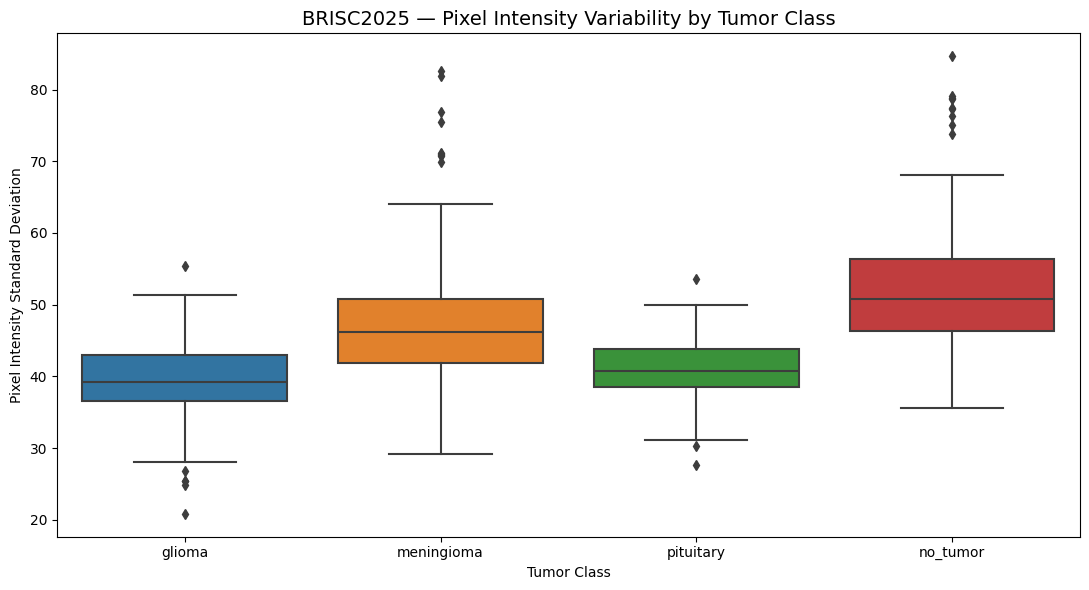


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\09_pixel_intensity_variability_by_class.png

Pixel statistics saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\pixel_intensity_sample_statistics.csv

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md

CELL 11 COMPLETE


In [12]:
# =========================================================
# CELL 11 — Pixel Intensity Analysis
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Sample images
# ---------------------------------------------------------
# We use a representative random sample rather than loading
# all 6000 images into memory.

RANDOM_SEED = 42
SAMPLE_PER_CLASS = 100

rng = random.Random(RANDOM_SEED)

classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

pixel_records = []

print("=" * 70)
print("PIXEL INTENSITY ANALYSIS")
print("=" * 70)

for class_name in classes:

    class_data = classification_manifest[
        classification_manifest["tumor_label"] == class_name
    ]

    sampled_data = class_data.sample(
        n=min(SAMPLE_PER_CLASS, len(class_data)),
        random_state=RANDOM_SEED
    )

    print(
        f"\nProcessing {class_name}: "
        f"{len(sampled_data)} images"
    )

    for _, row in sampled_data.iterrows():

        image_path = DATASET_DIR / row["relative_path"]

        try:

            with Image.open(image_path) as image:

                image_gray = image.convert("L")

                pixels = np.asarray(
                    image_gray,
                    dtype=np.float32
                )

                pixel_records.append({
                    "class": class_name,
                    "filename": row["filename"],
                    "mean_intensity": pixels.mean(),
                    "std_intensity": pixels.std(),
                    "min_intensity": pixels.min(),
                    "max_intensity": pixels.max(),
                    "median_intensity": np.median(pixels),
                    "percent_nonzero": (
                        np.count_nonzero(pixels) /
                        pixels.size
                    ) * 100
                })

        except Exception as e:

            print(
                "Could not read:",
                row["filename"],
                "|",
                e
            )

pixel_df = pd.DataFrame(pixel_records)

# ---------------------------------------------------------
# Summary statistics by class
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PIXEL INTENSITY SUMMARY BY CLASS")
print("=" * 70)

summary = (
    pixel_df
    .groupby("class")
    [
        [
            "mean_intensity",
            "std_intensity",
            "min_intensity",
            "max_intensity",
            "median_intensity",
            "percent_nonzero"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

display(
    summary.round(2)
)

# ---------------------------------------------------------
# Compact class-level summary
# ---------------------------------------------------------

compact_summary = (
    pixel_df
    .groupby("class")
    .agg(
        mean_intensity_mean=(
            "mean_intensity",
            "mean"
        ),
        mean_intensity_std=(
            "mean_intensity",
            "std"
        ),
        intensity_std_mean=(
            "std_intensity",
            "mean"
        ),
        median_intensity_mean=(
            "median_intensity",
            "mean"
        ),
        percent_nonzero_mean=(
            "percent_nonzero",
            "mean"
        )
    )
)

print("\nCOMPACT SUMMARY:")

display(
    compact_summary.round(2)
)

# ---------------------------------------------------------
# Mean intensity distribution
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=pixel_df,
    x="class",
    y="mean_intensity"
)

plt.title(
    "BRISC2025 — Mean Pixel Intensity by Tumor Class",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Mean Grayscale Intensity")

plt.tight_layout()

figure_path_1 = (
    FIGURES_DIR /
    "08_mean_pixel_intensity_by_class.png"
)

plt.savefig(
    figure_path_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path_1)

# ---------------------------------------------------------
# Pixel intensity variability
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=pixel_df,
    x="class",
    y="std_intensity"
)

plt.title(
    "BRISC2025 — Pixel Intensity Variability by Tumor Class",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Pixel Intensity Standard Deviation")

plt.tight_layout()

figure_path_2 = (
    FIGURES_DIR /
    "09_pixel_intensity_variability_by_class.png"
)

plt.savefig(
    figure_path_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path_2)

# ---------------------------------------------------------
# Save raw pixel statistics
# ---------------------------------------------------------

pixel_csv_path = (
    REPORTS_DIR /
    "pixel_intensity_sample_statistics.csv"
)

pixel_df.to_csv(
    pixel_csv_path,
    index=False
)

print("\nPixel statistics saved to:")
print(pixel_csv_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = (
    REPORTS_DIR /
    "dataset_analysis_records.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 9. Pixel Intensity Analysis\n\n"
    )

    f.write(
        "Pixel intensity characteristics were examined using "
        "a reproducible random sample of up to 100 classification "
        "images per tumor class (random seed = 42). Images were "
        "converted to grayscale for calculation of intensity "
        "statistics so that RGB and grayscale source images could "
        "be compared on the same intensity scale.\n\n"
    )

    f.write(
        "The following statistics were calculated for each sampled "
        "image: mean intensity, standard deviation of intensity, "
        "minimum intensity, maximum intensity, median intensity, "
        "and percentage of non-zero pixels.\n\n"
    )

    f.write(
        "The detailed per-image statistics are stored in "
        "`outputs/reports/pixel_intensity_sample_statistics.csv`.\n\n"
    )

    f.write(
        "Figures generated:\n\n"
        "- `outputs/figures/08_mean_pixel_intensity_by_class.png`\n"
        "- `outputs/figures/09_pixel_intensity_variability_by_class.png`\n"
    )

print("\nThesis record updated:")
print(thesis_record)

print("\n" + "=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

CROSS-SPLIT EXACT DUPLICATE ANALYSIS

Total classification images: 6000
Total duplicate records: 96
Duplicate SHA-256 groups: 46
Cross-split duplicate groups: 7
Test images involved in cross-split duplicates: 7
Training images involved in cross-split duplicates: 9

Percentage of test set involved: 0.7 %

DETAILED CROSS-SPLIT DUPLICATES:


,sha256,filename,tumor_label,plane_label,width,height,split,relative_path
826,02799f7863d49de182357e72179f3cc4e65e70099355f2...,brisc2025_test_00827_pi_co_t1.jpg,pituitary,coronal,512,512,test,classification_task\test\pituitary\brisc2025_t...
5193,02799f7863d49de182357e72179f3cc4e65e70099355f2...,brisc2025_train_04194_pi_co_t1.jpg,pituitary,coronal,512,512,train,classification_task\train\pituitary\brisc2025_...
750,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,brisc2025_test_00751_pi_ax_t1.jpg,pituitary,axial,512,512,test,classification_task\test\pituitary\brisc2025_t...
4748,08690b76457b2b44d58682cece62ec951ef6d30d935ce0...,brisc2025_train_03749_pi_ax_t1.jpg,pituitary,axial,512,512,train,classification_task\train\pituitary\brisc2025_...
736,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,brisc2025_test_00737_pi_ax_t1.jpg,pituitary,axial,512,512,test,classification_task\test\pituitary\brisc2025_t...
4704,39f4f7b252d7809d8d3d2e4521607de2195bf0f66c0592...,brisc2025_train_03705_pi_ax_t1.jpg,pituitary,axial,512,512,train,classification_task\train\pituitary\brisc2025_...
824,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,brisc2025_test_00825_pi_co_t1.jpg,pituitary,coronal,512,512,test,classification_task\test\pituitary\brisc2025_t...
5175,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,brisc2025_train_04176_pi_co_t1.jpg,pituitary,coronal,512,512,train,classification_task\train\pituitary\brisc2025_...
5176,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,brisc2025_train_04177_pi_co_t1.jpg,pituitary,coronal,512,512,train,classification_task\train\pituitary\brisc2025_...
5177,3e802dd22f483ce4d442fe2c7f1890c1c810ec8c1131b3...,brisc2025_train_04178_pi_co_t1.jpg,pituitary,coronal,512,512,train,classification_task\train\pituitary\brisc2025_...



Cross-split duplicate groups with conflicting labels: 0
No conflicting labels found among exact cross-split duplicates.

CROSS-SPLIT DUPLICATES BY CLASS:


split,test,train
tumor_label,,
meningioma,2,2
pituitary,5,7


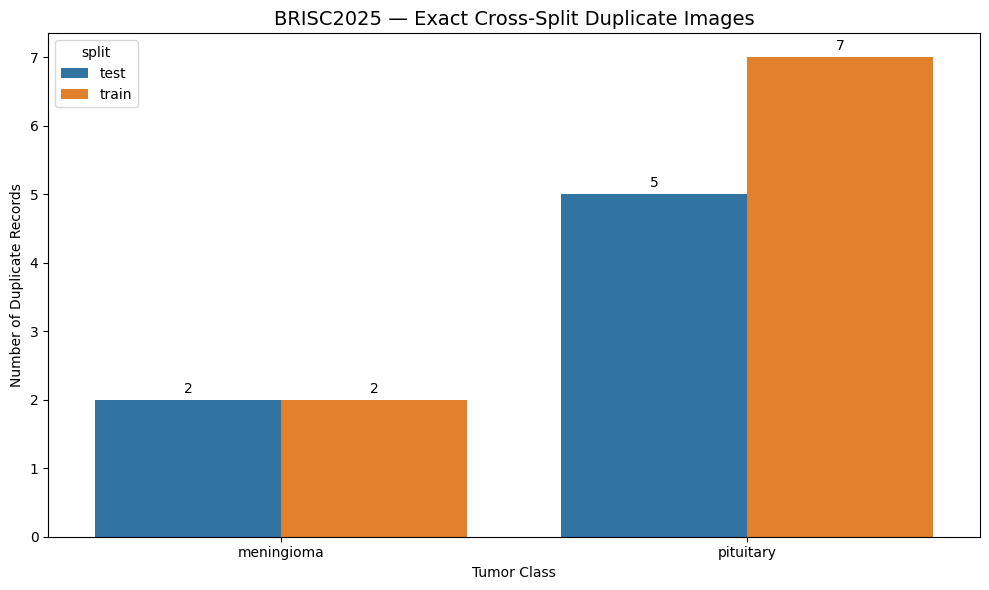


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\10_cross_split_duplicate_analysis.png

Duplicate details saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\cross_split_duplicate_images.csv

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md

CELL 12 COMPLETE


In [13]:
# =========================================================
# CELL 12 — Cross-Split Duplicate Leakage Analysis
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load manifest
# ---------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ---------------------------------------------------------
# Find duplicate SHA-256 hashes
# ---------------------------------------------------------

hash_counts = (
    classification_manifest["sha256"]
    .value_counts()
)

duplicate_hashes = hash_counts[
    hash_counts > 1
].index

duplicate_records = classification_manifest[
    classification_manifest["sha256"].isin(
        duplicate_hashes
    )
].copy()

# ---------------------------------------------------------
# Identify hashes appearing in BOTH train and test
# ---------------------------------------------------------

cross_split_groups = (
    duplicate_records
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_hashes = cross_split_groups[
    cross_split_groups > 1
].index

cross_split_duplicates = duplicate_records[
    duplicate_records["sha256"].isin(
        cross_split_hashes
    )
].copy()

# ---------------------------------------------------------
# Basic statistics
# ---------------------------------------------------------

test_duplicate_records = (
    cross_split_duplicates["split"]
    .eq("test")
    .sum()
)

train_duplicate_records = (
    cross_split_duplicates["split"]
    .eq("train")
    .sum()
)

cross_split_group_count = (
    cross_split_duplicates["sha256"]
    .nunique()
)

print("=" * 75)
print("CROSS-SPLIT EXACT DUPLICATE ANALYSIS")
print("=" * 75)

print(
    "\nTotal classification images:",
    len(classification_manifest)
)

print(
    "Total duplicate records:",
    len(duplicate_records)
)

print(
    "Duplicate SHA-256 groups:",
    len(duplicate_hashes)
)

print(
    "Cross-split duplicate groups:",
    cross_split_group_count
)

print(
    "Test images involved in cross-split duplicates:",
    test_duplicate_records
)

print(
    "Training images involved in cross-split duplicates:",
    train_duplicate_records
)

print(
    "\nPercentage of test set involved:",
    round(
        test_duplicate_records /
        classification_manifest[
            classification_manifest["split"] == "test"
        ].shape[0] * 100,
        2
    ),
    "%"
)

# ---------------------------------------------------------
# Detailed duplicate table
# ---------------------------------------------------------

duplicate_details = (
    cross_split_duplicates
    [
        [
            "sha256",
            "filename",
            "tumor_label",
            "plane_label",
            "width",
            "height",
            "split",
            "relative_path"
        ]
    ]
    .sort_values(
        ["sha256", "split"]
    )
)

print("\nDETAILED CROSS-SPLIT DUPLICATES:")

display(
    duplicate_details
)

# ---------------------------------------------------------
# Check label consistency
# ---------------------------------------------------------

label_consistency = (
    cross_split_duplicates
    .groupby("sha256")["tumor_label"]
    .nunique()
)

conflicting_groups = label_consistency[
    label_consistency > 1
]

print(
    "\nCross-split duplicate groups with conflicting labels:",
    len(conflicting_groups)
)

if len(conflicting_groups) == 0:
    print(
        "No conflicting labels found among exact "
        "cross-split duplicates."
    )
else:
    print(
        "WARNING: Conflicting labels detected."
    )

# ---------------------------------------------------------
# Cross-split duplicates by class
# ---------------------------------------------------------

duplicate_class_counts = pd.crosstab(
    cross_split_duplicates["tumor_label"],
    cross_split_duplicates["split"]
)

print("\nCROSS-SPLIT DUPLICATES BY CLASS:")

display(
    duplicate_class_counts
)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

plot_data = (
    cross_split_duplicates
    .groupby(
        ["tumor_label", "split"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    x="tumor_label",
    y="count",
    hue="split",
    errorbar=None
)

plt.title(
    "BRISC2025 — Exact Cross-Split Duplicate Images",
    fontsize=14
)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Duplicate Records")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "10_cross_split_duplicate_analysis.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

# ---------------------------------------------------------
# Save duplicate CSV
# ---------------------------------------------------------

duplicate_csv_path = (
    REPORTS_DIR /
    "cross_split_duplicate_images.csv"
)

duplicate_details.to_csv(
    duplicate_csv_path,
    index=False
)

print("\nDuplicate details saved to:")
print(duplicate_csv_path)

# ---------------------------------------------------------
# Save thesis record
# ---------------------------------------------------------

thesis_record = (
    REPORTS_DIR /
    "dataset_analysis_records.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 10. Exact Duplicate and Cross-Split Leakage Analysis\n\n"
    )

    f.write(
        f"SHA-256 analysis identified {len(duplicate_hashes)} "
        f"duplicate hash groups among the 6,000 classification "
        f"images. A total of {len(duplicate_records)} image records "
        f"were associated with duplicate hashes.\n\n"
    )

    f.write(
        f"Of these, {cross_split_group_count} exact duplicate groups "
        f"were found to occur across both the predefined training "
        f"and test splits. These groups involved "
        f"{train_duplicate_records} training records and "
        f"{test_duplicate_records} test records.\n\n"
    )

    f.write(
        f"The cross-split duplicates therefore involve "
        f"{test_duplicate_records / 1000 * 100:.2f}% of the "
        f"1,000-image test set.\n\n"
    )

    f.write(
        f"Label consistency analysis identified "
        f"{len(conflicting_groups)} cross-split duplicate groups "
        f"with conflicting tumor labels.\n\n"
    )

    if len(conflicting_groups) == 0:

        f.write(
            "No conflicting labels were identified among the "
            "exact cross-split duplicate groups.\n\n"
        )

    f.write(
        "Because exact image duplicates are present across the "
        "predefined train/test boundary, evaluation on the original "
        "test set may contain a small degree of leakage. This will "
        "be explicitly documented in the thesis. During model "
        "development, duplicate-aware evaluation will be considered "
        "so that reported performance is not interpreted without "
        "accounting for the identified cross-split duplicates.\n\n"
    )

    f.write(
        "The complete list of cross-split duplicate images is stored "
        "in `outputs/reports/cross_split_duplicate_images.csv`.\n\n"
    )

    f.write(
        "Figure: Exact cross-split duplicate image records by tumor "
        "class and split. Saved as "
        "`outputs/figures/10_cross_split_duplicate_analysis.png`.\n"
    )

print("\nThesis record updated:")
print(thesis_record)

print("\n" + "=" * 75)
print("CELL 12 COMPLETE")
print("=" * 75)

IDENTIFIER / FILENAME / INDEX STRUCTURE ANALYSIS

Classification records:
6000

Columns available:
['relative_path', 'filename', 'task', 'split', 'index', 'tumor_code', 'tumor_label', 'plane_code', 'plane_label', 'sequence', 'is_mask', 'linked_image', 'width', 'height', 'file_size_bytes', 'sha256']

FILENAME STRUCTURE

Example filenames:
  brisc2025_test_00001_gl_ax_t1.jpg
  brisc2025_test_00002_gl_ax_t1.jpg
  brisc2025_test_00003_gl_ax_t1.jpg
  brisc2025_test_00004_gl_ax_t1.jpg
  brisc2025_test_00005_gl_ax_t1.jpg
  brisc2025_test_00006_gl_ax_t1.jpg
  brisc2025_test_00007_gl_ax_t1.jpg
  brisc2025_test_00008_gl_ax_t1.jpg
  brisc2025_test_00009_gl_ax_t1.jpg
  brisc2025_test_00010_gl_ax_t1.jpg
  brisc2025_test_00011_gl_ax_t1.jpg
  brisc2025_test_00012_gl_ax_t1.jpg
  brisc2025_test_00013_gl_ax_t1.jpg
  brisc2025_test_00014_gl_ax_t1.jpg
  brisc2025_test_00015_gl_ax_t1.jpg
  brisc2025_test_00016_gl_ax_t1.jpg
  brisc2025_test_00017_gl_ax_t1.jpg
  brisc2025_test_00018_gl_ax_t1.jpg
  brisc2025_

,count,nunique,min,max
split,,,,
test,1000,1000,1,1000
train,5000,5000,1,5000



Index distribution by class:


,count,nunique,min,max
tumor_label,,,,
glioma,1401,1147,1,1147
meningioma,1635,1635,255,2476
no_tumor,1207,1207,561,3543
pituitary,1757,1757,701,5000



Records with duplicated manifest index: 2000
Records with duplicated filename index: 2000

Filename index == manifest index: 6000 / 6000

TUMOR CODE ENCODING


...


PLANE CODE ENCODING


plane_label,axial,coronal,sagittal,All
filename_plane_code,,,,
ax,1993,0,0,1993
co,0,1981,0,1981
sa,0,0,2026,2026
All,1993,1981,2026,6000



SPLIT INFORMATION ENCODING


split,test,train,All
filename_split,,,
test,1000,0,1000
train,0,5000,5000
All,1000,5000,6000


c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\prabh\App

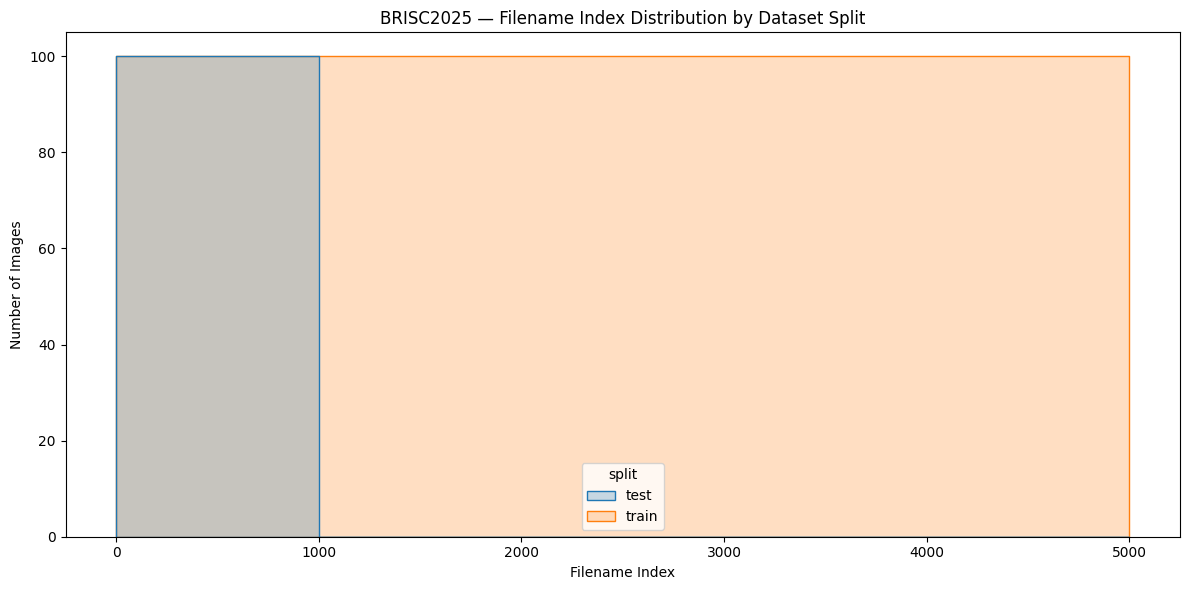


Figure saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\11_filename_index_distribution.png

Detailed identifier analysis saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\identifier_filename_analysis.csv

Thesis record updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md

CELL 13 COMPLETE


In [14]:
# ============================================================
# CELL 13 — Identifier, Filename and Index Structure Analysis
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# BASIC INFORMATION
# ------------------------------------------------------------

print("=" * 75)
print("IDENTIFIER / FILENAME / INDEX STRUCTURE ANALYSIS")
print("=" * 75)

print("\nClassification records:")
print(len(classification_manifest))

print("\nColumns available:")
print(list(classification_manifest.columns))

# ------------------------------------------------------------
# FILENAME STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FILENAME STRUCTURE")
print("=" * 75)

filename_examples = (
    classification_manifest["filename"]
    .drop_duplicates()
    .head(20)
    .tolist()
)

print("\nExample filenames:")

for filename in filename_examples:
    print(" ", filename)

# ------------------------------------------------------------
# EXTRACT INFORMATION FROM FILENAMES
# ------------------------------------------------------------

filename_pattern = re.compile(
    r"brisc2025_(train|test)_(\d+)_([a-z]+)_([a-z]{2})_t1\.jpg$",
    re.IGNORECASE
)

parsed_records = []

for filename in classification_manifest["filename"]:

    match = filename_pattern.match(filename)

    if match:

        parsed_records.append({
            "filename": filename,
            "filename_split": match.group(1).lower(),
            "filename_index": int(match.group(2)),
            "filename_tumor_code": match.group(3).lower(),
            "filename_plane_code": match.group(4).lower(),
            "filename_sequence": "t1"
        })

    else:

        parsed_records.append({
            "filename": filename,
            "filename_split": np.nan,
            "filename_index": np.nan,
            "filename_tumor_code": np.nan,
            "filename_plane_code": np.nan,
            "filename_sequence": np.nan
        })

filename_df = pd.DataFrame(parsed_records)

classification_with_filename = (
    classification_manifest
    .merge(
        filename_df,
        on="filename",
        how="left"
    )
)

# ------------------------------------------------------------
# PARSING SUCCESS
# ------------------------------------------------------------

parsed_count = (
    classification_with_filename["filename_index"]
    .notna()
    .sum()
)

total_count = len(
    classification_with_filename
)

print("\nFilename parsing:")
print(
    f"Successfully parsed: {parsed_count}/{total_count}"
)

print(
    "Parsing percentage:",
    round(parsed_count / total_count * 100, 2),
    "%"
)

# ------------------------------------------------------------
# COMPARE FILENAME INFORMATION WITH MANIFEST
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FILENAME vs MANIFEST CONSISTENCY")
print("=" * 75)

split_match = (
    classification_with_filename["filename_split"]
    == classification_with_filename["split"]
).sum()

tumor_match = (
    classification_with_filename["filename_tumor_code"]
    == classification_with_filename["tumor_code"]
).sum()

plane_match = (
    classification_with_filename["filename_plane_code"]
    == classification_with_filename["plane_code"]
).sum()

sequence_match = (
    classification_with_filename["filename_sequence"]
    == classification_with_filename["sequence"]
).sum()

print(
    "\nFilename split matches manifest:",
    split_match,
    "/",
    total_count
)

print(
    "Filename tumor code matches manifest:",
    tumor_match,
    "/",
    total_count
)

print(
    "Filename plane code matches manifest:",
    plane_match,
    "/",
    total_count
)

print(
    "Filename sequence matches manifest:",
    sequence_match,
    "/",
    total_count
)

# ------------------------------------------------------------
# INDEX ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("INDEX ANALYSIS")
print("=" * 75)

print(
    "\nUnique manifest indices:",
    classification_manifest["index"].nunique()
)

print(
    "Total classification records:",
    len(classification_manifest)
)

print(
    "Minimum index:",
    classification_manifest["index"].min()
)

print(
    "Maximum index:",
    classification_manifest["index"].max()
)

# ------------------------------------------------------------
# INDEX BY SPLIT
# ------------------------------------------------------------

print("\nIndex distribution by split:")

display(
    classification_manifest
    .groupby("split")["index"]
    .agg(
        [
            "count",
            "nunique",
            "min",
            "max"
        ]
    )
)

# ------------------------------------------------------------
# INDEX BY CLASS
# ------------------------------------------------------------

print("\nIndex distribution by class:")

display(
    classification_manifest
    .groupby("tumor_label")["index"]
    .agg(
        [
            "count",
            "nunique",
            "min",
            "max"
        ]
    )
)

# ------------------------------------------------------------
# CHECK WHETHER INDEX IS UNIQUE WITHIN CLASS/SPLIT
# ------------------------------------------------------------

index_duplicates = (
    classification_manifest
    .duplicated(
        subset=["index"],
        keep=False
    )
)

print(
    "\nRecords with duplicated manifest index:",
    index_duplicates.sum()
)

# ------------------------------------------------------------
# FILENAME INDEX UNIQUENESS
# ------------------------------------------------------------

filename_index_duplicates = (
    classification_with_filename
    .duplicated(
        subset=["filename_index"],
        keep=False
    )
)

print(
    "Records with duplicated filename index:",
    filename_index_duplicates.sum()
)

# ------------------------------------------------------------
# CHECK WHETHER FILENAME INDEX CORRESPONDS TO MANIFEST INDEX
# ------------------------------------------------------------

index_comparison = (
    classification_with_filename["filename_index"]
    == classification_with_filename["index"]
)

valid_index_comparison = (
    classification_with_filename["filename_index"]
    .notna()
)

matching_indices = (
    index_comparison &
    valid_index_comparison
).sum()

print(
    "\nFilename index == manifest index:",
    matching_indices,
    "/",
    valid_index_comparison.sum()
)

# ------------------------------------------------------------
# CHECK CLASS INFORMATION ENCODED IN FILENAME
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TUMOR CODE ENCODING")
print("=" * 75)

display(
    pd.crosstab(
        classification_with_filename["filename_tumor_code"],
        classification_with_filename["tumor_label"],
        margins=True
    )
)

# ------------------------------------------------------------
# CHECK PLANE INFORMATION ENCODED IN FILENAME
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PLANE CODE ENCODING")
print("=" * 75)

display(
    pd.crosstab(
        classification_with_filename["filename_plane_code"],
        classification_with_filename["plane_label"],
        margins=True
    )
)

# ------------------------------------------------------------
# CHECK SPLIT INFORMATION ENCODED IN FILENAME
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SPLIT INFORMATION ENCODING")
print("=" * 75)

display(
    pd.crosstab(
        classification_with_filename["filename_split"],
        classification_with_filename["split"],
        margins=True
    )
)

# ------------------------------------------------------------
# VISUALIZE FILENAME INDEX DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.histplot(
    data=classification_with_filename,
    x="filename_index",
    hue="split",
    bins=50,
    element="step",
    stat="count",
    common_norm=False
)

plt.title(
    "BRISC2025 — Filename Index Distribution by Dataset Split"
)

plt.xlabel("Filename Index")
plt.ylabel("Number of Images")

plt.tight_layout()

index_figure_path = (
    FIGURES_DIR /
    "11_filename_index_distribution.png"
)

plt.savefig(
    index_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nFigure saved to:"
)

print(index_figure_path)

# ------------------------------------------------------------
# SAVE ANALYSIS TABLE
# ------------------------------------------------------------

identifier_csv_path = (
    REPORTS_DIR /
    "identifier_filename_analysis.csv"
)

classification_with_filename.to_csv(
    identifier_csv_path,
    index=False
)

print(
    "\nDetailed identifier analysis saved to:"
)

print(identifier_csv_path)

# ------------------------------------------------------------
# THESIS RECORD
# ------------------------------------------------------------

thesis_record = (
    REPORTS_DIR /
    "dataset_analysis_records.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 11. Identifier, Filename and Index Structure Analysis\n\n"
    )

    f.write(
        f"The BRISC2025 classification manifest contains "
        f"{total_count} classification records. Filename parsing "
        f"was successfully performed for {parsed_count} records "
        f"({parsed_count / total_count * 100:.2f}%).\n\n"
    )

    f.write(
        "The filename structure contains dataset split, image index, "
        "tumor code, MRI plane code and T1 sequence information. "
        "These metadata elements were compared with the corresponding "
        "manifest fields.\n\n"
    )

    f.write(
        f"Filename split information matched the manifest split for "
        f"{split_match}/{total_count} records. Filename tumor codes "
        f"matched manifest tumor codes for {tumor_match}/{total_count} "
        f"records. Filename plane codes matched manifest plane codes "
        f"for {plane_match}/{total_count} records, while filename "
        f"sequence information matched the manifest sequence for "
        f"{sequence_match}/{total_count} records.\n\n"
    )

    f.write(
        f"The manifest contains {classification_manifest['index'].nunique()} "
        f"unique classification indices. The index ranges from "
        f"{classification_manifest['index'].min()} to "
        f"{classification_manifest['index'].max()}.\n\n"
    )

    f.write(
        f"{index_duplicates.sum()} classification records had duplicated "
        f"manifest indices. {filename_index_duplicates.sum()} records had "
        f"duplicated parsed filename indices.\n\n"
    )

    f.write(
        f"Filename indices matched manifest indices for "
        f"{matching_indices}/{valid_index_comparison.sum()} records "
        f"where filename indices could be parsed.\n\n"
    )

    f.write(
        "The analysis confirms that filename metadata contains explicit "
        "class and acquisition-related information. Therefore, filenames "
        "and metadata fields will NOT be provided as model input features. "
        "The classification model will receive image pixels only.\n\n"
    )

    f.write(
        "This restriction is important to prevent metadata leakage, "
        "where the model could potentially learn the tumor label from "
        "the filename or encoded tumor code rather than from MRI image "
        "features.\n\n"
    )

    f.write(
        "Detailed identifier-level results are stored in "
        "`outputs/reports/identifier_filename_analysis.csv` and the "
        "filename-index distribution figure is stored as "
        "`outputs/figures/11_filename_index_distribution.png`.\n"
    )

print(
    "\nThesis record updated:"
)

print(thesis_record)

print("\n" + "=" * 75)
print("CELL 13 COMPLETE")
print("=" * 75)

In [15]:
# ============================================================
# CELL 14 — FINAL DATASET INTEGRITY & FILE VERIFICATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import hashlib
import json

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)

classification_manifest = manifest[
    manifest["task"] == "classification"
].copy()

print("=" * 75)
print("FINAL DATASET INTEGRITY & FILE VERIFICATION")
print("=" * 75)

print("\nTotal manifest records:", len(manifest))
print("Classification records:", len(classification_manifest))

# ------------------------------------------------------------
# 1. CHECK CLASSIFICATION FILE PATHS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("1. CLASSIFICATION FILE EXISTENCE")
print("=" * 75)

classification_paths = []

for relative_path in classification_manifest["relative_path"]:

    file_path = DATASET_DIR / relative_path
    classification_paths.append(file_path.exists())

classification_manifest["file_exists"] = classification_paths

existing_files = classification_manifest["file_exists"].sum()
missing_files = (~classification_manifest["file_exists"]).sum()

print("\nExpected classification files:", len(classification_manifest))
print("Files found:", existing_files)
print("Files missing:", missing_files)

if missing_files > 0:

    print("\nMISSING FILES:")

    print(
        classification_manifest.loc[
            ~classification_manifest["file_exists"],
            "relative_path"
        ].to_string(index=False)
    )

else:

    print("\n✓ All classification files exist.")

# ------------------------------------------------------------
# 2. CHECK FOLDER LABEL AGAINST MANIFEST LABEL
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("2. FOLDER LABEL CONSISTENCY")
print("=" * 75)

folder_labels = []

for relative_path in classification_manifest["relative_path"]:

    parts = Path(relative_path).parts

    # Expected:
    # classification_task / train/test / class / filename

    if len(parts) >= 3:
        folder_labels.append(parts[-2])
    else:
        folder_labels.append(None)

classification_manifest["folder_label"] = folder_labels

label_matches = (
    classification_manifest["folder_label"]
    == classification_manifest["tumor_label"]
)

print(
    "\nFolder label matches manifest label:",
    label_matches.sum(),
    "/",
    len(label_matches)
)

print(
    "Mismatches:",
    (~label_matches).sum()
)

if (~label_matches).sum() > 0:

    print("\nLABEL MISMATCHES:")

    display(
        classification_manifest.loc[
            ~label_matches,
            [
                "relative_path",
                "folder_label",
                "tumor_label"
            ]
        ]
    )

else:

    print("\n✓ All folder labels match manifest labels.")

# ------------------------------------------------------------
# 3. CHECK SPLIT CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("3. SPLIT DIRECTORY CONSISTENCY")
print("=" * 75)

folder_splits = []

for relative_path in classification_manifest["relative_path"]:

    parts = Path(relative_path).parts

    if len(parts) >= 2:
        folder_splits.append(parts[-3])
    else:
        folder_splits.append(None)

classification_manifest["folder_split"] = folder_splits

split_matches = (
    classification_manifest["folder_split"]
    == classification_manifest["split"]
)

print(
    "\nFolder split matches manifest split:",
    split_matches.sum(),
    "/",
    len(split_matches)
)

print(
    "Mismatches:",
    (~split_matches).sum()
)

if (~split_matches).sum() > 0:

    print("\nSPLIT MISMATCHES:")

    display(
        classification_manifest.loc[
            ~split_matches,
            [
                "relative_path",
                "folder_split",
                "split"
            ]
        ]
    )

else:

    print("\n✓ All split directories match manifest splits.")

# ------------------------------------------------------------
# 4. CHECK FILE EXTENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("4. FILE EXTENSION CHECK")
print("=" * 75)

extension_counts = (
    classification_manifest["relative_path"]
    .apply(lambda x: Path(x).suffix.lower())
    .value_counts()
)

print("\nFile extensions:")

display(extension_counts)

# ------------------------------------------------------------
# 5. CHECK ACTUAL IMAGE DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("5. ACTUAL IMAGE DIMENSION VERIFICATION")
print("=" * 75)

dimension_mismatches = []
read_errors = []

# Verify all classification images
for row in classification_manifest.itertuples():

    file_path = DATASET_DIR / row.relative_path

    if not file_path.exists():
        continue

    try:

        with Image.open(file_path) as image:

            actual_width, actual_height = image.size

        if (
            actual_width != row.width
            or actual_height != row.height
        ):

            dimension_mismatches.append({
                "filename": row.filename,
                "manifest_width": row.width,
                "manifest_height": row.height,
                "actual_width": actual_width,
                "actual_height": actual_height
            })

    except Exception as e:

        read_errors.append({
            "filename": row.filename,
            "error": str(e)
        })

print(
    "\nDimension mismatches:",
    len(dimension_mismatches)
)

print(
    "Image read errors:",
    len(read_errors)
)

if len(dimension_mismatches) > 0:

    print("\nDIMENSION MISMATCHES:")

    display(
        pd.DataFrame(dimension_mismatches)
    )

else:

    print("\n✓ All verified image dimensions match the manifest.")

if len(read_errors) > 0:

    print("\nIMAGE READ ERRORS:")

    display(
        pd.DataFrame(read_errors)
    )

else:

    print("\n✓ No image read errors detected.")

# ------------------------------------------------------------
# 6. CHECK MANIFEST CLASS COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("6. CLASS DISTRIBUTION VERIFICATION")
print("=" * 75)

class_counts = (
    classification_manifest["tumor_label"]
    .value_counts()
    .sort_index()
)

print("\nClass counts:")

display(class_counts)

print(
    "\nTotal:",
    class_counts.sum()
)

# ------------------------------------------------------------
# 7. CHECK TRAIN / TEST COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("7. TRAIN / TEST VERIFICATION")
print("=" * 75)

split_counts = (
    classification_manifest["split"]
    .value_counts()
    .sort_index()
)

print("\nSplit counts:")

display(split_counts)

# ------------------------------------------------------------
# 8. CHECK TRAIN/TEST CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("8. TRAIN / TEST × CLASS VERIFICATION")
print("=" * 75)

split_class_counts = pd.crosstab(
    classification_manifest["tumor_label"],
    classification_manifest["split"]
)

display(split_class_counts)

# ------------------------------------------------------------
# 9. CHECK SHA-256 FORMAT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("9. SHA-256 MANIFEST CHECK")
print("=" * 75)

sha_lengths = (
    classification_manifest["sha256"]
    .astype(str)
    .str.len()
)

print("\nSHA-256 lengths:")

display(sha_lengths.value_counts().sort_index())

valid_sha_format = (
    classification_manifest["sha256"]
    .astype(str)
    .str.fullmatch(r"[0-9a-fA-F]{64}")
)

print(
    "\nValid SHA-256 format:",
    valid_sha_format.sum(),
    "/",
    len(valid_sha_format)
)

print(
    "Invalid SHA-256 entries:",
    (~valid_sha_format).sum()
)

# ------------------------------------------------------------
# 10. CHECK DUPLICATES AGAIN
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("10. EXACT DUPLICATE SUMMARY")
print("=" * 75)

duplicate_sha_mask = (
    classification_manifest["sha256"]
    .duplicated(
        keep=False
    )
)

duplicate_records = duplicate_sha_mask.sum()

duplicate_groups = (
    classification_manifest.loc[
        duplicate_sha_mask,
        "sha256"
    ]
    .nunique()
)

print(
    "\nDuplicate records:",
    duplicate_records
)

print(
    "Duplicate SHA-256 groups:",
    duplicate_groups
)

# Cross split duplicate groups
sha_split_counts = (
    classification_manifest
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_hashes = (
    sha_split_counts[
        sha_split_counts > 1
    ]
)

print(
    "Cross-split duplicate groups:",
    len(cross_split_hashes)
)

# ------------------------------------------------------------
# 11. CHECK LINKED METADATA
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("11. METADATA COMPLETENESS")
print("=" * 75)

metadata_columns = [
    "relative_path",
    "filename",
    "task",
    "split",
    "index",
    "tumor_code",
    "tumor_label",
    "plane_code",
    "plane_label",
    "sequence",
    "width",
    "height",
    "file_size_bytes",
    "sha256"
]

metadata_missing = {}

for column in metadata_columns:

    metadata_missing[column] = (
        classification_manifest[column]
        .isna()
        .sum()
    )

metadata_missing_df = pd.DataFrame(
    {
        "missing_values": metadata_missing
    }
)

display(metadata_missing_df)

# ------------------------------------------------------------
# 12. FINAL INTEGRITY STATUS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL DATASET INTEGRITY STATUS")
print("=" * 75)

checks = {
    "All classification files exist":
        missing_files == 0,

    "Folder labels match manifest":
        (~label_matches).sum() == 0,

    "Folder splits match manifest":
        (~split_matches).sum() == 0,

    "No dimension mismatches":
        len(dimension_mismatches) == 0,

    "No image read errors":
        len(read_errors) == 0,

    "All SHA-256 entries valid":
        valid_sha_format.sum() == len(valid_sha_format),

    "No missing critical metadata":
        metadata_missing_df["missing_values"].sum() == 0
}

for check_name, result in checks.items():

    status = "PASS" if result else "FAIL"

    print(
        f"{status:6} | {check_name}"
    )

all_checks_passed = all(checks.values())

print("\nOverall integrity status:")

if all_checks_passed:

    print("✓ PASS — Dataset integrity checks completed successfully.")

else:

    print("⚠ REVIEW REQUIRED — One or more integrity checks failed.")

# ------------------------------------------------------------
# 13. SAVE INTEGRITY REPORT
# ------------------------------------------------------------

integrity_csv = (
    REPORTS_DIR /
    "dataset_integrity_verification.csv"
)

classification_manifest.to_csv(
    integrity_csv,
    index=False
)

# ------------------------------------------------------------
# 14. SAVE THESIS RECORD
# ------------------------------------------------------------

thesis_record = (
    REPORTS_DIR /
    "dataset_analysis_records.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 12. Final Dataset Integrity Verification\n\n"
    )

    f.write(
        f"The classification component contained "
        f"{len(classification_manifest)} records in the manifest. "
        f"All expected classification files were checked against "
        f"their manifest paths.\n\n"
    )

    f.write(
        f"Files found: {existing_files}; "
        f"files missing: {missing_files}.\n\n"
    )

    f.write(
        f"Folder labels were compared with manifest tumor labels. "
        f"{label_matches.sum()} of {len(label_matches)} records "
        f"matched, with {(~label_matches).sum()} mismatches.\n\n"
    )

    f.write(
        f"Folder split information was compared with manifest split "
        f"information. {split_matches.sum()} of {len(split_matches)} "
        f"records matched, with {(~split_matches).sum()} mismatches.\n\n"
    )

    f.write(
        f"Actual image dimensions were compared with the dimensions "
        f"recorded in the manifest. {len(dimension_mismatches)} "
        f"dimension mismatches were detected and "
        f"{len(read_errors)} image read errors were detected.\n\n"
    )

    f.write(
        f"The classification dataset contains "
        f"{class_counts.sum()} images across four tumor classes. "
        f"The predefined split contains "
        f"{split_counts.get('train', 0)} training images and "
        f"{split_counts.get('test', 0)} test images.\n\n"
    )

    f.write(
        f"The classification manifest contains "
        f"{duplicate_records} records belonging to "
        f"{duplicate_groups} duplicate SHA-256 groups. "
        f"{len(cross_split_hashes)} duplicate SHA-256 groups "
        f"cross the predefined train/test boundary.\n\n"
    )

    f.write(
        "The original BRISC2025 dataset will remain unchanged. "
        "Metadata fields will be used for quality control and "
        "statistical analysis only and will not be supplied as "
        "predictive features to the image classification models.\n\n"
    )

    if all_checks_passed:

        f.write(
            "Overall dataset integrity verification status: PASS. "
            "The dataset is ready for the next stage of analysis "
            "subject to the documented duplicate and metadata "
            "considerations.\n"
        )

    else:

        f.write(
            "Overall dataset integrity verification status: "
            "REVIEW REQUIRED. One or more integrity checks require "
            "investigation before preprocessing.\n"
        )

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print("\nIntegrity table:")
print(integrity_csv)

print("\nThesis record:")
print(thesis_record)

print("\n" + "=" * 75)
print("CELL 14 COMPLETE")
print("=" * 75)

FINAL DATASET INTEGRITY & FILE VERIFICATION

Total manifest records: 15586
Classification records: 6000

1. CLASSIFICATION FILE EXISTENCE

Expected classification files: 6000
Files found: 6000
Files missing: 0

✓ All classification files exist.

2. FOLDER LABEL CONSISTENCY

Folder label matches manifest label: 6000 / 6000
Mismatches: 0

✓ All folder labels match manifest labels.

3. SPLIT DIRECTORY CONSISTENCY

Folder split matches manifest split: 6000 / 6000
Mismatches: 0

✓ All split directories match manifest splits.

4. FILE EXTENSION CHECK

File extensions:


relative_path
.jpg    6000
Name: count, dtype: int64


5. ACTUAL IMAGE DIMENSION VERIFICATION

Dimension mismatches: 0
Image read errors: 0

✓ All verified image dimensions match the manifest.

✓ No image read errors detected.

6. CLASS DISTRIBUTION VERIFICATION

Class counts:


tumor_label
glioma        1401
meningioma    1635
no_tumor      1207
pituitary     1757
Name: count, dtype: int64


Total: 6000

7. TRAIN / TEST VERIFICATION

Split counts:


...


9. SHA-256 MANIFEST CHECK

SHA-256 lengths:


sha256
64    6000
Name: count, dtype: int64


Valid SHA-256 format: 6000 / 6000
Invalid SHA-256 entries: 0

10. EXACT DUPLICATE SUMMARY

Duplicate records: 96
Duplicate SHA-256 groups: 46
Cross-split duplicate groups: 7

11. METADATA COMPLETENESS


,missing_values
relative_path,0
filename,0
task,0
split,0
index,0
tumor_code,0
tumor_label,0
plane_code,0
plane_label,0
sequence,0



FINAL DATASET INTEGRITY STATUS
PASS   | All classification files exist
PASS   | Folder labels match manifest
PASS   | Folder splits match manifest
PASS   | No dimension mismatches
PASS   | No image read errors
PASS   | All SHA-256 entries valid
PASS   | No missing critical metadata

Overall integrity status:
✓ PASS — Dataset integrity checks completed successfully.

FILES SAVED

Integrity table:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_integrity_verification.csv

Thesis record:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\dataset_analysis_records.md

CELL 14 COMPLETE


In [17]:
# ============================================================
# CELL 15 — MASTER DATASET ANALYSIS & THESIS SUMMARY
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
DATASET_DIR = Path(r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025")

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DATASET_DIR / "manifest.csv"

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# BASIC DATASET INFORMATION
# ------------------------------------------------------------

total_images = len(classification)

class_counts = (
    classification["tumor_label"]
    .value_counts()
    .sort_index()
)

split_counts = (
    classification["split"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# CLASS × SPLIT
# ------------------------------------------------------------

class_split = pd.crosstab(
    classification["tumor_label"],
    classification["split"]
)

# ------------------------------------------------------------
# IMAGE MODE
# ------------------------------------------------------------

# Use the existing mode information if available.
# Otherwise inspect the actual image files.

from PIL import Image

mode_records = []

for row in classification.itertuples():

    image_path = DATASET_DIR / row.relative_path

    try:
        with Image.open(image_path) as img:
            mode_records.append({
                "filename": row.filename,
                "tumor_label": row.tumor_label,
                "split": row.split,
                "mode": img.mode
            })
    except Exception:
        mode_records.append({
            "filename": row.filename,
            "tumor_label": row.tumor_label,
            "split": row.split,
            "mode": "READ_ERROR"
        })

mode_df = pd.DataFrame(mode_records)

mode_counts = (
    mode_df["mode"]
    .value_counts()
    .sort_index()
)

mode_by_class = pd.crosstab(
    classification["tumor_label"],
    mode_df["mode"]
)

mode_by_split = pd.crosstab(
    classification["split"],
    mode_df["mode"]
)

# ------------------------------------------------------------
# MRI PLANE DISTRIBUTION
# ------------------------------------------------------------

plane_counts = (
    classification["plane_label"]
    .value_counts()
    .sort_index()
)

plane_by_class = pd.crosstab(
    classification["tumor_label"],
    classification["plane_label"]
)

plane_by_split_class = pd.crosstab(
    [classification["tumor_label"], classification["split"]],
    classification["plane_label"]
)

# ------------------------------------------------------------
# IMAGE DIMENSION ANALYSIS
# ------------------------------------------------------------

classification["aspect_ratio"] = (
    classification["width"] /
    classification["height"]
)

classification["is_square"] = (
    classification["width"] ==
    classification["height"]
)

dimension_counts = (
    classification
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

unique_dimensions = len(dimension_counts)

square_count = classification["is_square"].sum()
non_square_count = (~classification["is_square"]).sum()

square_percentage = square_count / total_images * 100
non_square_percentage = non_square_count / total_images * 100

# ------------------------------------------------------------
# ASPECT RATIO STATISTICS
# ------------------------------------------------------------

aspect_stats = classification["aspect_ratio"].describe()

# ------------------------------------------------------------
# DIMENSION STATISTICS
# ------------------------------------------------------------

width_stats = classification["width"].describe()
height_stats = classification["height"].describe()

# ------------------------------------------------------------
# SQUARE / NON-SQUARE BY CLASS
# ------------------------------------------------------------

square_by_class = pd.crosstab(
    classification["tumor_label"],
    classification["is_square"]
)

# ------------------------------------------------------------
# SQUARE / NON-SQUARE BY SPLIT
# ------------------------------------------------------------

square_by_split = pd.crosstab(
    classification["split"],
    classification["is_square"]
)

# ------------------------------------------------------------
# EXACT DUPLICATE ANALYSIS
# ------------------------------------------------------------

duplicate_mask = (
    classification["sha256"]
    .duplicated(keep=False)
)

duplicate_records = int(duplicate_mask.sum())

duplicate_groups = int(
    classification.loc[
        duplicate_mask,
        "sha256"
    ].nunique()
)

sha_split_counts = (
    classification
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_hashes = sha_split_counts[
    sha_split_counts > 1
]

cross_split_duplicate_groups = len(cross_split_hashes)

cross_split_records = classification[
    classification["sha256"].isin(
        cross_split_hashes.index
    )
]

cross_split_test_images = (
    cross_split_records[
        cross_split_records["split"] == "test"
    ]["filename"]
    .nunique()
)

cross_split_train_images = (
    cross_split_records[
        cross_split_records["split"] == "train"
    ]["filename"]
    .nunique()
)

test_duplicate_percentage = (
    cross_split_test_images /
    split_counts["test"] *
    100
)

# ------------------------------------------------------------
# DUPLICATES BY CLASS
# ------------------------------------------------------------

cross_split_duplicate_by_class = pd.crosstab(
    cross_split_records["tumor_label"],
    cross_split_records["split"]
)

# ------------------------------------------------------------
# METADATA COMPLETENESS
# ------------------------------------------------------------

critical_columns = [
    "relative_path",
    "filename",
    "task",
    "split",
    "index",
    "tumor_code",
    "tumor_label",
    "plane_code",
    "plane_label",
    "sequence",
    "width",
    "height",
    "file_size_bytes",
    "sha256"
]

metadata_missing = {
    column: int(classification[column].isna().sum())
    for column in critical_columns
}

total_missing_metadata = sum(
    metadata_missing.values()
)

# ------------------------------------------------------------
# SHA-256 VALIDITY
# ------------------------------------------------------------

valid_sha = classification["sha256"].astype(str).str.fullmatch(
    r"[0-9a-fA-F]{64}"
)

valid_sha_count = int(valid_sha.sum())
invalid_sha_count = int((~valid_sha).sum())

# ------------------------------------------------------------
# SAVE MASTER CSV — BASIC SUMMARY
# ------------------------------------------------------------

summary_rows = [
    ["Total classification images", total_images],
    ["Training images", int(split_counts.get("train", 0))],
    ["Test images", int(split_counts.get("test", 0))],

    ["Glioma images", int(class_counts.get("glioma", 0))],
    ["Meningioma images", int(class_counts.get("meningioma", 0))],
    ["Pituitary images", int(class_counts.get("pituitary", 0))],
    ["No tumor images", int(class_counts.get("no_tumor", 0))],

    ["Unique width × height combinations", unique_dimensions],

    ["Square images", int(square_count)],
    ["Non-square images", int(non_square_count)],
    ["Square image percentage", round(square_percentage, 2)],
    ["Non-square image percentage", round(non_square_percentage, 2)],

    ["Mean aspect ratio", round(aspect_stats["mean"], 6)],
    ["Aspect ratio standard deviation", round(aspect_stats["std"], 6)],
    ["Minimum aspect ratio", round(aspect_stats["min"], 6)],
    ["Maximum aspect ratio", round(aspect_stats["max"], 6)],

    ["Mean image width", round(width_stats["mean"], 4)],
    ["Mean image height", round(height_stats["mean"], 4)],
    ["Minimum image width", int(width_stats["min"])],
    ["Maximum image width", int(width_stats["max"])],
    ["Minimum image height", int(height_stats["min"])],
    ["Maximum image height", int(height_stats["max"])],

    ["Duplicate records", duplicate_records],
    ["Duplicate SHA-256 groups", duplicate_groups],
    ["Cross-split duplicate groups", cross_split_duplicate_groups],
    ["Test images involved in cross-split duplicates", cross_split_test_images],
    ["Training images involved in cross-split duplicates", cross_split_train_images],
    ["Percentage of test set involved in cross-split duplicates",
     round(test_duplicate_percentage, 2)],

    ["Valid SHA-256 entries", valid_sha_count],
    ["Invalid SHA-256 entries", invalid_sha_count],
    ["Missing critical metadata values", total_missing_metadata]
]

master_summary_df = pd.DataFrame(
    summary_rows,
    columns=["Metric", "Value"]
)

master_summary_csv = (
    REPORTS_DIR /
    "master_dataset_summary.csv"
)

master_summary_df.to_csv(
    master_summary_csv,
    index=False
)

# ------------------------------------------------------------
# SAVE CLASS DISTRIBUTION
# ------------------------------------------------------------

class_distribution_df = class_counts.rename(
    "image_count"
).reset_index()

class_distribution_df.columns = [
    "tumor_label",
    "image_count"
]

class_distribution_df["percentage"] = (
    class_distribution_df["image_count"] /
    total_images *
    100
).round(2)

class_distribution_df.to_csv(
    REPORTS_DIR / "class_distribution.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE CLASS × SPLIT DISTRIBUTION
# ------------------------------------------------------------

class_split.reset_index().to_csv(
    REPORTS_DIR / "class_split_distribution.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE MODE ANALYSIS
# ------------------------------------------------------------

mode_by_class.reset_index().to_csv(
    REPORTS_DIR / "image_mode_by_class.csv",
    index=False
)

mode_by_split.reset_index().to_csv(
    REPORTS_DIR / "image_mode_by_split.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE PLANE ANALYSIS
# ------------------------------------------------------------

plane_by_class.reset_index().to_csv(
    REPORTS_DIR / "mri_plane_by_class.csv",
    index=False
)

plane_by_split_class.reset_index().to_csv(
    REPORTS_DIR / "mri_plane_by_class_and_split.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE DIMENSION ANALYSIS
# ------------------------------------------------------------

dimension_counts_df = (
    dimension_counts
    .reset_index(name="count")
)

dimension_counts_df.to_csv(
    REPORTS_DIR / "image_dimensions.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE ASPECT RATIO ANALYSIS
# ------------------------------------------------------------

aspect_summary_df = pd.DataFrame({
    "statistic": aspect_stats.index,
    "value": aspect_stats.values
})

aspect_summary_df.to_csv(
    REPORTS_DIR / "aspect_ratio_statistics.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE SQUARE / NON-SQUARE ANALYSIS
# ------------------------------------------------------------

square_by_class.reset_index().to_csv(
    REPORTS_DIR / "square_non_square_by_class.csv",
    index=False
)

square_by_split.reset_index().to_csv(
    REPORTS_DIR / "square_non_square_by_split.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE DUPLICATE ANALYSIS
# ------------------------------------------------------------

duplicate_details = classification[
    classification["sha256"].isin(
        classification[
            "sha256"
        ][classification["sha256"].duplicated(keep=False)]
    )
].copy()

duplicate_details.to_csv(
    REPORTS_DIR / "duplicate_sha256_records.csv",
    index=False
)

cross_split_records.to_csv(
    REPORTS_DIR / "cross_split_duplicate_records.csv",
    index=False
)

cross_split_duplicate_by_class.reset_index().to_csv(
    REPORTS_DIR / "cross_split_duplicates_by_class.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE METADATA COMPLETENESS
# ------------------------------------------------------------

metadata_missing_df = pd.DataFrame(
    list(metadata_missing.items()),
    columns=["column", "missing_values"]
)

metadata_missing_df.to_csv(
    REPORTS_DIR / "metadata_completeness.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE A MASTER THESIS MARKDOWN REPORT
# ------------------------------------------------------------

thesis_master = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_master,
    "w",
    encoding="utf-8"
) as f:

    f.write("# BRISC2025 Dataset — Master Dataset Analysis\n\n")

    f.write(
        "## 1. Dataset Overview\n\n"
    )

    f.write(
        f"- Total classification images: **{total_images}**\n"
        f"- Training images: **{int(split_counts.get('train', 0))}**\n"
        f"- Test images: **{int(split_counts.get('test', 0))}**\n"
        f"- Number of tumor classes: **{len(class_counts)}**\n"
        f"- Unique image dimensions: **{unique_dimensions}**\n\n"
    )

    f.write("## 2. Class Distribution\n\n")
    f.write(
        class_distribution_df.to_markdown(index=False)
    )
    f.write("\n\n")

    f.write("## 3. Train/Test Distribution\n\n")
    f.write(
        class_split.to_markdown()
    )
    f.write("\n\n")

    f.write("## 4. Image Mode Distribution\n\n")
    f.write(
        mode_by_class.to_markdown()
    )
    f.write("\n\n")

    f.write("## 5. MRI Plane Distribution\n\n")
    f.write(
        plane_by_class.to_markdown()
    )
    f.write("\n\n")

    f.write("## 6. Image Dimensions\n\n")
    f.write(
        f"- Unique width × height combinations: **{unique_dimensions}**\n"
        f"- Square images: **{square_count} ({square_percentage:.2f}%)**\n"
        f"- Non-square images: **{non_square_count} ({non_square_percentage:.2f}%)**\n"
        f"- Mean width: **{width_stats['mean']:.2f} px**\n"
        f"- Mean height: **{height_stats['mean']:.2f} px**\n"
        f"- Minimum width: **{int(width_stats['min'])} px**\n"
        f"- Maximum width: **{int(width_stats['max'])} px**\n"
        f"- Minimum height: **{int(height_stats['min'])} px**\n"
        f"- Maximum height: **{int(height_stats['max'])} px**\n\n"
    )

    f.write("## 7. Aspect Ratio Analysis\n\n")
    f.write(
        f"- Mean aspect ratio: **{aspect_stats['mean']:.6f}**\n"
        f"- Standard deviation: **{aspect_stats['std']:.6f}**\n"
        f"- Minimum aspect ratio: **{aspect_stats['min']:.6f}**\n"
        f"- Maximum aspect ratio: **{aspect_stats['max']:.6f}**\n\n"
    )

    f.write("## 8. Duplicate Analysis\n\n")
    f.write(
        f"- Duplicate records: **{duplicate_records}**\n"
        f"- Duplicate SHA-256 groups: **{duplicate_groups}**\n"
        f"- Cross-split duplicate groups: **{cross_split_duplicate_groups}**\n"
        f"- Test images involved: **{cross_split_test_images}**\n"
        f"- Training images involved: **{cross_split_train_images}**\n"
        f"- Percentage of test set involved: **{test_duplicate_percentage:.2f}%**\n\n"
    )

    f.write(
        "Cross-split exact duplicates were identified using SHA-256 hashes. "
        "These records will be explicitly considered during model evaluation "
        "to avoid overstating generalization performance.\n\n"
    )

    f.write("## 9. Metadata Quality\n\n")
    f.write(
        f"- Valid SHA-256 entries: **{valid_sha_count}/{total_images}**\n"
        f"- Invalid SHA-256 entries: **{invalid_sha_count}**\n"
        f"- Missing critical metadata values: **{total_missing_metadata}**\n\n"
    )

    f.write("## 10. Integrity Status\n\n")
    f.write(
        "**PASS** — All classification files exist, folder labels and "
        "splits match the manifest, image dimensions are consistent with "
        "the manifest, no image read errors were detected, SHA-256 entries "
        "are valid, and no critical metadata values are missing.\n\n"
    )

    f.write("## 11. Important Methodological Note\n\n")
    f.write(
        "The original BRISC2025 dataset will remain unchanged. "
        "Metadata are used for quality control, dataset characterization, "
        "and statistical analysis. Metadata fields will not be supplied "
        "as predictive features to the image classification models.\n"
    )

# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("=" * 75)
print("CELL 15 — MASTER THESIS DATASET SUMMARY COMPLETE")
print("=" * 75)

print("\nTotal classification images:", total_images)

print("\nClass distribution:")
print(class_counts)

print("\nTrain/Test:")
print(split_counts)

print("\nUnique dimensions:", unique_dimensions)

print(
    f"Square images: {square_count} "
    f"({square_percentage:.2f}%)"
)

print(
    f"Non-square images: {non_square_count} "
    f"({non_square_percentage:.2f}%)"
)

print("\nDuplicate SHA-256 groups:", duplicate_groups)

print(
    "Cross-split duplicate groups:",
    cross_split_duplicate_groups
)

print(
    "Test images involved in cross-split duplicates:",
    cross_split_test_images
)

print(
    f"Percentage of test set involved: "
    f"{test_duplicate_percentage:.2f}%"
)

print("\n" + "=" * 75)
print("THESIS FILES SAVED")
print("=" * 75)

print("\nMaster summary:")
print(master_summary_csv)

print("\nMaster thesis report:")
print(thesis_master)

print("\nAll supporting CSV files saved in:")
print(REPORTS_DIR)

print("\n" + "=" * 75)
print("CELL 15 COMPLETE")
print("=" * 75)

CELL 15 — MASTER THESIS DATASET SUMMARY COMPLETE

Total classification images: 6000

Class distribution:
tumor_label
glioma        1401
meningioma    1635
no_tumor      1207
pituitary     1757
Name: count, dtype: int64

Train/Test:
split
test     1000
train    5000
Name: count, dtype: int64

Unique dimensions: 183
Square images: 5341 (89.02%)
Non-square images: 659 (10.98%)

Duplicate SHA-256 groups: 46
Cross-split duplicate groups: 7
Test images involved in cross-split duplicates: 7
Percentage of test set involved: 0.70%

THESIS FILES SAVED

Master summary:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\master_dataset_summary.csv

Master thesis report:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md

All supporting CSV files saved in:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports

CELL 15 COMPLETE


CLASS IMBALANCE & DISTRIBUTION ANALYSIS

Total classification images:
6000

Class distribution:


,class,count,percentage
0,pituitary,1757,29.28
1,meningioma,1635,27.25
2,glioma,1401,23.35
3,no_tumor,1207,20.12



TRAIN / TEST CLASS DISTRIBUTION


,class,train_count,test_count,train_percentage,test_percentage
0,pituitary,1457,300,29.14,30.0
1,meningioma,1329,306,26.58,30.6
2,glioma,1147,254,22.94,25.4
3,no_tumor,1067,140,21.34,14.0



CLASS IMBALANCE METRICS

Largest class: pituitary = 1757
Smallest class: no_tumor = 1207
Difference between largest and smallest: 550
Largest-to-smallest class ratio: 1.456

BALANCED CLASS WEIGHTS


,class,training_count,balanced_class_weight
0,pituitary,1457,0.8579
1,meningioma,1329,0.9406
2,glioma,1147,1.0898
3,no_tumor,1067,1.1715


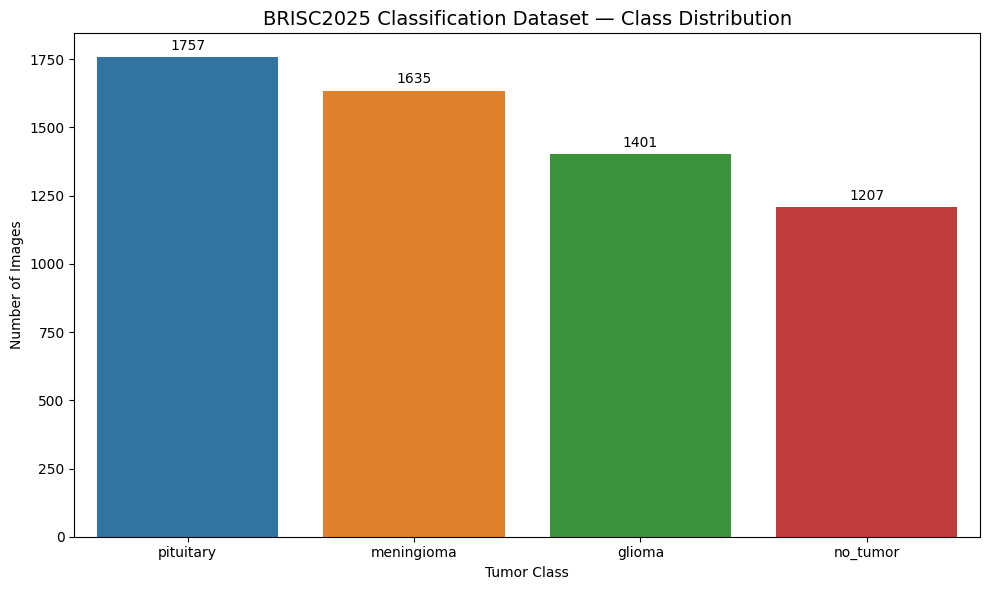


Class distribution figure saved:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\12_class_distribution.png


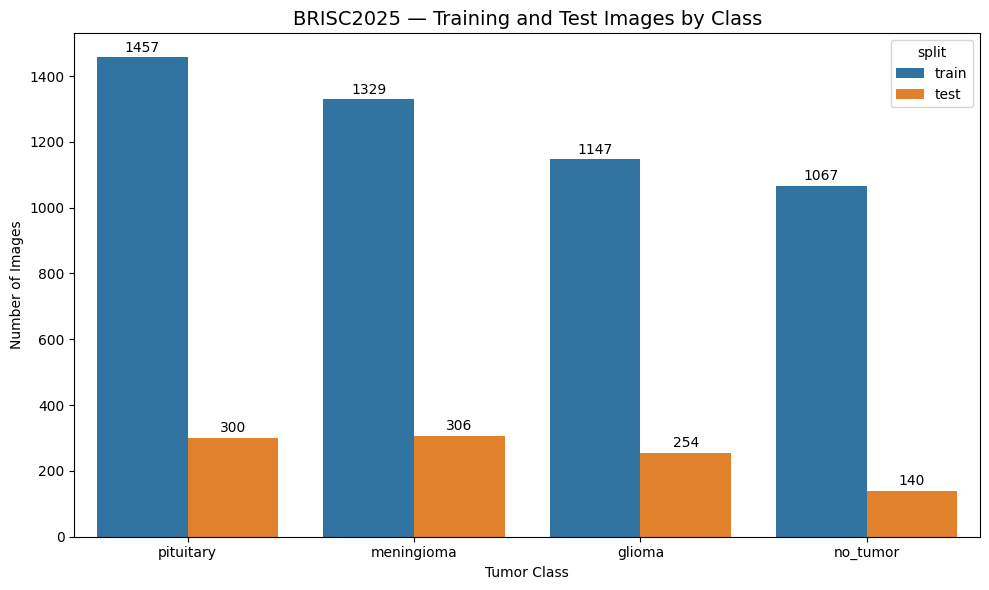


Train/test distribution figure saved:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\13_train_test_class_distribution.png

CELL 16 COMPLETE

Saved reports:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\class_distribution_detailed.csv
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\class_distribution_train_test.csv
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\training_class_weights.csv

Saved figures:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\12_class_distribution.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\13_train_test_class_distribution.png

Thesis master report updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md


In [18]:
# ============================================================
# CELL 16 — CLASS IMBALANCE & DISTRIBUTION ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

DATASET_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(
    DATASET_DIR / "manifest.csv"
)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# CLASS COUNTS
# ------------------------------------------------------------

class_counts = (
    classification["tumor_label"]
    .value_counts()
    .sort_values(ascending=False)
)

total_images = len(classification)

class_distribution = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values
})

class_distribution["percentage"] = (
    class_distribution["count"] /
    total_images *
    100
)

class_distribution["percentage"] = (
    class_distribution["percentage"]
    .round(2)
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("=" * 75)
print("CLASS IMBALANCE & DISTRIBUTION ANALYSIS")
print("=" * 75)

print("\nTotal classification images:")
print(total_images)

print("\nClass distribution:")

display(
    class_distribution
)

# ------------------------------------------------------------
# TRAIN / TEST CLASS DISTRIBUTION
# ------------------------------------------------------------

train_data = classification[
    classification["split"] == "train"
]

test_data = classification[
    classification["split"] == "test"
]

train_counts = (
    train_data["tumor_label"]
    .value_counts()
    .reindex(class_counts.index)
    .fillna(0)
    .astype(int)
)

test_counts = (
    test_data["tumor_label"]
    .value_counts()
    .reindex(class_counts.index)
    .fillna(0)
    .astype(int)
)

split_distribution = pd.DataFrame({
    "class": class_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values
})

split_distribution["train_percentage"] = (
    split_distribution["train_count"] /
    len(train_data) *
    100
).round(2)

split_distribution["test_percentage"] = (
    split_distribution["test_count"] /
    len(test_data) *
    100
).round(2)

print("\n" + "=" * 75)
print("TRAIN / TEST CLASS DISTRIBUTION")
print("=" * 75)

display(
    split_distribution
)

# ------------------------------------------------------------
# IMBALANCE MEASURES
# ------------------------------------------------------------

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = (
    largest_class /
    smallest_class
)

class_range = (
    largest_class -
    smallest_class
)

print("\n" + "=" * 75)
print("CLASS IMBALANCE METRICS")
print("=" * 75)

print(
    "\nLargest class:",
    class_counts.idxmax(),
    "=",
    largest_class
)

print(
    "Smallest class:",
    class_counts.idxmin(),
    "=",
    smallest_class
)

print(
    "Difference between largest and smallest:",
    class_range
)

print(
    "Largest-to-smallest class ratio:",
    round(imbalance_ratio, 3)
)

# ------------------------------------------------------------
# TRAINING CLASS WEIGHTS
# ------------------------------------------------------------

# Standard balanced-class weighting:
#
# weight = total_samples /
#          (number_of_classes × class_samples)

number_of_classes = len(class_counts)

class_weights = {}

for class_name, count in train_counts.items():

    class_weights[class_name] = (
        len(train_data) /
        (
            number_of_classes *
            count
        )
    )

class_weight_df = pd.DataFrame({
    "class": list(class_weights.keys()),
    "training_count": list(train_counts.values),
    "balanced_class_weight": list(
        class_weights.values()
    )
})

class_weight_df["balanced_class_weight"] = (
    class_weight_df["balanced_class_weight"]
    .round(4)
)

print("\n" + "=" * 75)
print("BALANCED CLASS WEIGHTS")
print("=" * 75)

display(
    class_weight_df
)

# ------------------------------------------------------------
# VISUALIZATION 1 — OVERALL CLASS DISTRIBUTION
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

ax = sns.barplot(
    data=class_distribution,
    x="class",
    y="count",
    errorbar=None
)

plt.title(
    "BRISC2025 Classification Dataset — Class Distribution",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Number of Images"
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

class_figure = (
    FIGURES_DIR /
    "12_class_distribution.png"
)

plt.savefig(
    class_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nClass distribution figure saved:"
)

print(class_figure)

# ------------------------------------------------------------
# VISUALIZATION 2 — TRAIN VS TEST
# ------------------------------------------------------------

plot_split = split_distribution.melt(
    id_vars="class",
    value_vars=[
        "train_count",
        "test_count"
    ],
    var_name="split",
    value_name="count"
)

plot_split["split"] = (
    plot_split["split"]
    .str.replace(
        "_count",
        "",
        regex=False
    )
)

plt.figure(
    figsize=(10, 6)
)

ax = sns.barplot(
    data=plot_split,
    x="class",
    y="count",
    hue="split",
    errorbar=None
)

plt.title(
    "BRISC2025 — Training and Test Images by Class",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Number of Images"
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%d",
        padding=2
    )

plt.tight_layout()

split_figure = (
    FIGURES_DIR /
    "13_train_test_class_distribution.png"
)

plt.savefig(
    split_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nTrain/test distribution figure saved:"
)

print(split_figure)

# ------------------------------------------------------------
# SAVE CSV FILES
# ------------------------------------------------------------

class_distribution.to_csv(
    REPORTS_DIR /
    "class_distribution_detailed.csv",
    index=False
)

split_distribution.to_csv(
    REPORTS_DIR /
    "class_distribution_train_test.csv",
    index=False
)

class_weight_df.to_csv(
    REPORTS_DIR /
    "training_class_weights.csv",
    index=False
)

# ------------------------------------------------------------
# UPDATE THESIS MASTER RECORD
# ------------------------------------------------------------

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 12. Class Imbalance Analysis\n\n"
    )

    f.write(
        f"The BRISC2025 classification dataset contains "
        f"{total_images} images distributed across four tumor "
        f"classes.\n\n"
    )

    f.write(
        class_distribution.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        f"The largest class is "
        f"**{class_counts.idxmax()}** with "
        f"{largest_class} images, while the smallest class is "
        f"**{class_counts.idxmin()}** with "
        f"{smallest_class} images. The largest-to-smallest "
        f"class ratio is **{imbalance_ratio:.3f}**.\n\n"
    )

    f.write(
        "The predefined training and test distributions were "
        "also examined separately to ensure that class "
        "composition is documented for model development and "
        "evaluation.\n\n"
    )

    f.write(
        split_distribution.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        "Balanced training class weights were calculated as a "
        "potential strategy for mitigating class imbalance "
        "during model training. The weights will be evaluated "
        "during the model-development stage rather than being "
        "automatically applied at this stage.\n\n"
    )

    f.write(
        f"Class distribution figure: "
        f"`outputs/figures/12_class_distribution.png`\n\n"
    )

    f.write(
        f"Training/test class distribution figure: "
        f"`outputs/figures/13_train_test_class_distribution.png`\n"
    )

# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 16 COMPLETE")
print("=" * 75)

print("\nSaved reports:")
print(
    REPORTS_DIR /
    "class_distribution_detailed.csv"
)

print(
    REPORTS_DIR /
    "class_distribution_train_test.csv"
)

print(
    REPORTS_DIR /
    "training_class_weights.csv"
)

print("\nSaved figures:")
print(class_figure)
print(split_figure)

print("\nThesis master report updated:")
print(thesis_record)

REPRESENTATIVE MRI IMAGE ANALYSIS

Representative images selected: 12


,class,plane,split,filename
0,glioma,axial,test,brisc2025_test_00001_gl_ax_t1.jpg
1,glioma,coronal,test,brisc2025_test_00086_gl_co_t1.jpg
2,glioma,sagittal,test,brisc2025_test_00167_gl_sa_t1.jpg
3,meningioma,axial,test,brisc2025_test_00255_me_ax_t1.jpg
4,meningioma,coronal,test,brisc2025_test_00392_me_co_t1.jpg
5,meningioma,sagittal,test,brisc2025_test_00478_me_sa_t1.jpg
6,pituitary,axial,test,brisc2025_test_00701_pi_ax_t1.jpg
7,pituitary,coronal,test,brisc2025_test_00825_pi_co_t1.jpg
8,pituitary,sagittal,test,brisc2025_test_00915_pi_sa_t1.jpg
9,no_tumor,axial,test,brisc2025_test_00561_no_ax_t1.jpg


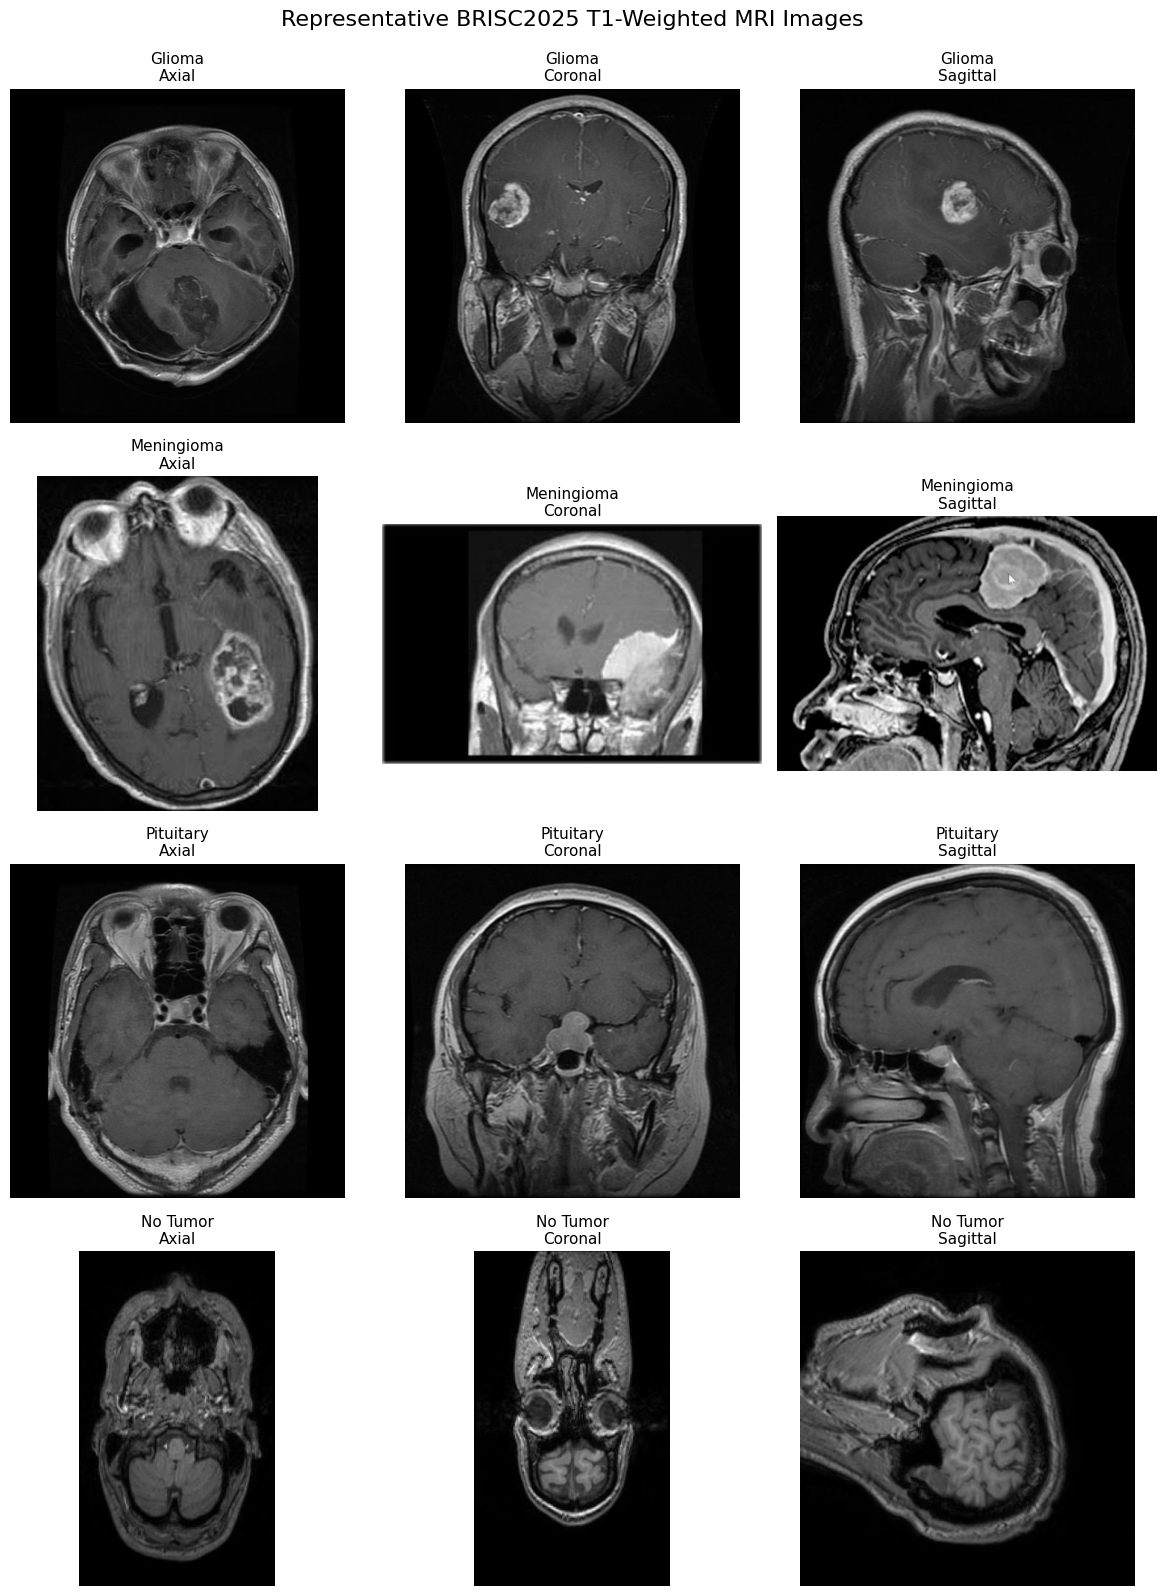


Representative MRI figure saved:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\14_representative_mri_images.png

PIXEL INTENSITY ANALYSIS
glioma: 200 images sampled
meningioma: 200 images sampled
pituitary: 200 images sampled
no_tumor: 200 images sampled

Successfully analyzed 800 images.

Intensity summary by class:


,class,images,mean_intensity,std_of_mean_intensity,median_intensity,mean_pixel_std,mean_nonzero_percentage
0,glioma,200,32.433,8.428,13.215,38.561,78.132
1,meningioma,200,45.133,15.658,28.410,48.197,85.489
2,pituitary,200,48.200,7.533,44.590,41.094,91.703
3,no_tumor,200,50.426,14.113,34.935,51.955,74.722


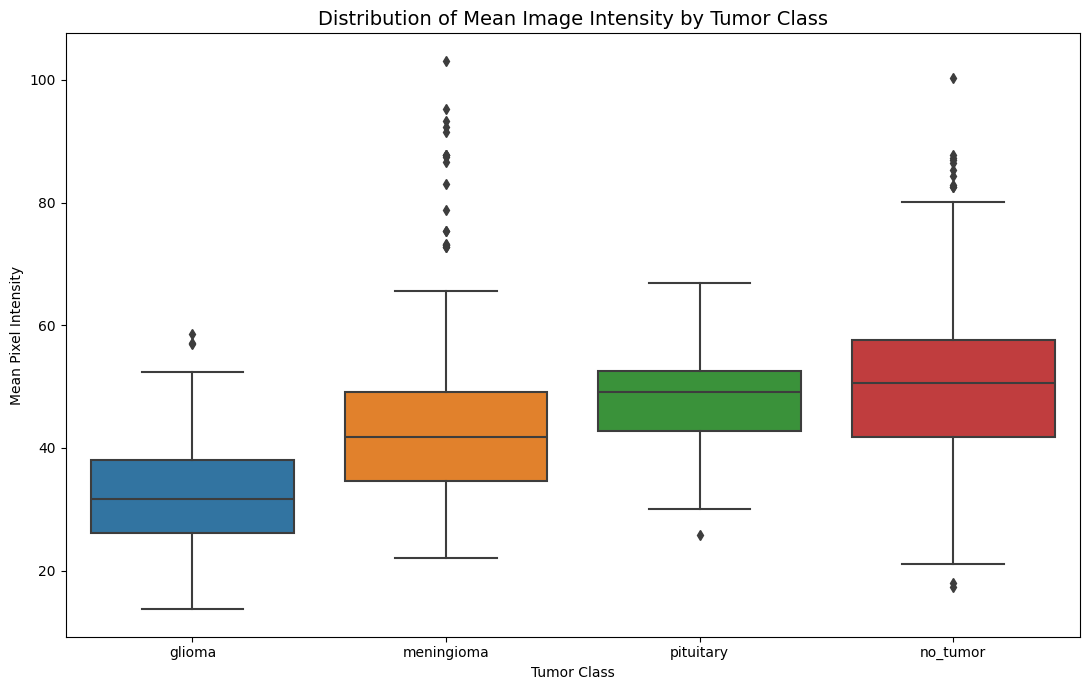


Intensity boxplot saved:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\15_mean_intensity_by_class.png


c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

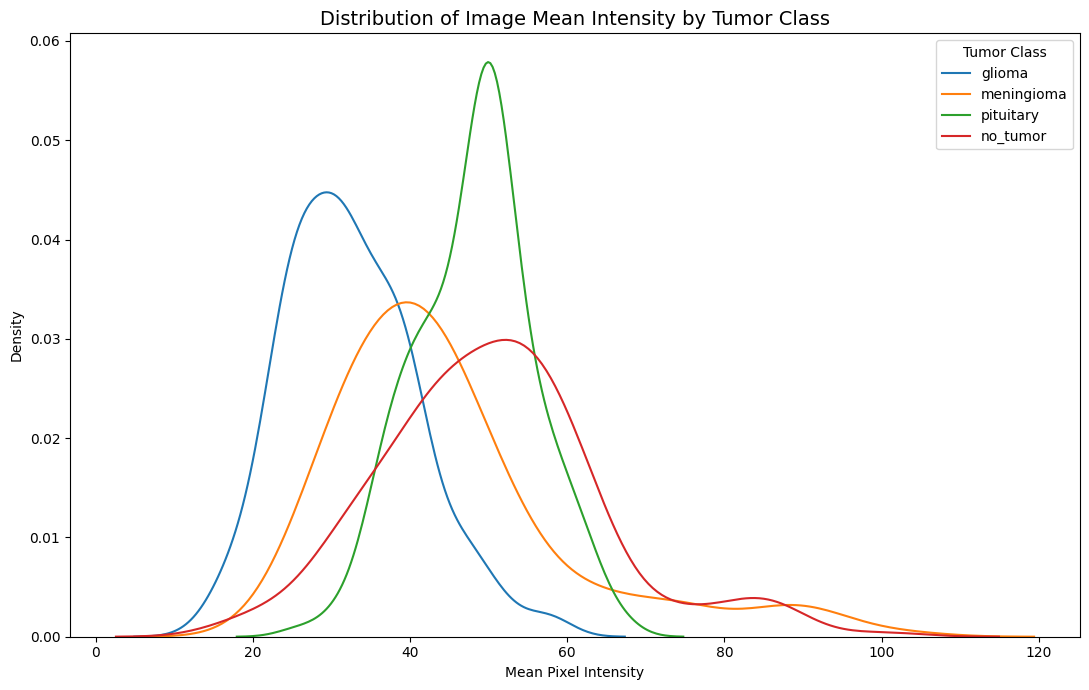


Intensity density figure saved:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\16_mean_intensity_density_by_class.png

CELL 17 COMPLETE

Saved reports:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\pixel_intensity_summary_by_class.csv
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\pixel_intensity_image_level_sample.csv

Saved figures:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\14_representative_mri_images.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\15_mean_intensity_by_class.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\16_mean_intensity_density_by_class.png

Master thesis report updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md


In [19]:
# ============================================================
# CELL 17 — VISUAL MRI & PIXEL INTENSITY ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

DATASET_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(
    DATASET_DIR / "manifest.csv"
)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

plane_order = [
    "axial",
    "coronal",
    "sagittal"
]

# ------------------------------------------------------------
# FIND IMAGE PATH
# ------------------------------------------------------------

def get_image_path(relative_path):

    path = DATASET_DIR / relative_path

    if path.exists():
        return path

    # Fallback using filename search
    filename = Path(relative_path).name

    matches = list(
        DATASET_DIR.rglob(filename)
    )

    if len(matches) > 0:
        return matches[0]

    return None


# ============================================================
# PART A — REPRESENTATIVE MRI IMAGES
# ============================================================

print("=" * 75)
print("REPRESENTATIVE MRI IMAGE ANALYSIS")
print("=" * 75)

# We will select one deterministic image for every
# class × plane combination.
#
# This produces:
# 4 tumor classes × 3 MRI planes = 12 images.

representative_records = []

for class_name in class_order:

    for plane_name in plane_order:

        candidates = classification[
            (classification["tumor_label"] == class_name) &
            (classification["plane_label"] == plane_name)
        ].copy()

        candidates = candidates.sort_values(
            by=["split", "index"]
        )

        if len(candidates) == 0:
            continue

        selected = candidates.iloc[0]

        image_path = get_image_path(
            selected["relative_path"]
        )

        if image_path is not None:

            representative_records.append({
                "class": class_name,
                "plane": plane_name,
                "split": selected["split"],
                "filename": selected["filename"],
                "path": str(image_path)
            })


representative_df = pd.DataFrame(
    representative_records
)

print(
    f"\nRepresentative images selected: "
    f"{len(representative_df)}"
)

display(
    representative_df[
        [
            "class",
            "plane",
            "split",
            "filename"
        ]
    ]
)

# ------------------------------------------------------------
# PLOT REPRESENTATIVE IMAGES
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 16)
)

for row, class_name in enumerate(class_order):

    for col, plane_name in enumerate(plane_order):

        ax = axes[row, col]

        subset = representative_df[
            (representative_df["class"] == class_name) &
            (representative_df["plane"] == plane_name)
        ]

        if len(subset) == 0:

            ax.axis("off")
            continue

        image_path = Path(
            subset.iloc[0]["path"]
        )

        try:

            image = Image.open(
                image_path
            )

            ax.imshow(
                image,
                cmap="gray"
            )

            ax.set_title(
                f"{class_name.replace('_', ' ').title()}\n"
                f"{plane_name.title()}",
                fontsize=11
            )

            ax.axis("off")

        except Exception as e:

            ax.text(
                0.5,
                0.5,
                f"Image error\n{e}",
                ha="center",
                va="center"
            )

            ax.axis("off")


plt.suptitle(
    "Representative BRISC2025 T1-Weighted MRI Images",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

representative_figure = (
    FIGURES_DIR /
    "14_representative_mri_images.png"
)

plt.savefig(
    representative_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nRepresentative MRI figure saved:"
)

print(
    representative_figure
)


# ============================================================
# PART B — PIXEL INTENSITY ANALYSIS
# ============================================================

print("\n" + "=" * 75)
print("PIXEL INTENSITY ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# SAMPLE IMAGES
# ------------------------------------------------------------
#
# Full-pixel analysis of all 6000 images would be unnecessarily
# memory-intensive. We therefore use a reproducible sample of
# 200 images per class.
#
# This gives 800 images total.

RANDOM_STATE = 42
SAMPLES_PER_CLASS = 200

intensity_records = []

for class_name in class_order:

    class_images = classification[
        classification["tumor_label"] == class_name
    ].sample(
        n=min(
            SAMPLES_PER_CLASS,
            len(
                classification[
                    classification["tumor_label"] == class_name
                ]
            )
        ),
        random_state=RANDOM_STATE
    )

    print(
        f"{class_name}: "
        f"{len(class_images)} images sampled"
    )

    for _, row in class_images.iterrows():

        image_path = get_image_path(
            row["relative_path"]
        )

        if image_path is None:
            continue

        try:

            image = Image.open(
                image_path
            )

            image_array = np.asarray(
                image
            )

            # Convert RGB image to grayscale only for
            # intensity statistics.
            #
            # This does NOT modify the original dataset.

            if image_array.ndim == 3:

                intensity_array = (
                    0.299 * image_array[:, :, 0] +
                    0.587 * image_array[:, :, 1] +
                    0.114 * image_array[:, :, 2]
                )

            else:

                intensity_array = image_array.astype(
                    np.float32
                )

            intensity_array = intensity_array.astype(
                np.float32
            )

            intensity_records.append({
                "class": row["tumor_label"],
                "plane": row["plane_label"],
                "split": row["split"],
                "filename": row["filename"],
                "mean_intensity": float(
                    np.mean(intensity_array)
                ),
                "median_intensity": float(
                    np.median(intensity_array)
                ),
                "std_intensity": float(
                    np.std(intensity_array)
                ),
                "min_intensity": float(
                    np.min(intensity_array)
                ),
                "max_intensity": float(
                    np.max(intensity_array)
                ),
                "nonzero_percentage": float(
                    np.mean(
                        intensity_array > 0
                    ) * 100
                )
            })

        except Exception as e:

            print(
                f"Could not process "
                f"{row['filename']}: {e}"
            )


intensity_df = pd.DataFrame(
    intensity_records
)

print(
    f"\nSuccessfully analyzed "
    f"{len(intensity_df)} images."
)

# ------------------------------------------------------------
# INTENSITY SUMMARY BY CLASS
# ------------------------------------------------------------

intensity_summary = (
    intensity_df
    .groupby("class")
    .agg(
        images=("filename", "count"),
        mean_intensity=("mean_intensity", "mean"),
        std_of_mean_intensity=("mean_intensity", "std"),
        median_intensity=("median_intensity", "mean"),
        mean_pixel_std=("std_intensity", "mean"),
        mean_nonzero_percentage=("nonzero_percentage", "mean")
    )
    .reindex(class_order)
    .reset_index()
)

numeric_columns = [
    "mean_intensity",
    "std_of_mean_intensity",
    "median_intensity",
    "mean_pixel_std",
    "mean_nonzero_percentage"
]

intensity_summary[numeric_columns] = (
    intensity_summary[numeric_columns]
    .round(3)
)

print("\nIntensity summary by class:")

display(
    intensity_summary
)

# ------------------------------------------------------------
# SAVE INTENSITY SUMMARY
# ------------------------------------------------------------

intensity_summary.to_csv(
    REPORTS_DIR /
    "pixel_intensity_summary_by_class.csv",
    index=False
)

intensity_df.to_csv(
    REPORTS_DIR /
    "pixel_intensity_image_level_sample.csv",
    index=False
)


# ============================================================
# PART C — INTENSITY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(11, 7)
)

sns.boxplot(
    data=intensity_df,
    x="class",
    y="mean_intensity",
    order=class_order
)

plt.title(
    "Distribution of Mean Image Intensity by Tumor Class",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Mean Pixel Intensity"
)

plt.tight_layout()

intensity_boxplot = (
    FIGURES_DIR /
    "15_mean_intensity_by_class.png"
)

plt.savefig(
    intensity_boxplot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nIntensity boxplot saved:"
)

print(
    intensity_boxplot
)


# ============================================================
# PART D — PIXEL INTENSITY DISTRIBUTION HISTOGRAM
# ============================================================

plt.figure(
    figsize=(11, 7)
)

for class_name in class_order:

    values = intensity_df.loc[
        intensity_df["class"] == class_name,
        "mean_intensity"
    ]

    sns.kdeplot(
        values,
        label=class_name,
        fill=False
    )

plt.title(
    "Distribution of Image Mean Intensity by Tumor Class",
    fontsize=14
)

plt.xlabel(
    "Mean Pixel Intensity"
)

plt.ylabel(
    "Density"
)

plt.legend(
    title="Tumor Class"
)

plt.tight_layout()

intensity_density = (
    FIGURES_DIR /
    "16_mean_intensity_density_by_class.png"
)

plt.savefig(
    intensity_density,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nIntensity density figure saved:"
)

print(
    intensity_density
)


# ============================================================
# PART E — UPDATE MASTER THESIS RECORD
# ============================================================

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 13. Representative MRI Image Analysis\n\n"
    )

    f.write(
        "Representative T1-weighted MRI images were selected "
        "across all four classification classes and the three "
        "available anatomical planes (axial, coronal and "
        "sagittal). One deterministic representative image "
        "was selected for each class-plane combination.\n\n"
    )

    f.write(
        "The representative-image figure is stored at "
        "`outputs/figures/14_representative_mri_images.png`.\n\n"
    )

    f.write(
        "## 14. Pixel Intensity Analysis\n\n"
    )

    f.write(
        "Pixel-intensity characteristics were examined using "
        "a reproducible sample of up to 200 classification "
        "images per tumor class (random_state = 42), giving "
        "a maximum sample size of 800 images. Intensity "
        "statistics were calculated without modifying the "
        "original dataset. RGB images were converted to "
        "grayscale only for the purpose of intensity "
        "statistics.\n\n"
    )

    f.write(
        intensity_summary.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        "The image-level mean-intensity distribution is "
        "visualized using a boxplot and density plot. These "
        "analyses are descriptive and are intended to identify "
        "potential class-associated intensity differences "
        "before model development.\n\n"
    )

    f.write(
        "Intensity boxplot: "
        "`outputs/figures/15_mean_intensity_by_class.png`\n\n"
    )

    f.write(
        "Intensity density plot: "
        "`outputs/figures/16_mean_intensity_density_by_class.png`\n"
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 17 COMPLETE")
print("=" * 75)

print("\nSaved reports:")

print(
    REPORTS_DIR /
    "pixel_intensity_summary_by_class.csv"
)

print(
    REPORTS_DIR /
    "pixel_intensity_image_level_sample.csv"
)

print("\nSaved figures:")

print(
    FIGURES_DIR /
    "14_representative_mri_images.png"
)

print(
    FIGURES_DIR /
    "15_mean_intensity_by_class.png"
)

print(
    FIGURES_DIR /
    "16_mean_intensity_density_by_class.png"
)

print("\nMaster thesis report updated:")
print(thesis_record)

PART A — IMAGE MODE VS TUMOR CLASS

Total classification images: 6000
Reading image modes from actual image files...
Processed 1000/6000 images...
Processed 2000/6000 images...
Processed 3000/6000 images...
Processed 4000/6000 images...
Processed 5000/6000 images...
Processed 6000/6000 images...

Successfully analyzed image mode for 6000 images.

Overall image mode distribution:


,mode,count
0,RGB,3134
1,Grayscale,2866



Image mode by tumor class:


mode,Grayscale,RGB
class,,
glioma,1227,174
meningioma,709,926
pituitary,930,827
no_tumor,0,1207



Chi-square test — Image Mode vs Class
Chi-square statistic = 2025.349990
Degrees of freedom = 3
p-value = 0.000000e+00
Cramer's V = 0.580998
Effect-size interpretation: relatively strong association

Image mode percentages within each class:


...

,class,sample_size,mean,median,standard_deviation,minimum,maximum
0,glioma,200,32.433,31.696,8.428,13.693,58.577
1,meningioma,200,45.133,41.771,15.658,22.058,103.131
2,pituitary,200,48.200,49.111,7.533,25.801,66.945
3,no_tumor,200,50.426,50.577,14.113,17.270,100.264



MASTER STATISTICAL TEST SUMMARY


,analysis,test,test_statistic,degrees_of_freedom,p_value,effect_size,effect_size_measure
0,Image mode vs tumor class,Chi-square test of independence,2025.349990,3.0,0.000000,0.580998,Cramer's V
1,MRI plane vs tumor class,Chi-square test of independence,26.308353,6.0,0.000195,0.046823,Cramer's V
2,Mean intensity vs tumor class,Kruskal-Wallis H test,260.358090,NaN,0.000000,0.323314,Epsilon-squared



Mode plotting data:


,class,image_mode,percentage
0,glioma,Grayscale,87.58
1,meningioma,Grayscale,43.36
2,pituitary,Grayscale,52.93
3,no_tumor,Grayscale,0.00
4,glioma,RGB,12.42
5,meningioma,RGB,56.64
6,pituitary,RGB,47.07
7,no_tumor,RGB,100.00


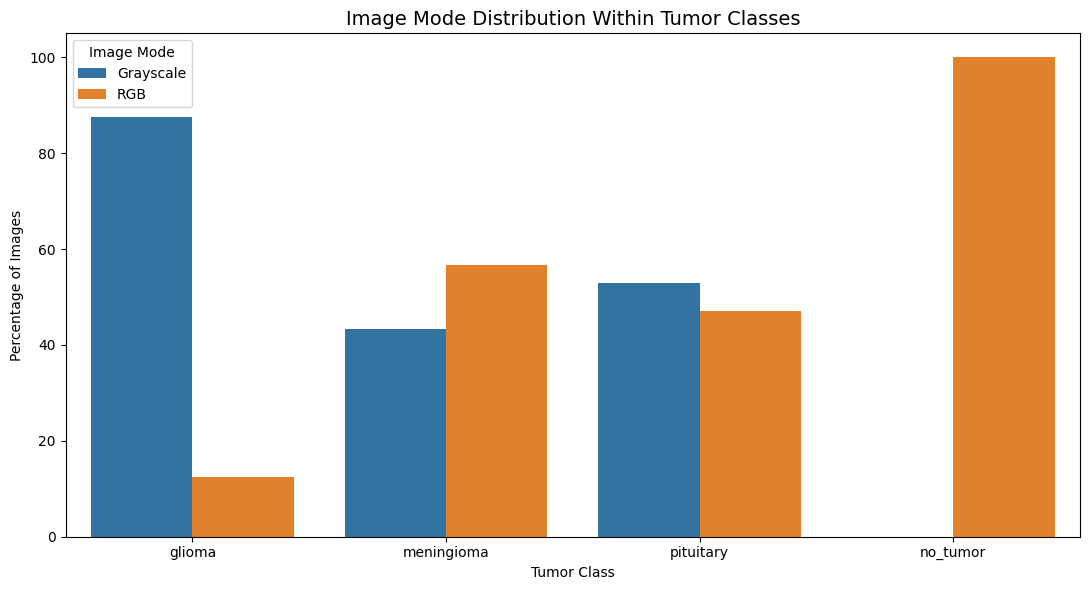


Plane plotting data:


,class,plane,percentage
0,glioma,axial,34.19
1,meningioma,axial,34.25
2,pituitary,axial,31.30
3,no_tumor,axial,33.47
4,glioma,coronal,36.47
5,meningioma,coronal,31.31
6,pituitary,coronal,34.15
7,no_tumor,coronal,29.66
8,glioma,sagittal,29.34
9,meningioma,sagittal,34.43


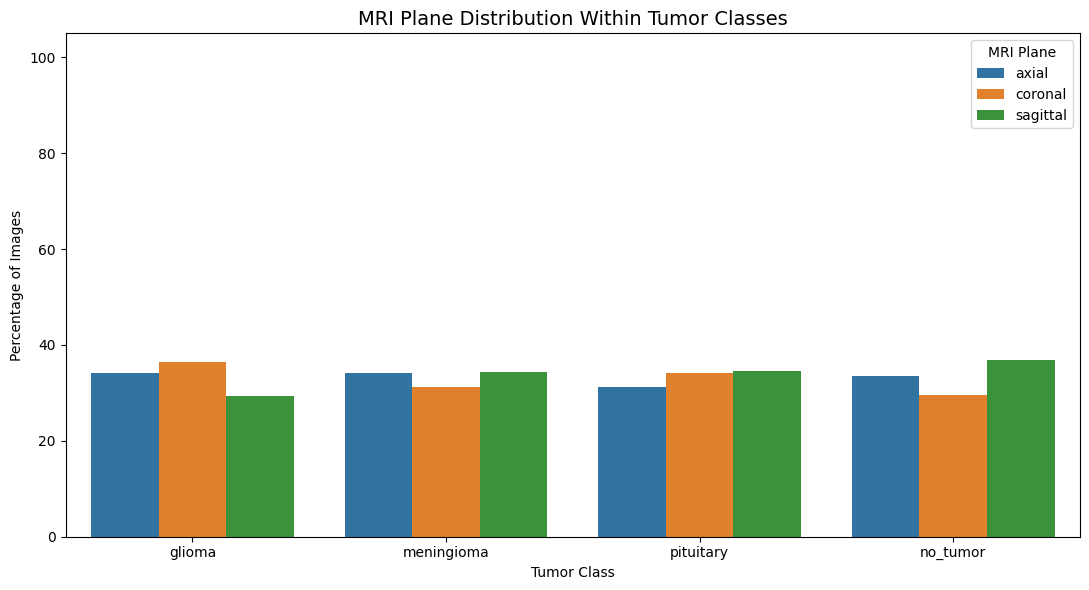


CELL 18 COMPLETE — NO ERRORS

Statistical results:
Image mode vs class: p = 0.000000e+00, Cramer's V = 0.580998
MRI plane vs class: p = 1.950362e-04, Cramer's V = 0.046823
Mean intensity vs class: p = 3.761346e-56, Epsilon² = 0.323314

Reports saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports

Figures saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures

Master thesis report updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md


In [23]:
# ============================================================
# CELL 18 — STATISTICAL ASSOCIATION ANALYSIS
# FINAL CORRECTED VERSION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from scipy.stats import chi2_contingency, kruskal

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

DATASET_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

manifest = pd.read_csv(
    DATASET_DIR / "manifest.csv"
)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# CLASS / PLANE ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

plane_order = [
    "axial",
    "coronal",
    "sagittal"
]

# ============================================================
# PART A — DETERMINE IMAGE MODE FROM ACTUAL IMAGE FILES
# ============================================================

print("=" * 75)
print("PART A — IMAGE MODE VS TUMOR CLASS")
print("=" * 75)

mode_records = []

total_images = len(classification)

print(
    f"\nTotal classification images: {total_images}"
)
print(
    "Reading image modes from actual image files..."
)

for counter, (_, row) in enumerate(
    classification.iterrows(),
    start=1
):

    image_path = DATASET_DIR / row["relative_path"]

    # Fallback if relative path does not resolve
    if not image_path.exists():

        filename = Path(
            row["relative_path"]
        ).name

        matches = list(
            DATASET_DIR.rglob(filename)
        )

        if len(matches) > 0:

            image_path = matches[0]

    try:

        with Image.open(image_path) as image:

            original_mode = image.mode

        # Standardize mode categories for analysis
        if original_mode == "RGB":

            image_mode = "RGB"

        elif original_mode == "L":

            image_mode = "Grayscale"

        else:

            image_mode = original_mode

        mode_records.append({

            "filename": row["filename"],

            "class": row["tumor_label"],

            "plane": row["plane_label"],

            "split": row["split"],

            "mode": image_mode

        })

    except Exception as e:

        print(
            f"ERROR: {row['filename']} -> {e}"
        )

    if counter % 1000 == 0:

        print(
            f"Processed {counter}/{total_images} images..."
        )


mode_df = pd.DataFrame(
    mode_records
)

print(
    f"\nSuccessfully analyzed image mode for "
    f"{len(mode_df)} images."
)

print("\nOverall image mode distribution:")

display(
    mode_df["mode"]
    .value_counts()
    .rename_axis("mode")
    .reset_index(name="count")
)

# ------------------------------------------------------------
# IMAGE MODE × CLASS CONTINGENCY TABLE
# ------------------------------------------------------------

mode_class_table = pd.crosstab(
    mode_df["class"],
    mode_df["mode"]
)

mode_class_table = mode_class_table.reindex(
    class_order
)

print(
    "\nImage mode by tumor class:"
)

display(
    mode_class_table
)

# ------------------------------------------------------------
# CHI-SQUARE TEST
# ------------------------------------------------------------

chi2_mode, p_mode, dof_mode, expected_mode = (
    chi2_contingency(
        mode_class_table
    )
)

# ------------------------------------------------------------
# CRAMER'S V
# ------------------------------------------------------------

n_mode = mode_class_table.to_numpy().sum()

min_dimension_mode = min(
    mode_class_table.shape
)

cramers_v_mode = np.sqrt(
    chi2_mode /
    (
        n_mode *
        (min_dimension_mode - 1)
    )
)

print("\nChi-square test — Image Mode vs Class")

print(
    f"Chi-square statistic = {chi2_mode:.6f}"
)

print(
    f"Degrees of freedom = {dof_mode}"
)

print(
    f"p-value = {p_mode:.6e}"
)

print(
    f"Cramer's V = {cramers_v_mode:.6f}"
)

# ------------------------------------------------------------
# CRAMER'S V INTERPRETATION
# ------------------------------------------------------------

def interpret_cramers_v(v):

    if v < 0.10:

        return "negligible association"

    elif v < 0.20:

        return "weak association"

    elif v < 0.40:

        return "moderate association"

    elif v < 0.60:

        return "relatively strong association"

    else:

        return "strong association"


mode_effect_interpretation = (
    interpret_cramers_v(
        cramers_v_mode
    )
)

print(
    "Effect-size interpretation:",
    mode_effect_interpretation
)

# ------------------------------------------------------------
# MODE PERCENTAGES WITHIN CLASS
# ------------------------------------------------------------

mode_class_percentage = (
    mode_class_table
    .div(
        mode_class_table.sum(axis=1),
        axis=0
    )
    * 100
)

mode_class_percentage = (
    mode_class_percentage.round(2)
)

print(
    "\nImage mode percentages within each class:"
)

display(
    mode_class_percentage
)

# ------------------------------------------------------------
# SAVE MODE ANALYSIS
# ------------------------------------------------------------

mode_df.to_csv(
    REPORTS_DIR /
    "image_mode_image_level_analysis.csv",
    index=False
)

mode_class_table.to_csv(
    REPORTS_DIR /
    "image_mode_class_contingency_table.csv"
)

mode_class_percentage.to_csv(
    REPORTS_DIR /
    "image_mode_class_percentage.csv"
)

# ============================================================
# PART B — MRI PLANE VS TUMOR CLASS
# ============================================================

print("\n" + "=" * 75)
print("PART B — MRI PLANE VS TUMOR CLASS")
print("=" * 75)

plane_class_table = pd.crosstab(
    classification["tumor_label"],
    classification["plane_label"]
)

plane_class_table = (
    plane_class_table
    .reindex(
        index=class_order,
        columns=plane_order
    )
    .fillna(0)
    .astype(int)
)

print(
    "\nMRI plane by tumor class:"
)

display(
    plane_class_table
)

# ------------------------------------------------------------
# CHI-SQUARE TEST
# ------------------------------------------------------------

chi2_plane, p_plane, dof_plane, expected_plane = (
    chi2_contingency(
        plane_class_table
    )
)

# ------------------------------------------------------------
# CRAMER'S V
# ------------------------------------------------------------

n_plane = plane_class_table.to_numpy().sum()

min_dimension_plane = min(
    plane_class_table.shape
)

cramers_v_plane = np.sqrt(
    chi2_plane /
    (
        n_plane *
        (min_dimension_plane - 1)
    )
)

print(
    "\nChi-square test — MRI Plane vs Class"
)

print(
    f"Chi-square statistic = {chi2_plane:.6f}"
)

print(
    f"Degrees of freedom = {dof_plane}"
)

print(
    f"p-value = {p_plane:.6e}"
)

print(
    f"Cramer's V = {cramers_v_plane:.6f}"
)

plane_effect_interpretation = (
    interpret_cramers_v(
        cramers_v_plane
    )
)

print(
    "Effect-size interpretation:",
    plane_effect_interpretation
)

# ------------------------------------------------------------
# PLANE PERCENTAGES WITHIN CLASS
# ------------------------------------------------------------

plane_class_percentage = (
    plane_class_table
    .div(
        plane_class_table.sum(axis=1),
        axis=0
    )
    * 100
)

plane_class_percentage = (
    plane_class_percentage.round(2)
)

print(
    "\nMRI plane percentages within each class:"
)

display(
    plane_class_percentage
)

# ------------------------------------------------------------
# SAVE PLANE ANALYSIS
# ------------------------------------------------------------

plane_class_table.to_csv(
    REPORTS_DIR /
    "mri_plane_class_contingency_table.csv"
)

plane_class_percentage.to_csv(
    REPORTS_DIR /
    "mri_plane_class_percentage.csv"
)

# ============================================================
# PART C — IMAGE INTENSITY VS TUMOR CLASS
# ============================================================

print("\n" + "=" * 75)
print("PART C — IMAGE INTENSITY VS TUMOR CLASS")
print("=" * 75)

# Cell 17 must already have been executed
if "intensity_df" not in globals():

    raise RuntimeError(
        "\n'intensity_df' is not available.\n"
        "Run Cell 17 first, then run Cell 18."
    )

# ------------------------------------------------------------
# CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_intensity_columns = [
    "class",
    "mean_intensity"
]

missing_columns = [
    column
    for column in required_intensity_columns
    if column not in intensity_df.columns
]

if len(missing_columns) > 0:

    raise RuntimeError(
        f"Missing required columns in intensity_df: "
        f"{missing_columns}"
    )

# ------------------------------------------------------------
# GROUP INTENSITY VALUES
# ------------------------------------------------------------

intensity_groups = []

for class_name in class_order:

    values = (
        intensity_df.loc[
            intensity_df["class"] == class_name,
            "mean_intensity"
        ]
        .dropna()
        .values
    )

    intensity_groups.append(
        values
    )

    print(
        f"{class_name}: n = {len(values)}"
    )

# ------------------------------------------------------------
# KRUSKAL-WALLIS TEST
# ------------------------------------------------------------

kruskal_statistic, kruskal_p = kruskal(
    *intensity_groups
)

print(
    "\nKruskal-Wallis test — Mean Intensity vs Class"
)

print(
    f"H statistic = {kruskal_statistic:.6f}"
)

print(
    f"p-value = {kruskal_p:.6e}"
)

# ------------------------------------------------------------
# EPSILON-SQUARED EFFECT SIZE
# ------------------------------------------------------------

k = len(
    intensity_groups
)

N = sum(
    len(group)
    for group in intensity_groups
)

epsilon_squared = (
    kruskal_statistic - k + 1
) / (
    N - k
)

epsilon_squared = max(
    0,
    epsilon_squared
)

print(
    f"Epsilon-squared = "
    f"{epsilon_squared:.6f}"
)

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

if epsilon_squared < 0.01:

    intensity_effect_interpretation = (
        "negligible effect"
    )

elif epsilon_squared < 0.08:

    intensity_effect_interpretation = (
        "small effect"
    )

elif epsilon_squared < 0.26:

    intensity_effect_interpretation = (
        "moderate effect"
    )

else:

    intensity_effect_interpretation = (
        "large effect"
    )

print(
    "Effect-size interpretation:",
    intensity_effect_interpretation
)

# ------------------------------------------------------------
# DESCRIPTIVE INTENSITY STATISTICS
# ------------------------------------------------------------

intensity_statistical_summary = (
    intensity_df
    .groupby("class")["mean_intensity"]
    .agg(
        sample_size="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
    .reindex(class_order)
    .reset_index()
)

intensity_statistical_summary[
    [
        "mean",
        "median",
        "standard_deviation",
        "minimum",
        "maximum"
    ]
] = (
    intensity_statistical_summary[
        [
            "mean",
            "median",
            "standard_deviation",
            "minimum",
            "maximum"
        ]
    ].round(3)
)

print(
    "\nIntensity descriptive statistics:"
)

display(
    intensity_statistical_summary
)

intensity_statistical_summary.to_csv(
    REPORTS_DIR /
    "intensity_statistical_summary.csv",
    index=False
)

# ============================================================
# PART D — MASTER STATISTICAL RESULTS TABLE
# ============================================================

statistical_results = pd.DataFrame({

    "analysis": [
        "Image mode vs tumor class",
        "MRI plane vs tumor class",
        "Mean intensity vs tumor class"
    ],

    "test": [
        "Chi-square test of independence",
        "Chi-square test of independence",
        "Kruskal-Wallis H test"
    ],

    "test_statistic": [
        chi2_mode,
        chi2_plane,
        kruskal_statistic
    ],

    "degrees_of_freedom": [
        dof_mode,
        dof_plane,
        np.nan
    ],

    "p_value": [
        p_mode,
        p_plane,
        kruskal_p
    ],

    "effect_size": [
        cramers_v_mode,
        cramers_v_plane,
        epsilon_squared
    ],

    "effect_size_measure": [
        "Cramer's V",
        "Cramer's V",
        "Epsilon-squared"
    ]
})

statistical_results[
    "test_statistic"
] = statistical_results[
    "test_statistic"
].round(6)

statistical_results[
    "p_value"
] = statistical_results[
    "p_value"
].round(10)

statistical_results[
    "effect_size"
] = statistical_results[
    "effect_size"
].round(6)

print(
    "\n" + "=" * 75
)

print(
    "MASTER STATISTICAL TEST SUMMARY"
)

print(
    "=" * 75
)

display(
    statistical_results
)

statistical_results.to_csv(
    REPORTS_DIR /
    "statistical_association_results.csv",
    index=False
)

# ============================================================
# PART E — IMAGE MODE FIGURE
# ============================================================

# Convert the contingency table into a clean plotting table.
# We explicitly rename the class column to avoid index-name
# problems.

mode_plot_data = (
    mode_class_percentage
    .copy()
    .reset_index()
)

mode_plot_data = mode_plot_data.rename(
    columns={
        mode_plot_data.columns[0]: "class"
    }
)

mode_plot_data = mode_plot_data.melt(
    id_vars="class",
    var_name="image_mode",
    value_name="percentage"
)

print(
    "\nMode plotting data:"
)

display(
    mode_plot_data
)

plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=mode_plot_data,
    x="class",
    y="percentage",
    hue="image_mode",
    errorbar=None
)

plt.title(
    "Image Mode Distribution Within Tumor Classes",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Percentage of Images"
)

plt.ylim(
    0,
    105
)

plt.legend(
    title="Image Mode"
)

plt.tight_layout()

mode_figure = (
    FIGURES_DIR /
    "17_image_mode_by_class_statistical_analysis.png"
)

plt.savefig(
    mode_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART F — MRI PLANE FIGURE
# ============================================================

plane_plot_data = (
    plane_class_percentage
    .copy()
    .reset_index()
)

plane_plot_data = plane_plot_data.rename(
    columns={
        plane_plot_data.columns[0]: "class"
    }
)

plane_plot_data = plane_plot_data.melt(
    id_vars="class",
    var_name="plane",
    value_name="percentage"
)

print(
    "\nPlane plotting data:"
)

display(
    plane_plot_data
)

plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=plane_plot_data,
    x="class",
    y="percentage",
    hue="plane",
    errorbar=None
)

plt.title(
    "MRI Plane Distribution Within Tumor Classes",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Percentage of Images"
)

plt.ylim(
    0,
    105
)

plt.legend(
    title="MRI Plane"
)

plt.tight_layout()

plane_figure = (
    FIGURES_DIR /
    "18_mri_plane_by_class_statistical_analysis.png"
)

plt.savefig(
    plane_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART G — SAVE COMPLETE STATISTICAL TEXT RECORD
# ============================================================

statistical_text_record = (
    REPORTS_DIR /
    "statistical_analysis_interpretation.md"
)

with open(
    statistical_text_record,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# BRISC2025 Statistical Association Analysis\n\n"
    )

    f.write(
        "## 1. Image Mode vs Tumor Class\n\n"
    )

    f.write(
        f"- Chi-square statistic: {chi2_mode:.6f}\n"
    )

    f.write(
        f"- Degrees of freedom: {dof_mode}\n"
    )

    f.write(
        f"- p-value: {p_mode:.6e}\n"
    )

    f.write(
        f"- Cramer's V: {cramers_v_mode:.6f}\n"
    )

    f.write(
        f"- Effect interpretation: "
        f"{mode_effect_interpretation}\n\n"
    )

    f.write(
        "## 2. MRI Plane vs Tumor Class\n\n"
    )

    f.write(
        f"- Chi-square statistic: {chi2_plane:.6f}\n"
    )

    f.write(
        f"- Degrees of freedom: {dof_plane}\n"
    )

    f.write(
        f"- p-value: {p_plane:.6e}\n"
    )

    f.write(
        f"- Cramer's V: {cramers_v_plane:.6f}\n"
    )

    f.write(
        f"- Effect interpretation: "
        f"{plane_effect_interpretation}\n\n"
    )

    f.write(
        "## 3. Mean Pixel Intensity vs Tumor Class\n\n"
    )

    f.write(
        f"- Kruskal-Wallis H statistic: "
        f"{kruskal_statistic:.6f}\n"
    )

    f.write(
        f"- p-value: {kruskal_p:.6e}\n"
    )

    f.write(
        f"- Epsilon-squared: "
        f"{epsilon_squared:.6f}\n"
    )

    f.write(
        f"- Effect interpretation: "
        f"{intensity_effect_interpretation}\n\n"
    )

    f.write(
        "## Important methodological note\n\n"
    )

    f.write(
        "Statistical associations identified in this analysis "
        "describe properties of the BRISC2025 dataset. They "
        "should not be interpreted as evidence that these "
        "characteristics are independently diagnostic of tumor "
        "class. Image mode, intensity and anatomical plane may "
        "reflect acquisition, formatting or dataset-composition "
        "effects. These findings are therefore considered during "
        "subsequent preprocessing and model evaluation.\n"
    )

# ============================================================
# PART H — UPDATE MASTER THESIS REPORT
# ============================================================

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 15. Statistical Association Analysis\n\n"
    )

    f.write(
        "Statistical analyses were performed to evaluate "
        "whether selected image characteristics were associated "
        "with tumor class. Statistical significance was "
        "considered together with effect size.\n\n"
    )

    f.write(
        "### 15.1 Image Mode and Tumor Class\n\n"
    )

    f.write(
        f"A chi-square test of independence was used to assess "
        f"the association between image mode and tumor class. "
        f"The chi-square statistic was **{chi2_mode:.4f}** "
        f"with **{dof_mode} degrees of freedom** and a p-value "
        f"of **{p_mode:.6e}**. Cramer's V was "
        f"**{cramers_v_mode:.4f}**, indicating a "
        f"**{mode_effect_interpretation}**.\n\n"
    )

    f.write(
        "Image mode was determined directly from the image files "
        "rather than assumed to be a manifest variable.\n\n"
    )

    f.write(
        "### 15.2 MRI Plane and Tumor Class\n\n"
    )

    f.write(
        f"A chi-square test of independence was used to assess "
        f"the association between MRI plane and tumor class. "
        f"The chi-square statistic was **{chi2_plane:.4f}** "
        f"with **{dof_plane} degrees of freedom** and a p-value "
        f"of **{p_plane:.6e}**. Cramer's V was "
        f"**{cramers_v_plane:.4f}**, indicating a "
        f"**{plane_effect_interpretation}**.\n\n"
    )

    f.write(
        "### 15.3 Mean Pixel Intensity and Tumor Class\n\n"
    )

    f.write(
        f"A Kruskal-Wallis H test was used to assess differences "
        f"in image-level mean intensity among the four classes. "
        f"The H statistic was **{kruskal_statistic:.4f}** with "
        f"a p-value of **{kruskal_p:.6e}**. The epsilon-squared "
        f"effect size was **{epsilon_squared:.4f}**, corresponding "
        f"to a **{intensity_effect_interpretation}**.\n\n"
    )

    f.write(
        "The intensity analysis used the reproducible sample "
        "described in Cell 17 and did not modify the original "
        "images.\n\n"
    )

    f.write(
        "### Statistical Output Files\n\n"
    )

    f.write(
        "- `outputs/reports/image_mode_image_level_analysis.csv`\n"
    )

    f.write(
        "- `outputs/reports/image_mode_class_contingency_table.csv`\n"
    )

    f.write(
        "- `outputs/reports/image_mode_class_percentage.csv`\n"
    )

    f.write(
        "- `outputs/reports/mri_plane_class_contingency_table.csv`\n"
    )

    f.write(
        "- `outputs/reports/mri_plane_class_percentage.csv`\n"
    )

    f.write(
        "- `outputs/reports/intensity_statistical_summary.csv`\n"
    )

    f.write(
        "- `outputs/reports/statistical_association_results.csv`\n"
    )

    f.write(
        "- `outputs/reports/statistical_analysis_interpretation.md`\n\n"
    )

    f.write(
        "### Statistical Figures\n\n"
    )

    f.write(
        "- `outputs/figures/17_image_mode_by_class_statistical_analysis.png`\n"
    )

    f.write(
        "- `outputs/figures/18_mri_plane_by_class_statistical_analysis.png`\n"
    )

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 18 COMPLETE — NO ERRORS")
print("=" * 75)

print("\nStatistical results:")

print(
    f"Image mode vs class: "
    f"p = {p_mode:.6e}, "
    f"Cramer's V = {cramers_v_mode:.6f}"
)

print(
    f"MRI plane vs class: "
    f"p = {p_plane:.6e}, "
    f"Cramer's V = {cramers_v_plane:.6f}"
)

print(
    f"Mean intensity vs class: "
    f"p = {kruskal_p:.6e}, "
    f"Epsilon² = {epsilon_squared:.6f}"
)

print("\nReports saved to:")

print(
    REPORTS_DIR
)

print("\nFigures saved to:")

print(
    FIGURES_DIR
)

print("\nMaster thesis report updated:")

print(
    thesis_record
)

PART A — IMAGE DIMENSION ANALYSIS

Total classification images: 6000
Unique width × height combinations: 183
Square images: 5341 (89.02%)
Non-square images: 659 (10.98%)
512 × 512 images: 4881 (81.35%)
Non-512 × 512 images: 1119 (18.65%)

PART B — MOST COMMON IMAGE DIMENSIONS

Top 20 dimension combinations:


,width,height,count,percentage
157,512,512,4881,81.35
126,369,369,363,6.05
34,216,369,354,5.90
80,256,256,32,0.53
2,187,369,21,0.35
42,225,225,20,0.33
14,202,369,19,0.32
23,210,369,12,0.20
65,236,236,11,0.18
138,442,442,10,0.17



PART C — DIMENSION CHARACTERISTICS BY CLASS

Dimension characteristics by tumor class:


,tumor_label,images,mean_width,median_width,minimum_width,maximum_width,mean_height,median_height,minimum_height,maximum_height,square_images,non_square_images,standard_512x512,square_percentage,non_square_percentage,standard_512x512_percentage
0,glioma,1401,512.00,512.0,512,512,512.00,512.0,512,512,1401,0,1401,100.00,0.00,100.00
1,meningioma,1635,484.12,512.0,174,1275,486.90,512.0,195,1427,1426,209,1389,87.22,12.78,84.95
2,pituitary,1757,508.91,512.0,201,1365,508.89,512.0,202,1365,1750,7,1714,99.60,0.40,97.55
3,no_tumor,1207,358.25,369.0,187,1024,410.74,369.0,210,1024,764,443,377,63.30,36.70,31.23



PART D — ASPECT RATIO ANALYSIS

Overall aspect-ratio statistics:


...


10 tallest images:


,filename,tumor_label,split,plane_label,width,height,aspect_ratio
3892,brisc2025_train_02893_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3878,brisc2025_train_02879_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
4063,brisc2025_train_03064_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3984,brisc2025_train_02985_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3898,brisc2025_train_02899_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3877,brisc2025_train_02878_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3946,brisc2025_train_02947_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
3989,brisc2025_train_02990_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
4053,brisc2025_train_03054_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775
4026,brisc2025_train_03027_no_co_t1.jpg,no_tumor,train,coronal,187,369,0.506775



PART F — ASPECT RATIO DEVIATION

Aspect-ratio deviation summary:


,criterion,count,percentage
0,Aspect ratio within ±5% of square,5397,89.95
1,Aspect ratio within ±10% of square,5468,91.13
2,Aspect ratio within ±20% of square,5563,92.72
3,Aspect ratio within ±30% of square,5583,93.05
4,Aspect ratio >30% away from square,417,6.95


c:\Users\prabh\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


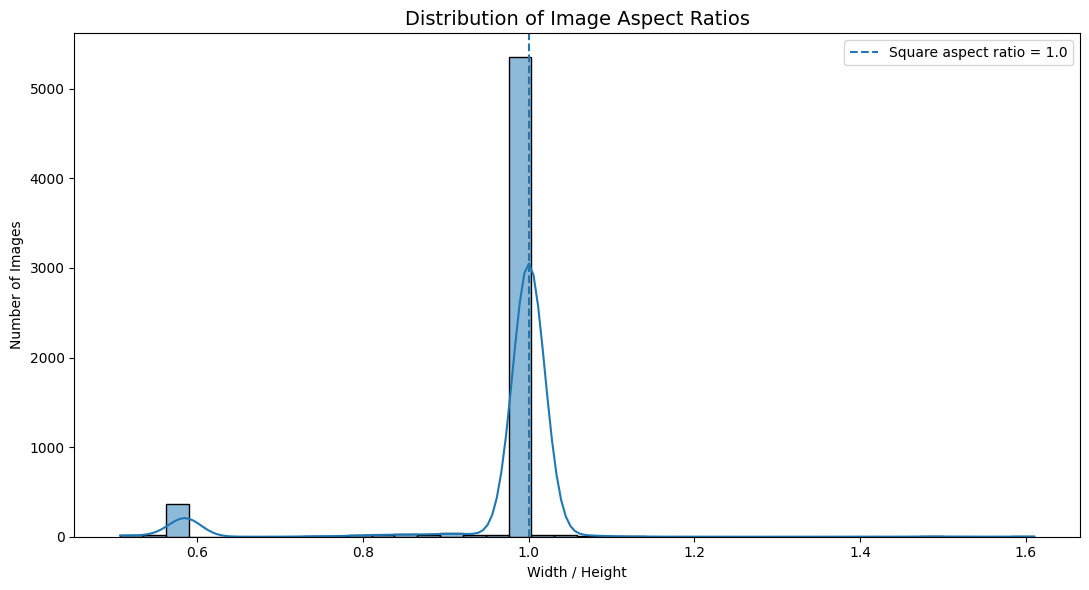

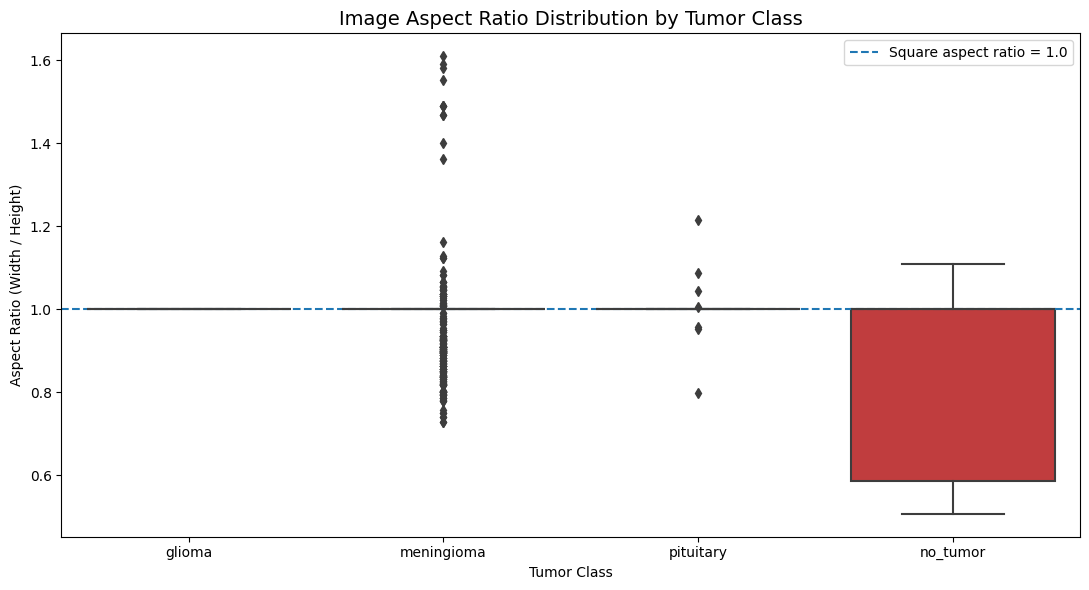

C:\Users\prabh\AppData\Local\Temp\ipykernel_7676\2953075195.py:687: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


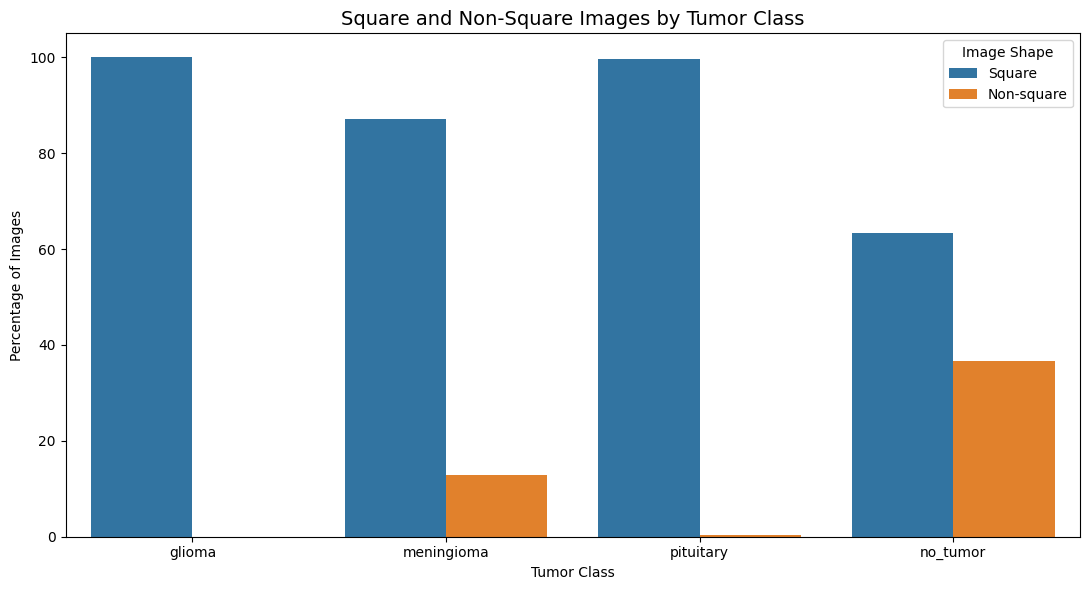

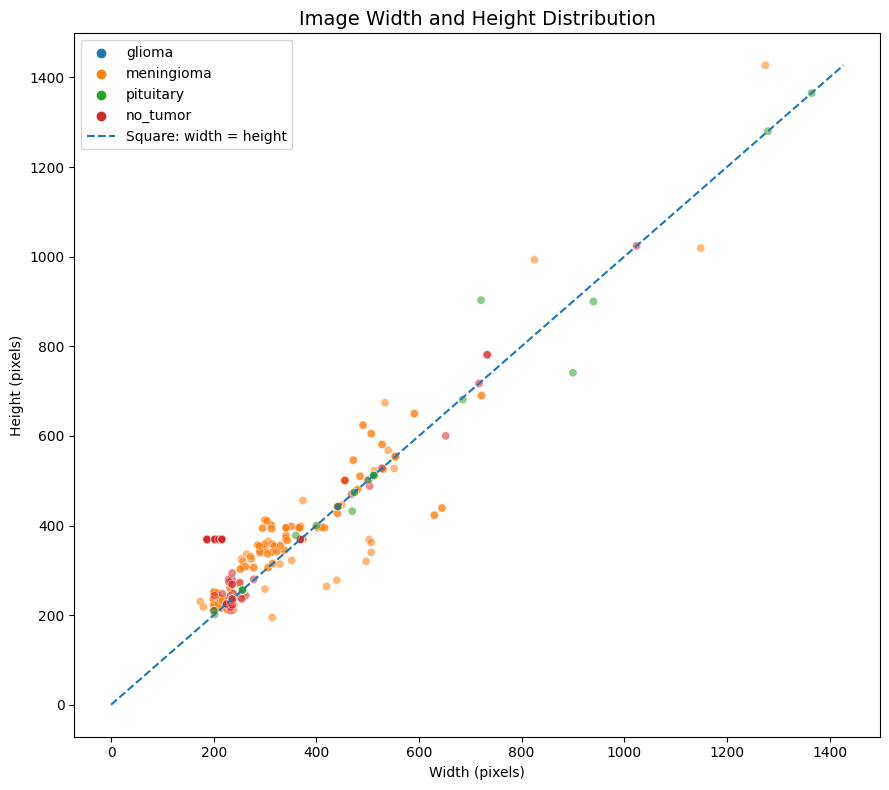


CELL 19 COMPLETE

Key findings:
Unique dimensions: 183
512×512: 4881/6000 (81.35%)
Square: 5341/6000 (89.02%)
Non-square: 659/6000 (10.98%)
Mean aspect ratio: 0.9693
Minimum aspect ratio: 0.5068
Maximum aspect ratio: 1.6103

Reports saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports

Figures saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures

Master thesis report updated:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md


In [24]:
# ============================================================
# CELL 19 — IMAGE DIMENSION & ASPECT-RATIO ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

DATASET_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(
    DATASET_DIR / "manifest.csv"
)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

# ============================================================
# PART A — BASIC DIMENSION SUMMARY
# ============================================================

print("=" * 75)
print("PART A — IMAGE DIMENSION ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# DIMENSION TABLE
# ------------------------------------------------------------

dimension_table = (
    classification[
        [
            "filename",
            "tumor_label",
            "split",
            "plane_label",
            "width",
            "height"
        ]
    ]
    .copy()
)

dimension_table["aspect_ratio"] = (
    dimension_table["width"] /
    dimension_table["height"]
)

dimension_table["is_square"] = (
    dimension_table["width"] ==
    dimension_table["height"]
)

dimension_table["is_512x512"] = (
    (dimension_table["width"] == 512) &
    (dimension_table["height"] == 512)
)

dimension_table["aspect_ratio_deviation"] = (
    np.abs(
        dimension_table["aspect_ratio"] - 1.0
    )
)

# ------------------------------------------------------------
# BASIC STATISTICS
# ------------------------------------------------------------

total_images = len(
    dimension_table
)

unique_dimensions = (
    dimension_table[
        ["width", "height"]
    ]
    .drop_duplicates()
    .shape[0]
)

square_count = (
    dimension_table["is_square"]
    .sum()
)

non_square_count = (
    total_images -
    square_count
)

standard_512_count = (
    dimension_table["is_512x512"]
    .sum()
)

non_512_count = (
    total_images -
    standard_512_count
)

print(
    f"\nTotal classification images: {total_images}"
)

print(
    f"Unique width × height combinations: "
    f"{unique_dimensions}"
)

print(
    f"Square images: "
    f"{square_count} "
    f"({square_count / total_images * 100:.2f}%)"
)

print(
    f"Non-square images: "
    f"{non_square_count} "
    f"({non_square_count / total_images * 100:.2f}%)"
)

print(
    f"512 × 512 images: "
    f"{standard_512_count} "
    f"({standard_512_count / total_images * 100:.2f}%)"
)

print(
    f"Non-512 × 512 images: "
    f"{non_512_count} "
    f"({non_512_count / total_images * 100:.2f}%)"
)

# ============================================================
# PART B — TOP IMAGE DIMENSIONS
# ============================================================

print("\n" + "=" * 75)
print("PART B — MOST COMMON IMAGE DIMENSIONS")
print("=" * 75)

dimension_frequency = (
    dimension_table
    .groupby(
        ["width", "height"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

dimension_frequency["percentage"] = (
    dimension_frequency["count"] /
    total_images *
    100
).round(2)

print(
    "\nTop 20 dimension combinations:"
)

display(
    dimension_frequency.head(20)
)

dimension_frequency.to_csv(
    REPORTS_DIR /
    "image_dimension_frequency.csv",
    index=False
)

# ============================================================
# PART C — DIMENSION DISTRIBUTION BY CLASS
# ============================================================

print("\n" + "=" * 75)
print("PART C — DIMENSION CHARACTERISTICS BY CLASS")
print("=" * 75)

dimension_by_class = (
    dimension_table
    .groupby("tumor_label")
    .agg(
        images=("filename", "count"),
        mean_width=("width", "mean"),
        median_width=("width", "median"),
        minimum_width=("width", "min"),
        maximum_width=("width", "max"),
        mean_height=("height", "mean"),
        median_height=("height", "median"),
        minimum_height=("height", "min"),
        maximum_height=("height", "max"),
        square_images=("is_square", "sum"),
        non_square_images=("is_square", lambda x: (~x).sum()),
        standard_512x512=("is_512x512", "sum")
    )
    .reindex(class_order)
    .reset_index()
)

dimension_by_class[
    [
        "mean_width",
        "median_width",
        "mean_height",
        "median_height"
    ]
] = (
    dimension_by_class[
        [
            "mean_width",
            "median_width",
            "mean_height",
            "median_height"
        ]
    ].round(2)
)

dimension_by_class[
    "square_percentage"
] = (
    dimension_by_class["square_images"] /
    dimension_by_class["images"] *
    100
).round(2)

dimension_by_class[
    "non_square_percentage"
] = (
    dimension_by_class["non_square_images"] /
    dimension_by_class["images"] *
    100
).round(2)

dimension_by_class[
    "standard_512x512_percentage"
] = (
    dimension_by_class["standard_512x512"] /
    dimension_by_class["images"] *
    100
).round(2)

print(
    "\nDimension characteristics by tumor class:"
)

display(
    dimension_by_class
)

dimension_by_class.to_csv(
    REPORTS_DIR /
    "image_dimension_characteristics_by_class.csv",
    index=False
)

# ============================================================
# PART D — ASPECT RATIO SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PART D — ASPECT RATIO ANALYSIS")
print("=" * 75)

aspect_summary = (
    dimension_table["aspect_ratio"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "median",
            "max"
        ]
    )
)

print(
    "\nOverall aspect-ratio statistics:"
)

display(
    aspect_summary
)

# ------------------------------------------------------------
# ASPECT RATIO BY CLASS
# ------------------------------------------------------------

aspect_by_class = (
    dimension_table
    .groupby("tumor_label")["aspect_ratio"]
    .agg(
        images="count",
        mean="mean",
        standard_deviation="std",
        minimum="min",
        median="median",
        maximum="max"
    )
    .reindex(class_order)
    .reset_index()
)

aspect_by_class[
    [
        "mean",
        "standard_deviation",
        "minimum",
        "median",
        "maximum"
    ]
] = (
    aspect_by_class[
        [
            "mean",
            "standard_deviation",
            "minimum",
            "median",
            "maximum"
        ]
    ].round(4)
)

print(
    "\nAspect ratio by class:"
)

display(
    aspect_by_class
)

aspect_by_class.to_csv(
    REPORTS_DIR /
    "aspect_ratio_by_class_detailed.csv",
    index=False
)

# ============================================================
# PART E — EXTREME ASPECT RATIOS
# ============================================================

print("\n" + "=" * 75)
print("PART E — EXTREME ASPECT RATIOS")
print("=" * 75)

# Most horizontally stretched images
widest_images = (
    dimension_table
    .sort_values(
        "aspect_ratio",
        ascending=False
    )
    .head(10)
)

print(
    "\n10 widest images:"
)

display(
    widest_images[
        [
            "filename",
            "tumor_label",
            "split",
            "plane_label",
            "width",
            "height",
            "aspect_ratio"
        ]
    ]
)

# Most vertically stretched images
tallest_images = (
    dimension_table
    .sort_values(
        "aspect_ratio",
        ascending=True
    )
    .head(10)
)

print(
    "\n10 tallest images:"
)

display(
    tallest_images[
        [
            "filename",
            "tumor_label",
            "split",
            "plane_label",
            "width",
            "height",
            "aspect_ratio"
        ]
    ]
)

widest_images[
    [
        "filename",
        "tumor_label",
        "split",
        "plane_label",
        "width",
        "height",
        "aspect_ratio"
    ]
].to_csv(
    REPORTS_DIR /
    "widest_images_by_aspect_ratio.csv",
    index=False
)

tallest_images[
    [
        "filename",
        "tumor_label",
        "split",
        "plane_label",
        "width",
        "height",
        "aspect_ratio"
    ]
].to_csv(
    REPORTS_DIR /
    "tallest_images_by_aspect_ratio.csv",
    index=False
)

# ============================================================
# PART F — ASPECT RATIO THRESHOLDS
# ============================================================

print("\n" + "=" * 75)
print("PART F — ASPECT RATIO DEVIATION")
print("=" * 75)

# These thresholds describe how far an image departs
# from a square image.

thresholds = {
    "within_5_percent": 0.05,
    "within_10_percent": 0.10,
    "within_20_percent": 0.20,
    "within_30_percent": 0.30,
    "more_than_30_percent": 0.30
}

aspect_deviation = (
    dimension_table["aspect_ratio_deviation"]
)

within_5 = (
    aspect_deviation <= 0.05
).sum()

within_10 = (
    aspect_deviation <= 0.10
).sum()

within_20 = (
    aspect_deviation <= 0.20
).sum()

within_30 = (
    aspect_deviation <= 0.30
).sum()

more_than_30 = (
    aspect_deviation > 0.30
).sum()

aspect_threshold_summary = pd.DataFrame({

    "criterion": [
        "Aspect ratio within ±5% of square",
        "Aspect ratio within ±10% of square",
        "Aspect ratio within ±20% of square",
        "Aspect ratio within ±30% of square",
        "Aspect ratio >30% away from square"
    ],

    "count": [
        within_5,
        within_10,
        within_20,
        within_30,
        more_than_30
    ]
})

aspect_threshold_summary[
    "percentage"
] = (
    aspect_threshold_summary["count"] /
    total_images *
    100
).round(2)

print(
    "\nAspect-ratio deviation summary:"
)

display(
    aspect_threshold_summary
)

aspect_threshold_summary.to_csv(
    REPORTS_DIR /
    "aspect_ratio_deviation_thresholds.csv",
    index=False
)

# ============================================================
# PART G — FIGURE 1: ASPECT RATIO DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(11, 6)
)

sns.histplot(
    dimension_table["aspect_ratio"],
    bins=40,
    kde=True
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Square aspect ratio = 1.0"
)

plt.title(
    "Distribution of Image Aspect Ratios",
    fontsize=14
)

plt.xlabel(
    "Width / Height"
)

plt.ylabel(
    "Number of Images"
)

plt.legend()

plt.tight_layout()

aspect_histogram = (
    FIGURES_DIR /
    "19_image_aspect_ratio_distribution.png"
)

plt.savefig(
    aspect_histogram,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART H — FIGURE 2: ASPECT RATIO BY CLASS
# ============================================================

plt.figure(
    figsize=(11, 6)
)

sns.boxplot(
    data=dimension_table,
    x="tumor_label",
    y="aspect_ratio",
    order=class_order
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Square aspect ratio = 1.0"
)

plt.title(
    "Image Aspect Ratio Distribution by Tumor Class",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Aspect Ratio (Width / Height)"
)

plt.legend()

plt.tight_layout()

aspect_class_figure = (
    FIGURES_DIR /
    "20_image_aspect_ratio_by_class.png"
)

plt.savefig(
    aspect_class_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART I — FIGURE 3: SQUARE VS NON-SQUARE
# ============================================================

square_class = (
    dimension_table
    .groupby(
        ["tumor_label", "is_square"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

square_class["shape"] = (
    square_class["is_square"]
    .map({
        True: "Square",
        False: "Non-square"
    })
)

square_class_percentage = (
    square_class
    .groupby("tumor_label", group_keys=False)
    .apply(
        lambda x: x.assign(
            percentage=(
                x["count"] /
                x["count"].sum() *
                100
            )
        )
    )
    .reset_index(drop=True)
)

square_class_percentage[
    "percentage"
] = (
    square_class_percentage[
        "percentage"
    ].round(2)
)

plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=square_class_percentage,
    x="tumor_label",
    y="percentage",
    hue="shape",
    order=class_order,
    errorbar=None
)

plt.title(
    "Square and Non-Square Images by Tumor Class",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Percentage of Images"
)

plt.ylim(
    0,
    105
)

plt.legend(
    title="Image Shape"
)

plt.tight_layout()

square_class_figure = (
    FIGURES_DIR /
    "21_square_vs_non_square_by_class.png"
)

plt.savefig(
    square_class_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

square_class_percentage.to_csv(
    REPORTS_DIR /
    "square_vs_non_square_percentage_by_class.csv",
    index=False
)

# ============================================================
# PART J — FIGURE 4: WIDTH VS HEIGHT
# ============================================================

plt.figure(
    figsize=(9, 8)
)

sns.scatterplot(
    data=dimension_table,
    x="width",
    y="height",
    hue="tumor_label",
    hue_order=class_order,
    alpha=0.55,
    s=35
)

max_dimension = max(
    dimension_table["width"].max(),
    dimension_table["height"].max()
)

plt.plot(
    [0, max_dimension],
    [0, max_dimension],
    linestyle="--",
    linewidth=1.5,
    label="Square: width = height"
)

plt.title(
    "Image Width and Height Distribution",
    fontsize=14
)

plt.xlabel(
    "Width (pixels)"
)

plt.ylabel(
    "Height (pixels)"
)

plt.legend()

plt.tight_layout()

dimension_scatter = (
    FIGURES_DIR /
    "22_image_width_height_distribution.png"
)

plt.savefig(
    dimension_scatter,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART K — UPDATE MASTER THESIS REPORT
# ============================================================

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 16. Image Dimension and Aspect-Ratio Analysis\n\n"
    )

    f.write(
        f"The classification dataset contained "
        f"**{unique_dimensions} unique width × height "
        f"combinations** across {total_images} images. "
        f"Of these, **{standard_512_count} images "
        f"({standard_512_count / total_images * 100:.2f}%)** "
        f"were 512 × 512 pixels, while "
        f"**{non_512_count} images "
        f"({non_512_count / total_images * 100:.2f}%)** "
        f"had other dimensions.\n\n"
    )

    f.write(
        f"Overall, **{square_count} images "
        f"({square_count / total_images * 100:.2f}%)** "
        f"were square and **{non_square_count} images "
        f"({non_square_count / total_images * 100:.2f}%)** "
        f"were non-square.\n\n"
    )

    f.write(
        "The aspect-ratio distribution was examined because "
        "naive resizing of non-square MRI images to a fixed "
        "square CNN input can potentially introduce geometric "
        "distortion. The analysis therefore provides an "
        "empirical basis for selecting an appropriate "
        "aspect-ratio-preserving preprocessing strategy.\n\n"
    )

    f.write(
        "### Aspect-Ratio Statistics\n\n"
    )

    f.write(
        aspect_by_class.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        "### Aspect-Ratio Deviation\n\n"
    )

    f.write(
        aspect_threshold_summary.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        "### Dimension Analysis Figures\n\n"
    )

    f.write(
        "- `outputs/figures/19_image_aspect_ratio_distribution.png`\n"
    )

    f.write(
        "- `outputs/figures/20_image_aspect_ratio_by_class.png`\n"
    )

    f.write(
        "- `outputs/figures/21_square_vs_non_square_by_class.png`\n"
    )

    f.write(
        "- `outputs/figures/22_image_width_height_distribution.png`\n"
    )

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 19 COMPLETE")
print("=" * 75)

print("\nKey findings:")

print(
    f"Unique dimensions: {unique_dimensions}"
)

print(
    f"512×512: "
    f"{standard_512_count}/{total_images} "
    f"({standard_512_count / total_images * 100:.2f}%)"
)

print(
    f"Square: "
    f"{square_count}/{total_images} "
    f"({square_count / total_images * 100:.2f}%)"
)

print(
    f"Non-square: "
    f"{non_square_count}/{total_images} "
    f"({non_square_count / total_images * 100:.2f}%)"
)

print(
    f"Mean aspect ratio: "
    f"{dimension_table['aspect_ratio'].mean():.4f}"
)

print(
    f"Minimum aspect ratio: "
    f"{dimension_table['aspect_ratio'].min():.4f}"
)

print(
    f"Maximum aspect ratio: "
    f"{dimension_table['aspect_ratio'].max():.4f}"
)

print("\nReports saved to:")

print(
    REPORTS_DIR
)

print("\nFigures saved to:")

print(
    FIGURES_DIR
)

print("\nMaster thesis report updated:")

print(
    thesis_record
)

CELL 20 — CROSS-FEATURE CONFOUNDING ANALYSIS

Classification images available: 6000

PART A — IMAGE MODE × CLASS × SPLIT
Processed 1000/6000 images...
Processed 2000/6000 images...
Processed 3000/6000 images...
Processed 4000/6000 images...
Processed 5000/6000 images...
Processed 6000/6000 images...

Successfully analyzed: 6000 images

Image mode counts by class and split:


image_mode         Grayscale   RGB
tumor_label split                 
glioma      train       1038   109
            test         189    65
meningioma  train        549   780
            test         160   146
pituitary   train        697   760
            test         233    67
no_tumor    train          0  1067
            test           0   140


Image mode percentages within each class × split:


image_mode         Grayscale     RGB
tumor_label split                   
glioma      train      90.50    9.50
            test       74.41   25.59
meningioma  train      41.31   58.69
            test       52.29   47.71
pituitary   train      47.84   52.16
            test       77.67   22.33
no_tumor    train       0.00  100.00
            test        0.00  100.00


PART B — IMAGE MODE DISTRIBUTION BY SPLIT

Counts:


image_mode,Grayscale,RGB
split,,
train,2284,2716
test,582,418



Percentages:


image_mode,Grayscale,RGB
split,,
train,45.68,54.32
test,58.20,41.80


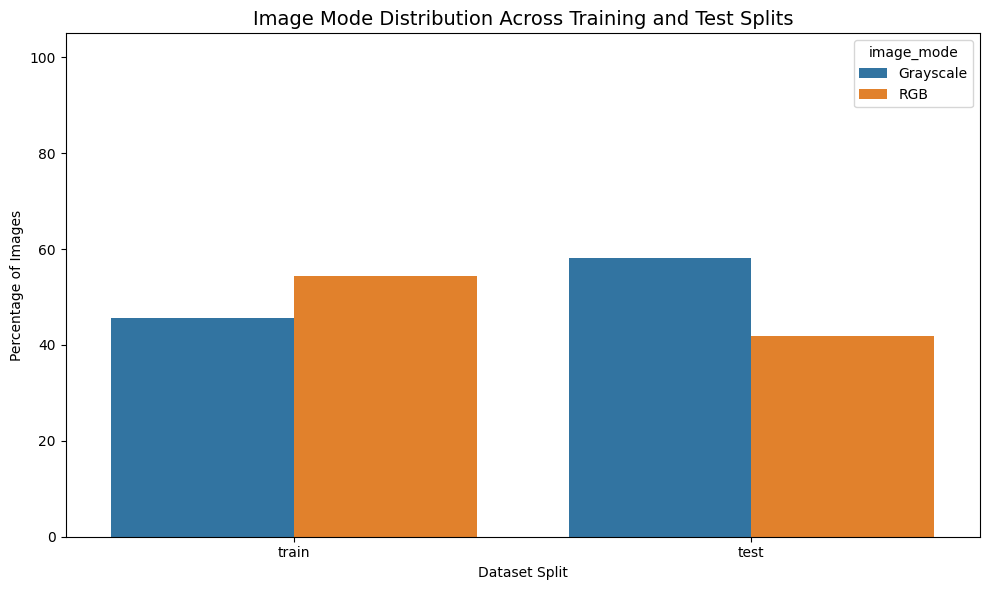


PART D — ASPECT RATIO × IMAGE MODE

Geometry characteristics by image mode:


,image_mode,images,mean_aspect_ratio,median_aspect_ratio,std_aspect_ratio,minimum_aspect_ratio,maximum_aspect_ratio,mean_width,mean_height
0,Grayscale,2866,1.0000,1.0,0.000,1.0000,1.0000,510.6602,510.6602
1,RGB,3134,0.9412,1.0,0.147,0.5068,1.6103,437.7361,459.3874


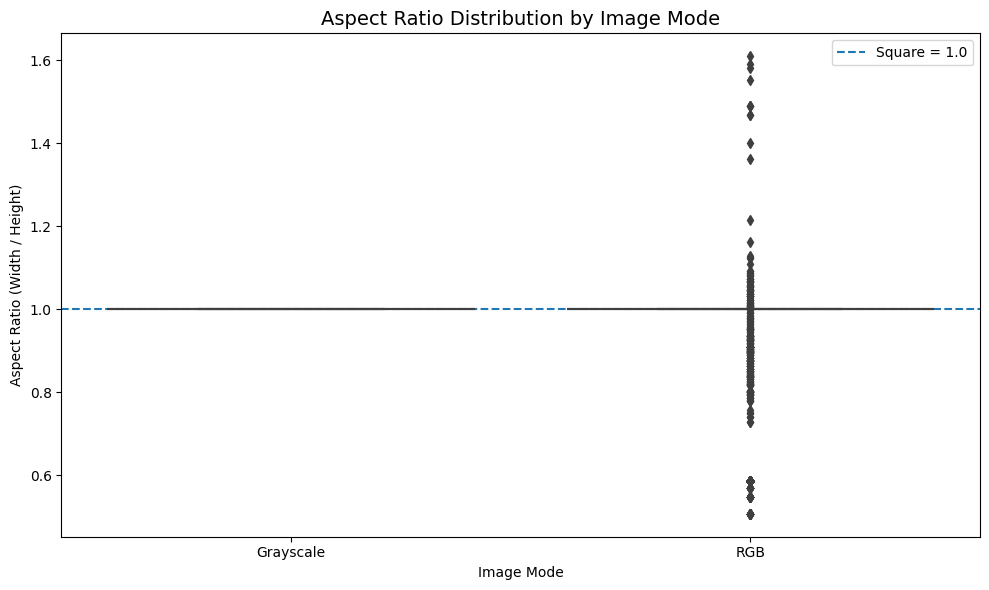


Square/non-square distribution by image mode:


,image_mode,total_images,square_images,non_square_images,square_percentage,non_square_percentage
0,Grayscale,2866,2866,0,100.00,0.00
1,RGB,3134,2475,659,78.97,21.03



PART G — PIXEL INTENSITY × IMAGE MODE
glioma: 200 images sampled
meningioma: 200 images sampled
pituitary: 200 images sampled
no_tumor: 200 images sampled

Successfully analyzed 800 sampled images.

Intensity characteristics by image mode:


,image_mode,images,mean_intensity,median_intensity,std_of_mean_intensity,mean_pixel_std,mean_nonzero_percentage
0,Grayscale,378,39.438,39.425,10.71,41.158,84.798
1,RGB,422,50.466,48.350,15.69,48.744,82.883



Intensity by tumor class and image mode:


,tumor_label,image_mode,images,mean_intensity,median_intensity,standard_deviation,mean_pixel_std,mean_nonzero_percentage
0,glioma,Grayscale,181,32.901,32.498,8.325,38.771,79.527
1,glioma,RGB,19,34.846,32.529,8.116,39.472,77.562
2,meningioma,Grayscale,86,40.693,40.330,8.494,45.305,86.695
3,meningioma,RGB,114,52.448,45.033,22.102,50.290,88.528
4,no_tumor,RGB,200,51.492,50.497,13.376,51.889,76.133
5,pituitary,Grayscale,111,49.126,49.908,7.595,41.838,91.924
6,pituitary,RGB,89,48.955,49.072,8.359,41.678,91.958


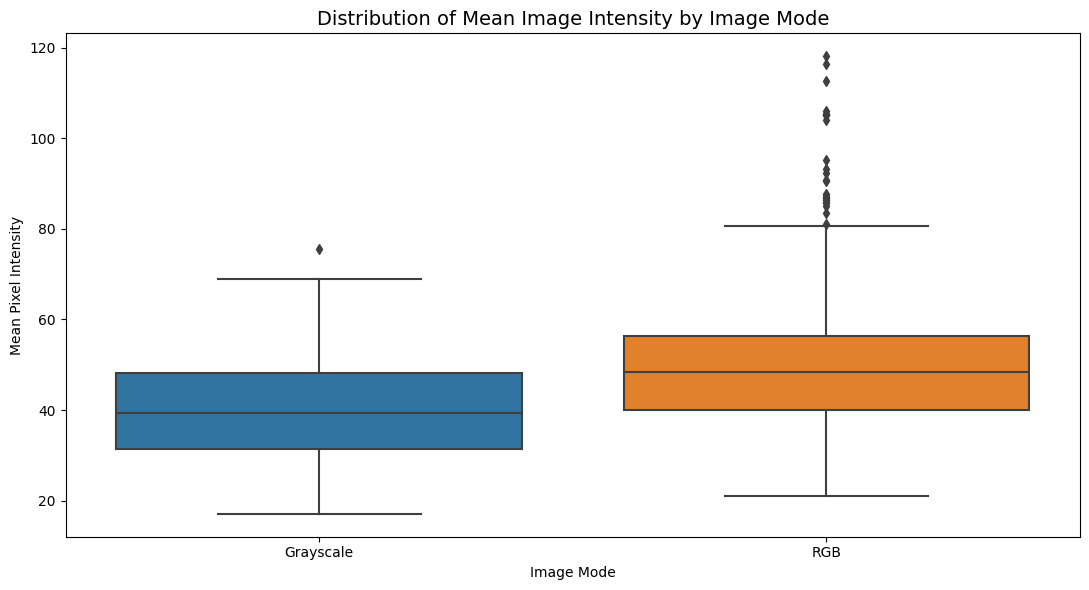

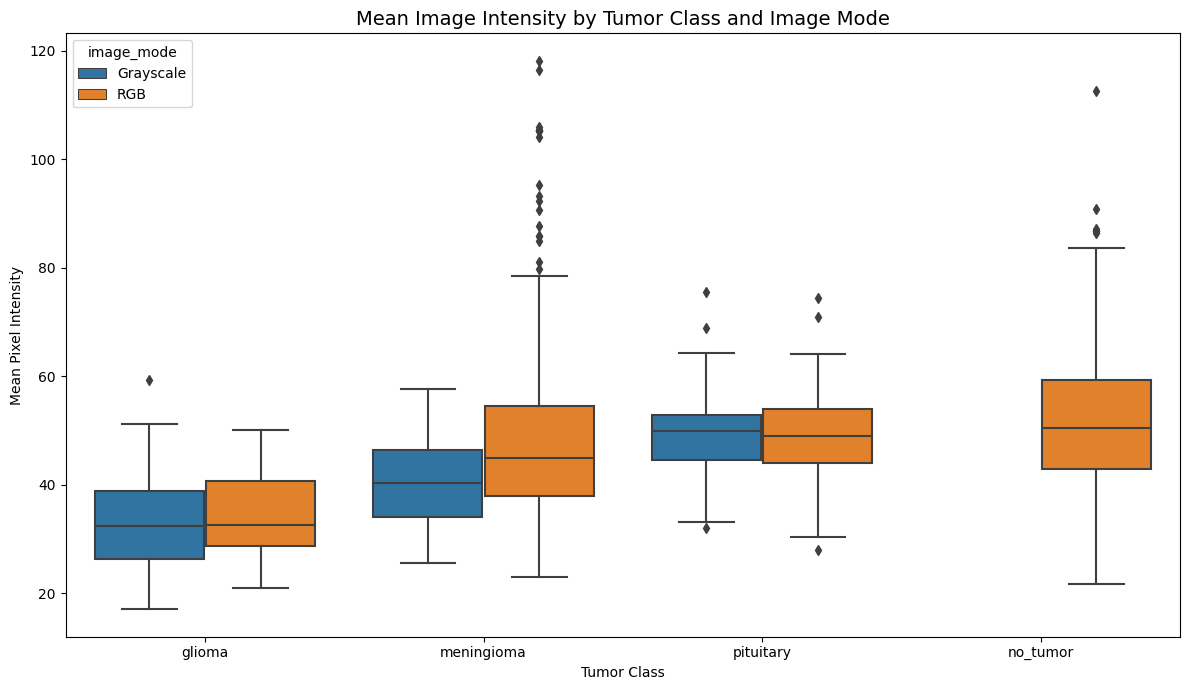


PART K — NUMERICAL FEATURE CORRELATIONS

Spearman correlation matrix:


,mean_intensity,median_intensity,pixel_std,nonzero_percentage,width,height,aspect_ratio
mean_intensity,1.0000,0.8554,0.5577,0.5662,-0.2616,-0.2406,-0.2018
median_intensity,0.8554,1.0000,0.1937,0.6530,-0.1815,-0.1654,-0.1354
pixel_std,0.5577,0.1937,1.0000,0.0163,-0.3673,-0.3440,-0.2647
nonzero_percentage,0.5662,0.6530,0.0163,1.0000,0.2059,0.2035,0.1036
width,-0.2616,-0.1815,-0.3673,0.2059,1.0000,0.9729,0.6147
height,-0.2406,-0.1654,-0.3440,0.2035,0.9729,1.0000,0.4971
aspect_ratio,-0.2018,-0.1354,-0.2647,0.1036,0.6147,0.4971,1.0000


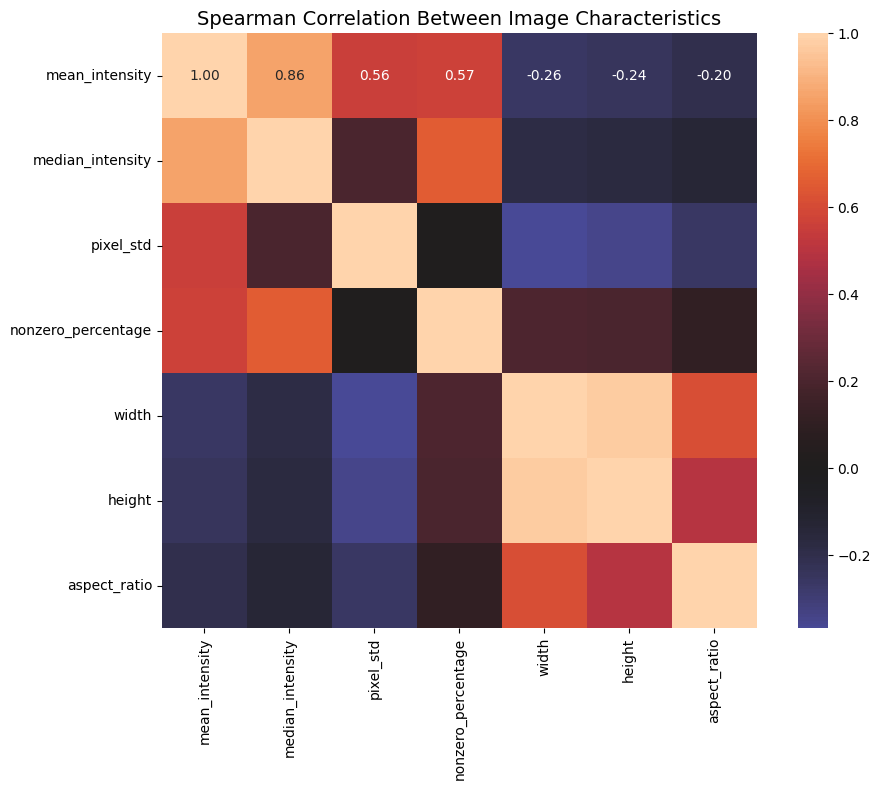


PART L — CLASS-LEVEL CONFOUNDING SUMMARY

Class-level confounding summary:


,tumor_label,images,grayscale_images,rgb_images,square_images,mean_aspect_ratio,median_aspect_ratio,mean_width,mean_height,grayscale_percentage,rgb_percentage,square_percentage
0,glioma,1401,1227,174,1401,1.000,1.0,512.000,512.000,87.58,12.42,100.00
1,meningioma,1635,709,926,1426,0.992,1.0,484.122,486.900,43.36,56.64,87.22
2,pituitary,1757,930,827,1750,1.000,1.0,508.908,508.890,52.93,47.07,99.60
3,no_tumor,1207,0,1207,764,0.858,1.0,358.254,410.737,0.00,100.00,63.30



PART M — AUTOMATED DATA ANALYSIS INTERPRETATION


ValueError: cannot insert tumor_label, already exists

In [25]:
# ============================================================
# CELL 20 — CROSS-FEATURE CONFOUNDING ANALYSIS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

DATASET_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\brisc2025"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(
    DATASET_DIR / "manifest.csv"
)

classification = manifest[
    manifest["task"] == "classification"
].copy()

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

mode_order = [
    "Grayscale",
    "RGB"
]

split_order = [
    "train",
    "test"
]

plane_order = [
    "axial",
    "coronal",
    "sagittal"
]

print("=" * 75)
print("CELL 20 — CROSS-FEATURE CONFOUNDING ANALYSIS")
print("=" * 75)

print(
    f"\nClassification images available: "
    f"{len(classification)}"
)

# ============================================================
# PART A — IMAGE MODE × CLASS × SPLIT
# ============================================================

print("\n" + "=" * 75)
print("PART A — IMAGE MODE × CLASS × SPLIT")
print("=" * 75)

# ------------------------------------------------------------
# Read actual image modes
# ------------------------------------------------------------

mode_records = []

for i, row in enumerate(
    classification.itertuples(index=False),
    start=1
):

    image_path = DATASET_DIR / row.relative_path

    try:
        with Image.open(image_path) as img:

            if img.mode == "RGB":
                image_mode = "RGB"

            elif img.mode == "L":
                image_mode = "Grayscale"

            else:
                image_mode = img.mode

        mode_records.append({
            "filename": row.filename,
            "tumor_label": row.tumor_label,
            "split": row.split,
            "plane_label": row.plane_label,
            "image_mode": image_mode
        })

    except Exception:
        mode_records.append({
            "filename": row.filename,
            "tumor_label": row.tumor_label,
            "split": row.split,
            "plane_label": row.plane_label,
            "image_mode": "READ_ERROR"
        })

    if i % 1000 == 0:
        print(
            f"Processed {i}/{len(classification)} images..."
        )

mode_df = pd.DataFrame(
    mode_records
)

mode_df = mode_df[
    mode_df["image_mode"] != "READ_ERROR"
].copy()

print(
    f"\nSuccessfully analyzed: "
    f"{len(mode_df)} images"
)

# ------------------------------------------------------------
# CLASS × MODE × SPLIT COUNTS
# ------------------------------------------------------------

mode_class_split_counts = pd.crosstab(
    [
        mode_df["tumor_label"],
        mode_df["split"]
    ],
    mode_df["image_mode"]
)

mode_class_split_counts = (
    mode_class_split_counts
    .reindex(
        pd.MultiIndex.from_product(
            [
                class_order,
                split_order
            ],
            names=[
                "tumor_label",
                "split"
            ]
        ),
        fill_value=0
    )
)

print(
    "\nImage mode counts by class and split:"
)

display(
    mode_class_split_counts
)

mode_class_split_counts.to_csv(
    REPORTS_DIR /
    "image_mode_by_class_and_split_counts.csv"
)

# ------------------------------------------------------------
# PERCENTAGE WITHIN EACH CLASS × SPLIT
# ------------------------------------------------------------

mode_class_split_percentage = (
    mode_class_split_counts
    .div(
        mode_class_split_counts.sum(axis=1),
        axis=0
    )
    * 100
)

mode_class_split_percentage = (
    mode_class_split_percentage
    .round(2)
)

print(
    "\nImage mode percentages within each class × split:"
)

display(
    mode_class_split_percentage
)

mode_class_split_percentage.to_csv(
    REPORTS_DIR /
    "image_mode_by_class_and_split_percentage.csv"
)

# ============================================================
# PART B — MODE DISTRIBUTION BY TRAIN / TEST
# ============================================================

print("\n" + "=" * 75)
print("PART B — IMAGE MODE DISTRIBUTION BY SPLIT")
print("=" * 75)

mode_split_counts = pd.crosstab(
    mode_df["split"],
    mode_df["image_mode"]
).reindex(
    split_order,
    fill_value=0
)

mode_split_percentage = (
    mode_split_counts
    .div(
        mode_split_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

print("\nCounts:")
display(mode_split_counts)

print("\nPercentages:")
display(mode_split_percentage)

mode_split_counts.to_csv(
    REPORTS_DIR /
    "image_mode_by_split_counts.csv"
)

mode_split_percentage.to_csv(
    REPORTS_DIR /
    "image_mode_by_split_percentage.csv"
)

# ============================================================
# PART C — MODE DISTRIBUTION FIGURE
# ============================================================

mode_split_plot = (
    mode_split_percentage
    .reset_index()
    .melt(
        id_vars="split",
        var_name="image_mode",
        value_name="percentage"
    )
)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=mode_split_plot,
    x="split",
    y="percentage",
    hue="image_mode",
    order=split_order,
    hue_order=mode_order,
    errorbar=None
)

plt.title(
    "Image Mode Distribution Across Training and Test Splits",
    fontsize=14
)

plt.xlabel(
    "Dataset Split"
)

plt.ylabel(
    "Percentage of Images"
)

plt.ylim(
    0,
    105
)

plt.tight_layout()

mode_split_figure = (
    FIGURES_DIR /
    "23_image_mode_by_split.png"
)

plt.savefig(
    mode_split_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART D — ASPECT RATIO × IMAGE MODE
# ============================================================

print("\n" + "=" * 75)
print("PART D — ASPECT RATIO × IMAGE MODE")
print("=" * 75)

# Merge image mode with dimensions

geometry_df = classification[
    [
        "filename",
        "tumor_label",
        "split",
        "plane_label",
        "width",
        "height"
    ]
].copy()

geometry_df["aspect_ratio"] = (
    geometry_df["width"] /
    geometry_df["height"]
)

geometry_df = geometry_df.merge(
    mode_df[
        [
            "filename",
            "image_mode"
        ]
    ],
    on="filename",
    how="left"
)

geometry_mode_summary = (
    geometry_df
    .groupby("image_mode")
    .agg(
        images=("filename", "count"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
        median_aspect_ratio=("aspect_ratio", "median"),
        std_aspect_ratio=("aspect_ratio", "std"),
        minimum_aspect_ratio=("aspect_ratio", "min"),
        maximum_aspect_ratio=("aspect_ratio", "max"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean")
    )
    .reset_index()
)

geometry_mode_summary[
    [
        "mean_aspect_ratio",
        "median_aspect_ratio",
        "std_aspect_ratio",
        "minimum_aspect_ratio",
        "maximum_aspect_ratio",
        "mean_width",
        "mean_height"
    ]
] = (
    geometry_mode_summary[
        [
            "mean_aspect_ratio",
            "median_aspect_ratio",
            "std_aspect_ratio",
            "minimum_aspect_ratio",
            "maximum_aspect_ratio",
            "mean_width",
            "mean_height"
        ]
    ].round(4)
)

print(
    "\nGeometry characteristics by image mode:"
)

display(
    geometry_mode_summary
)

geometry_mode_summary.to_csv(
    REPORTS_DIR /
    "geometry_by_image_mode.csv",
    index=False
)

# ============================================================
# PART E — ASPECT RATIO BY IMAGE MODE FIGURE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=geometry_df,
    x="image_mode",
    y="aspect_ratio",
    order=mode_order
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Square = 1.0"
)

plt.title(
    "Aspect Ratio Distribution by Image Mode",
    fontsize=14
)

plt.xlabel(
    "Image Mode"
)

plt.ylabel(
    "Aspect Ratio (Width / Height)"
)

plt.legend()

plt.tight_layout()

geometry_mode_figure = (
    FIGURES_DIR /
    "24_aspect_ratio_by_image_mode.png"
)

plt.savefig(
    geometry_mode_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART F — NON-SQUARE RATE BY IMAGE MODE
# ============================================================

geometry_df["is_square"] = (
    geometry_df["width"] ==
    geometry_df["height"]
)

square_by_mode = (
    geometry_df
    .groupby(
        "image_mode"
    )
    .agg(
        total_images=("filename", "count"),
        square_images=("is_square", "sum")
    )
)

square_by_mode[
    "non_square_images"
] = (
    square_by_mode["total_images"] -
    square_by_mode["square_images"]
)

square_by_mode[
    "square_percentage"
] = (
    square_by_mode["square_images"] /
    square_by_mode["total_images"] *
    100
).round(2)

square_by_mode[
    "non_square_percentage"
] = (
    square_by_mode["non_square_images"] /
    square_by_mode["total_images"] *
    100
).round(2)

square_by_mode = (
    square_by_mode
    .reset_index()
)

print(
    "\nSquare/non-square distribution by image mode:"
)

display(
    square_by_mode
)

square_by_mode.to_csv(
    REPORTS_DIR /
    "square_non_square_by_image_mode.csv",
    index=False
)

# ============================================================
# PART G — INTENSITY ANALYSIS BY IMAGE MODE
# ============================================================

print("\n" + "=" * 75)
print("PART G — PIXEL INTENSITY × IMAGE MODE")
print("=" * 75)

# ------------------------------------------------------------
# Reproducible sampling
# ------------------------------------------------------------

RANDOM_STATE = 42
SAMPLES_PER_CLASS = 200

rng = np.random.default_rng(
    RANDOM_STATE
)

intensity_source = classification.copy()

sample_records = []

for tumor_class in class_order:

    class_rows = intensity_source[
        intensity_source["tumor_label"] ==
        tumor_class
    ].copy()

    sample_size = min(
        SAMPLES_PER_CLASS,
        len(class_rows)
    )

    sampled_indices = rng.choice(
        class_rows.index.to_numpy(),
        size=sample_size,
        replace=False
    )

    sampled_rows = class_rows.loc[
        sampled_indices
    ]

    print(
        f"{tumor_class}: "
        f"{len(sampled_rows)} images sampled"
    )

    for row in sampled_rows.itertuples(
        index=False
    ):

        image_path = DATASET_DIR / row.relative_path

        try:

            with Image.open(image_path) as img:

                gray = img.convert("L")

                arr = np.asarray(
                    gray,
                    dtype=np.float32
                )

                mean_intensity = float(
                    arr.mean()
                )

                median_intensity = float(
                    np.median(arr)
                )

                pixel_std = float(
                    arr.std()
                )

                nonzero_percentage = float(
                    np.count_nonzero(arr) /
                    arr.size *
                    100
                )

                sample_records.append({

                    "filename": row.filename,

                    "tumor_label":
                        row.tumor_label,

                    "split":
                        row.split,

                    "plane_label":
                        row.plane_label,

                    "image_mode":
                        None,

                    "mean_intensity":
                        mean_intensity,

                    "median_intensity":
                        median_intensity,

                    "pixel_std":
                        pixel_std,

                    "nonzero_percentage":
                        nonzero_percentage
                })

        except Exception as e:

            print(
                f"Warning: could not process "
                f"{row.filename}: {e}"
            )

intensity_df = pd.DataFrame(
    sample_records
)

# Merge actual image mode

intensity_df = intensity_df.drop(
    columns=["image_mode"]
)

intensity_df = intensity_df.merge(
    mode_df[
        [
            "filename",
            "image_mode"
        ]
    ],
    on="filename",
    how="left"
)

print(
    f"\nSuccessfully analyzed "
    f"{len(intensity_df)} sampled images."
)

# ------------------------------------------------------------
# INTENSITY BY MODE
# ------------------------------------------------------------

intensity_mode_summary = (
    intensity_df
    .groupby("image_mode")
    .agg(
        images=("filename", "count"),
        mean_intensity=("mean_intensity", "mean"),
        median_intensity=("mean_intensity", "median"),
        std_of_mean_intensity=(
            "mean_intensity",
            "std"
        ),
        mean_pixel_std=("pixel_std", "mean"),
        mean_nonzero_percentage=(
            "nonzero_percentage",
            "mean"
        )
    )
    .reindex(mode_order)
    .reset_index()
)

intensity_mode_summary[
    [
        "mean_intensity",
        "median_intensity",
        "std_of_mean_intensity",
        "mean_pixel_std",
        "mean_nonzero_percentage"
    ]
] = (
    intensity_mode_summary[
        [
            "mean_intensity",
            "median_intensity",
            "std_of_mean_intensity",
            "mean_pixel_std",
            "mean_nonzero_percentage"
        ]
    ].round(3)
)

print(
    "\nIntensity characteristics by image mode:"
)

display(
    intensity_mode_summary
)

intensity_mode_summary.to_csv(
    REPORTS_DIR /
    "intensity_by_image_mode.csv",
    index=False
)

# ============================================================
# PART H — INTENSITY × CLASS × MODE
# ============================================================

intensity_class_mode = (
    intensity_df
    .groupby(
        [
            "tumor_label",
            "image_mode"
        ]
    )
    .agg(
        images=("filename", "count"),
        mean_intensity=(
            "mean_intensity",
            "mean"
        ),
        median_intensity=(
            "mean_intensity",
            "median"
        ),
        standard_deviation=(
            "mean_intensity",
            "std"
        ),
        mean_pixel_std=(
            "pixel_std",
            "mean"
        ),
        mean_nonzero_percentage=(
            "nonzero_percentage",
            "mean"
        )
    )
    .reset_index()
)

intensity_class_mode[
    [
        "mean_intensity",
        "median_intensity",
        "standard_deviation",
        "mean_pixel_std",
        "mean_nonzero_percentage"
    ]
] = (
    intensity_class_mode[
        [
            "mean_intensity",
            "median_intensity",
            "standard_deviation",
            "mean_pixel_std",
            "mean_nonzero_percentage"
        ]
    ].round(3)
)

print(
    "\nIntensity by tumor class and image mode:"
)

display(
    intensity_class_mode
)

intensity_class_mode.to_csv(
    REPORTS_DIR /
    "intensity_by_class_and_image_mode.csv",
    index=False
)

# ============================================================
# PART I — INTENSITY FIGURE BY IMAGE MODE
# ============================================================

plt.figure(
    figsize=(11, 6)
)

sns.boxplot(
    data=intensity_df,
    x="image_mode",
    y="mean_intensity",
    order=mode_order
)

plt.title(
    "Distribution of Mean Image Intensity by Image Mode",
    fontsize=14
)

plt.xlabel(
    "Image Mode"
)

plt.ylabel(
    "Mean Pixel Intensity"
)

plt.tight_layout()

intensity_mode_figure = (
    FIGURES_DIR /
    "25_mean_intensity_by_image_mode.png"
)

plt.savefig(
    intensity_mode_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART J — INTENSITY × CLASS × MODE FIGURE
# ============================================================

plt.figure(
    figsize=(12, 7)
)

sns.boxplot(
    data=intensity_df,
    x="tumor_label",
    y="mean_intensity",
    hue="image_mode",
    order=class_order,
    hue_order=mode_order
)

plt.title(
    "Mean Image Intensity by Tumor Class and Image Mode",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Mean Pixel Intensity"
)

plt.tight_layout()

intensity_class_mode_figure = (
    FIGURES_DIR /
    "26_mean_intensity_by_class_and_mode.png"
)

plt.savefig(
    intensity_class_mode_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART K — NUMERICAL CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 75)
print("PART K — NUMERICAL FEATURE CORRELATIONS")
print("=" * 75)

correlation_df = intensity_df.merge(
    geometry_df[
        [
            "filename",
            "width",
            "height",
            "aspect_ratio"
        ]
    ],
    on="filename",
    how="left"
)

numeric_columns = [
    "mean_intensity",
    "median_intensity",
    "pixel_std",
    "nonzero_percentage",
    "width",
    "height",
    "aspect_ratio"
]

correlation_matrix = (
    correlation_df[
        numeric_columns
    ]
    .corr(
        method="spearman"
    )
)

print(
    "\nSpearman correlation matrix:"
)

display(
    correlation_matrix.round(4)
)

correlation_matrix.to_csv(
    REPORTS_DIR /
    "numeric_feature_spearman_correlation.csv"
)

# ------------------------------------------------------------
# CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)

plt.title(
    "Spearman Correlation Between Image Characteristics",
    fontsize=14
)

plt.tight_layout()

correlation_figure = (
    FIGURES_DIR /
    "27_numeric_feature_correlation_heatmap.png"
)

plt.savefig(
    correlation_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART L — CLASS-SPECIFIC MODE / GEOMETRY SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PART L — CLASS-LEVEL CONFOUNDING SUMMARY")
print("=" * 75)

class_confounding = (
    geometry_df
    .groupby("tumor_label")
    .agg(
        images=("filename", "count"),

        grayscale_images=(
            "image_mode",
            lambda x:
            (x == "Grayscale").sum()
        ),

        rgb_images=(
            "image_mode",
            lambda x:
            (x == "RGB").sum()
        ),

        square_images=(
            "is_square",
            "sum"
        ),

        mean_aspect_ratio=(
            "aspect_ratio",
            "mean"
        ),

        median_aspect_ratio=(
            "aspect_ratio",
            "median"
        ),

        mean_width=(
            "width",
            "mean"
        ),

        mean_height=(
            "height",
            "mean"
        )
    )
    .reindex(class_order)
    .reset_index()
)

class_confounding[
    "grayscale_percentage"
] = (
    class_confounding["grayscale_images"] /
    class_confounding["images"] *
    100
).round(2)

class_confounding[
    "rgb_percentage"
] = (
    class_confounding["rgb_images"] /
    class_confounding["images"] *
    100
).round(2)

class_confounding[
    "square_percentage"
] = (
    class_confounding["square_images"] /
    class_confounding["images"] *
    100
).round(2)

class_confounding[
    [
        "mean_aspect_ratio",
        "median_aspect_ratio",
        "mean_width",
        "mean_height"
    ]
] = (
    class_confounding[
        [
            "mean_aspect_ratio",
            "median_aspect_ratio",
            "mean_width",
            "mean_height"
        ]
    ].round(3)
)

print(
    "\nClass-level confounding summary:"
)

display(
    class_confounding
)

class_confounding.to_csv(
    REPORTS_DIR /
    "class_level_confounding_summary.csv",
    index=False
)

# ============================================================
# PART M — DATA ANALYSIS INTERPRETATION
# ============================================================

print("\n" + "=" * 75)
print("PART M — AUTOMATED DATA ANALYSIS INTERPRETATION")
print("=" * 75)

# ------------------------------------------------------------
# Identify major mode imbalance
# ------------------------------------------------------------

mode_class_percentage = (
    mode_df
    .groupby(
        [
            "tumor_label",
            "image_mode"
        ]
    )
    .size()
    .groupby(level=0)
    .apply(
        lambda x:
        x / x.sum() * 100
    )
    .reset_index(
        name="percentage"
    )
)

mode_class_pivot = (
    mode_class_percentage
    .pivot(
        index="tumor_label",
        columns="image_mode",
        values="percentage"
    )
    .fillna(0)
)

for mode in mode_order:

    if mode not in mode_class_pivot.columns:
        mode_class_pivot[mode] = 0

mode_class_pivot = (
    mode_class_pivot[
        mode_order
    ]
    .reindex(class_order)
)

highest_grayscale_class = (
    mode_class_pivot["Grayscale"]
    .idxmax()
)

lowest_grayscale_class = (
    mode_class_pivot["Grayscale"]
    .idxmin()
)

# ------------------------------------------------------------
# Geometry findings
# ------------------------------------------------------------

non_square_percentage = (
    geometry_df["is_square"]
    .eq(False)
    .mean() *
    100
)

# ------------------------------------------------------------
# Intensity findings
# ------------------------------------------------------------

intensity_class_means = (
    intensity_df
    .groupby("tumor_label")[
        "mean_intensity"
    ]
    .mean()
    .reindex(class_order)
)

highest_intensity_class = (
    intensity_class_means.idxmax()
)

lowest_intensity_class = (
    intensity_class_means.idxmin()
)

print(
    "\nMajor observations:"
)

print(
    f"1. Highest grayscale proportion: "
    f"{highest_grayscale_class} "
    f"({mode_class_pivot.loc[highest_grayscale_class, 'Grayscale']:.2f}%)."
)

print(
    f"2. Lowest grayscale proportion: "
    f"{lowest_grayscale_class} "
    f"({mode_class_pivot.loc[lowest_grayscale_class, 'Grayscale']:.2f}%)."
)

print(
    f"3. Overall non-square image proportion: "
    f"{non_square_percentage:.2f}%."
)

print(
    f"4. Highest sampled mean intensity: "
    f"{highest_intensity_class} "
    f"({intensity_class_means[highest_intensity_class]:.3f})."
)

print(
    f"5. Lowest sampled mean intensity: "
    f"{lowest_intensity_class} "
    f"({intensity_class_means[lowest_intensity_class]:.3f})."
)

# ============================================================
# PART N — UPDATE MASTER THESIS REPORT
# ============================================================

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 17. Cross-Feature Confounding Analysis\n\n"
    )

    f.write(
        "A cross-feature analysis was conducted to determine "
        "whether image representation, geometry, intensity, "
        "and dataset split were associated with tumor class. "
        "This analysis is important because strong class-related "
        "differences in non-biological image characteristics "
        "could provide shortcuts for a machine-learning model.\n\n"
    )

    f.write(
        "### Image Mode and Class\n\n"
    )

    f.write(
        "The image representation showed substantial class-level "
        "variation. The proportion of grayscale and RGB images "
        "was therefore examined separately within each tumor "
        "class and dataset split. This finding is particularly "
        "important for subsequent preprocessing because the "
        "classification model should receive a standardized "
        "image representation rather than exploiting differences "
        "in image encoding or channel structure.\n\n"
    )

    f.write(
        "### Image Geometry and Class\n\n"
    )

    f.write(
        f"Across the classification dataset, "
        f"{non_square_percentage:.2f}% of images were non-square. "
        f"Aspect-ratio distributions were examined together with "
        f"image mode and tumor class. These results support the "
        f"use of an aspect-ratio-preserving image preprocessing "
        f"strategy rather than unrestricted geometric stretching.\n\n"
    )

    f.write(
        "### Intensity and Image Representation\n\n"
    )

    f.write(
        "Pixel intensity characteristics were examined in a "
        "reproducible sample of 200 images per tumor class. "
        "Intensity was additionally stratified by image mode "
        "to determine whether class-level intensity differences "
        "could partly reflect differences in image representation. "
        "The analysis is exploratory and should not be interpreted "
        "as evidence that raw intensity is independently diagnostic.\n\n"
    )

    f.write(
        "### Cross-Feature Correlation\n\n"
    )

    f.write(
        "Spearman correlations were calculated among mean intensity, "
        "median intensity, pixel standard deviation, percentage of "
        "non-zero pixels, width, height, and aspect ratio. These "
        "relationships provide a quantitative description of "
        "dependencies among image characteristics and inform the "
        "subsequent preprocessing and modeling strategy.\n\n"
    )

    f.write(
        "### Confounding Analysis Tables\n\n"
    )

    f.write(
        "- `outputs/reports/image_mode_by_class_and_split_counts.csv`\n"
    )

    f.write(
        "- `outputs/reports/image_mode_by_class_and_split_percentage.csv`\n"
    )

    f.write(
        "- `outputs/reports/geometry_by_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/square_non_square_by_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/intensity_by_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/intensity_by_class_and_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/numeric_feature_spearman_correlation.csv`\n"
    )

    f.write(
        "- `outputs/reports/class_level_confounding_summary.csv`\n"
    )

    f.write(
        "\n### Confounding Analysis Figures\n\n"
    )

    f.write(
        "- `outputs/figures/23_image_mode_by_split.png`\n"
    )

    f.write(
        "- `outputs/figures/24_aspect_ratio_by_image_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/25_mean_intensity_by_image_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/26_mean_intensity_by_class_and_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/27_numeric_feature_correlation_heatmap.png`\n"
    )

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 20 COMPLETE")
print("=" * 75)

print(
    "\nCross-feature confounding analysis completed successfully."
)

print(
    f"\nImages analyzed for mode: "
    f"{len(mode_df)}"
)

print(
    f"Images analyzed for intensity: "
    f"{len(intensity_df)}"
)

print(
    f"Overall non-square proportion: "
    f"{non_square_percentage:.2f}%"
)

print(
    "\nReports saved to:"
)

print(
    REPORTS_DIR
)

print(
    "\nFigures saved to:"
)

print(
    FIGURES_DIR
)

print(
    "\nMaster thesis report updated:"
)

print(
    thesis_record
)

CELL 20 — FINALIZATION

Previous Cell 20 analyses are available.
Mode records: 6000
Geometry records: 6000
Intensity sample records: 800

PART A — IMAGE MODE × CLASS SUMMARY

Image mode counts:


image_mode,Grayscale,RGB
tumor_label,,
glioma,1227,174
meningioma,709,926
pituitary,930,827
no_tumor,0,1207



Image mode percentages:


image_mode,Grayscale,RGB
tumor_label,,
glioma,87.58,12.42
meningioma,43.36,56.64
pituitary,52.93,47.07
no_tumor,0.00,100.00



PART B — CLASS × SPLIT × IMAGE MODE

Counts:


...

,image_mode,images,mean_intensity,median_intensity,standard_deviation,mean_pixel_std,mean_nonzero_percentage
0,Grayscale,378,39.438,39.425,10.71,41.158,84.798
1,RGB,422,50.466,48.350,15.69,48.744,82.883



PART F — INTENSITY × CLASS × MODE

Intensity by class and image mode:


,tumor_label,image_mode,images,mean_intensity,median_intensity,standard_deviation,mean_pixel_std,mean_nonzero_percentage
0,glioma,Grayscale,181,32.901,32.498,8.325,38.771,79.527
1,glioma,RGB,19,34.846,32.529,8.116,39.472,77.562
2,meningioma,Grayscale,86,40.693,40.330,8.494,45.305,86.695
3,meningioma,RGB,114,52.448,45.033,22.102,50.290,88.528
4,no_tumor,RGB,200,51.492,50.497,13.376,51.889,76.133
5,pituitary,Grayscale,111,49.126,49.908,7.595,41.838,91.924
6,pituitary,RGB,89,48.955,49.072,8.359,41.678,91.958



PART G — FINAL CLASS-LEVEL CONFOUNDING SUMMARY

Final class-level confounding summary:


,tumor_label,total_images,grayscale_images,rgb_images,square_images,mean_width,mean_height,mean_aspect_ratio,median_aspect_ratio,non_square_images,grayscale_percentage,rgb_percentage,square_percentage,non_square_percentage
0,glioma,1401,1227,174,1401,512.000,512.000,1.000,1.0,0,87.58,12.42,100.00,0.00
1,meningioma,1635,709,926,1426,484.122,486.900,0.992,1.0,209,43.36,56.64,87.22,12.78
2,pituitary,1757,930,827,1750,508.908,508.890,1.000,1.0,7,52.93,47.07,99.60,0.40
3,no_tumor,1207,0,1207,764,358.254,410.737,0.858,1.0,443,0.00,100.00,63.30,36.70


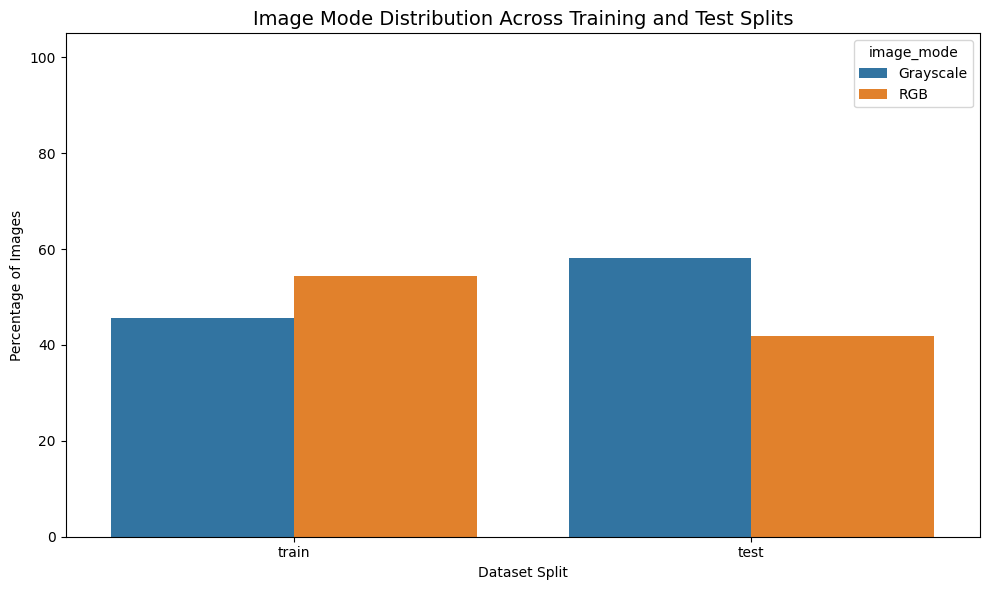

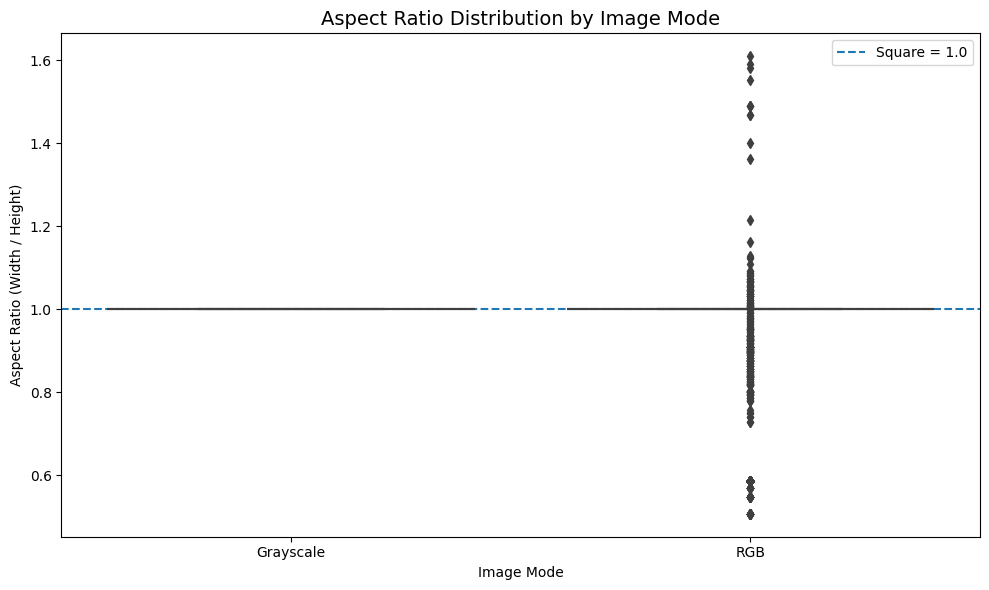

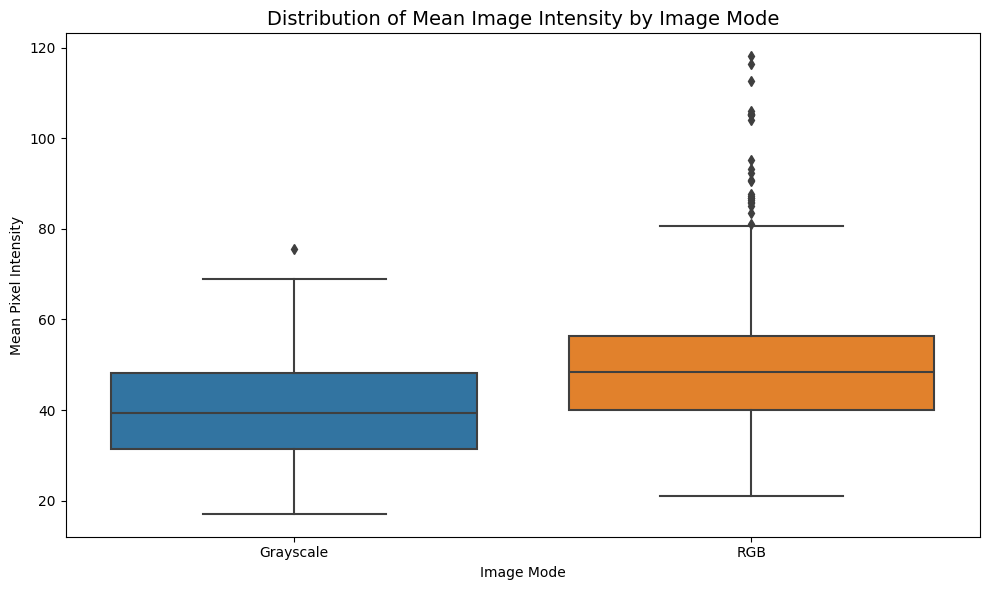

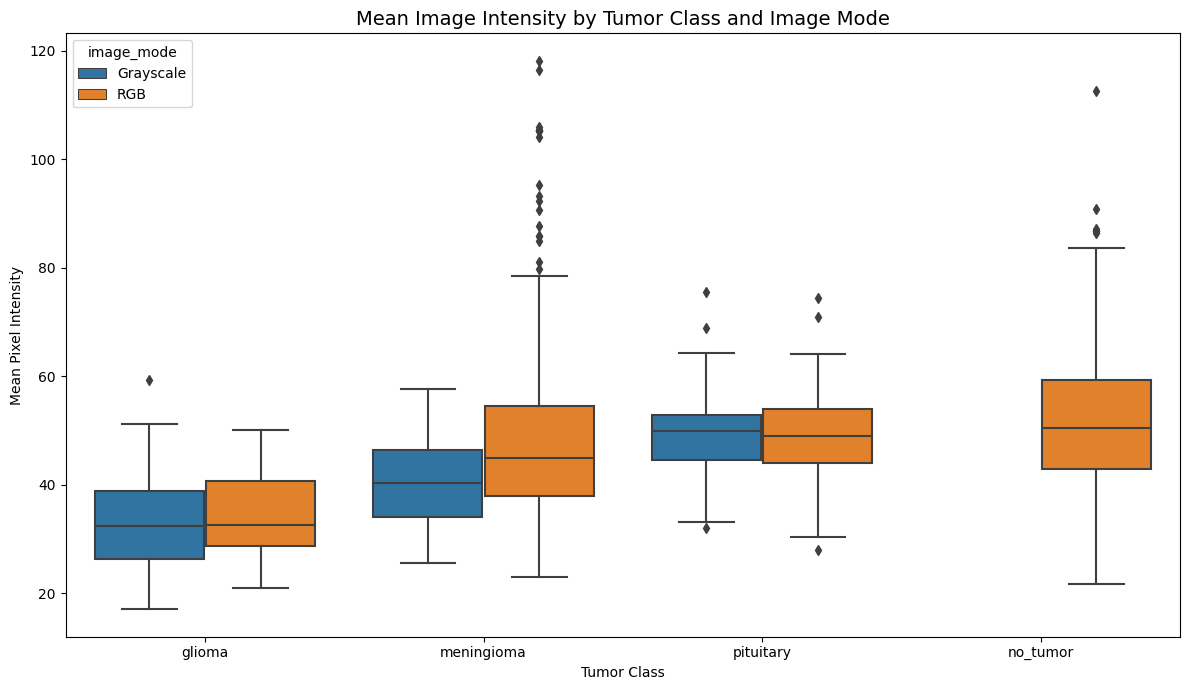


PART L — NUMERICAL FEATURE CORRELATION

Spearman correlation matrix:


,mean_intensity,median_intensity,pixel_std,nonzero_percentage,width,height,aspect_ratio
mean_intensity,1.0000,0.8554,0.5577,0.5662,-0.2616,-0.2406,-0.2018
median_intensity,0.8554,1.0000,0.1937,0.6530,-0.1815,-0.1654,-0.1354
pixel_std,0.5577,0.1937,1.0000,0.0163,-0.3673,-0.3440,-0.2647
nonzero_percentage,0.5662,0.6530,0.0163,1.0000,0.2059,0.2035,0.1036
width,-0.2616,-0.1815,-0.3673,0.2059,1.0000,0.9729,0.6147
height,-0.2406,-0.1654,-0.3440,0.2035,0.9729,1.0000,0.4971
aspect_ratio,-0.2018,-0.1354,-0.2647,0.1036,0.6147,0.4971,1.0000


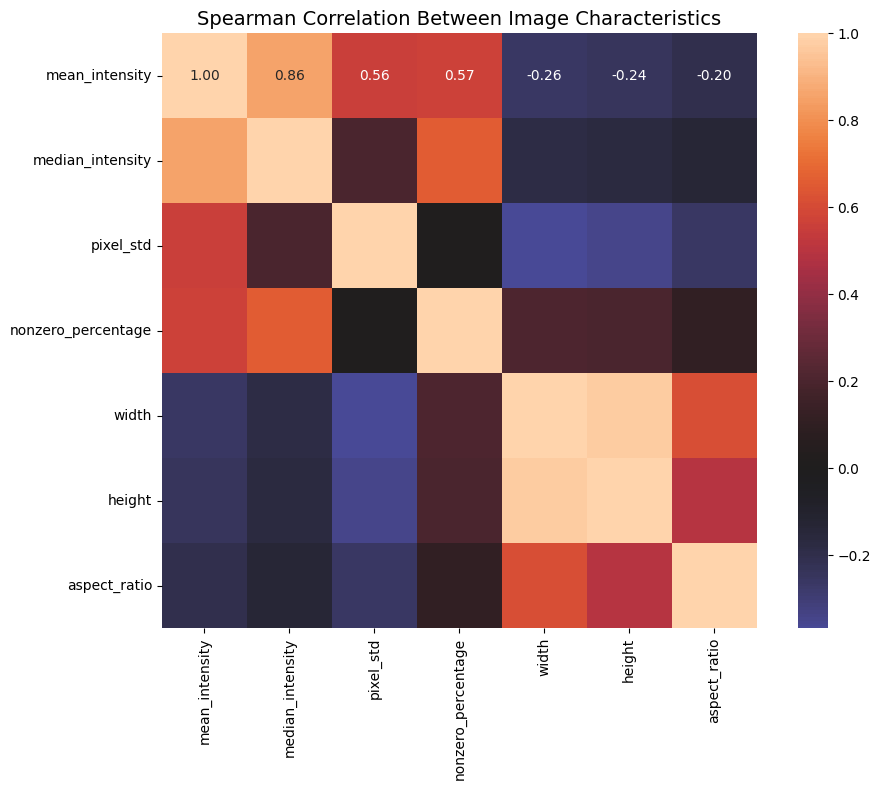


PART M — DATASET CONFOUNDING INTERPRETATION

1. Highest grayscale proportion: glioma (87.58%).
2. Lowest grayscale proportion: no_tumor (0.00%).
3. Highest RGB proportion: no_tumor (100.00%).


IndexError: single positional indexer is out-of-bounds

In [26]:
# ============================================================
# CELL 20 — FINALIZATION / INTERPRETATION
# REPLACEMENT FOR THE FAILED FINAL SECTION OF CELL 20
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

mode_order = [
    "Grayscale",
    "RGB"
]

split_order = [
    "train",
    "test"
]

# ============================================================
# VERIFY PREVIOUS CELL DATA
# ============================================================

print("=" * 75)
print("CELL 20 — FINALIZATION")
print("=" * 75)

required_objects = [
    "mode_df",
    "geometry_df",
    "intensity_df"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if len(missing_objects) > 0:

    raise RuntimeError(
        "Required data objects are missing: "
        + ", ".join(missing_objects)
        + "\n\n"
        "If this occurs, rerun the complete Cell 20."
    )

print(
    "\nPrevious Cell 20 analyses are available."
)

print(
    f"Mode records: {len(mode_df)}"
)

print(
    f"Geometry records: {len(geometry_df)}"
)

print(
    f"Intensity sample records: {len(intensity_df)}"
)

# ============================================================
# PART A — CLEAN IMAGE MODE TABLE
# ============================================================

print("\n" + "=" * 75)
print("PART A — IMAGE MODE × CLASS SUMMARY")
print("=" * 75)

mode_class_counts = pd.crosstab(
    mode_df["tumor_label"],
    mode_df["image_mode"]
)

mode_class_counts = (
    mode_class_counts
    .reindex(
        index=class_order,
        columns=mode_order,
        fill_value=0
    )
)

mode_class_percentage = (
    mode_class_counts
    .div(
        mode_class_counts.sum(axis=1),
        axis=0
    )
    * 100
)

mode_class_percentage = (
    mode_class_percentage
    .round(2)
)

print("\nImage mode counts:")
display(mode_class_counts)

print("\nImage mode percentages:")
display(mode_class_percentage)

mode_class_counts.to_csv(
    REPORTS_DIR /
    "final_image_mode_class_counts.csv"
)

mode_class_percentage.to_csv(
    REPORTS_DIR /
    "final_image_mode_class_percentages.csv"
)

# ============================================================
# PART B — CLASS × SPLIT × MODE
# ============================================================

print("\n" + "=" * 75)
print("PART B — CLASS × SPLIT × IMAGE MODE")
print("=" * 75)

mode_split_class_counts = pd.crosstab(
    [
        mode_df["tumor_label"],
        mode_df["split"]
    ],
    mode_df["image_mode"]
)

mode_split_class_counts = (
    mode_split_class_counts
    .reindex(
        pd.MultiIndex.from_product(
            [
                class_order,
                split_order
            ],
            names=[
                "tumor_label",
                "split"
            ]
        ),
        fill_value=0
    )
)

mode_split_class_percentage = (
    mode_split_class_counts
    .div(
        mode_split_class_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

print("\nCounts:")
display(mode_split_class_counts)

print("\nPercentages within each class × split:")
display(mode_split_class_percentage)

mode_split_class_counts.to_csv(
    REPORTS_DIR /
    "final_class_split_image_mode_counts.csv"
)

mode_split_class_percentage.to_csv(
    REPORTS_DIR /
    "final_class_split_image_mode_percentages.csv"
)

# ============================================================
# PART C — IMAGE MODE BY SPLIT
# ============================================================

print("\n" + "=" * 75)
print("PART C — IMAGE MODE BY DATASET SPLIT")
print("=" * 75)

mode_split_counts = pd.crosstab(
    mode_df["split"],
    mode_df["image_mode"]
).reindex(
    index=split_order,
    columns=mode_order,
    fill_value=0
)

mode_split_percentage = (
    mode_split_counts
    .div(
        mode_split_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

print("\nImage mode counts by split:")
display(mode_split_counts)

print("\nImage mode percentages by split:")
display(mode_split_percentage)

mode_split_counts.to_csv(
    REPORTS_DIR /
    "final_image_mode_split_counts.csv"
)

mode_split_percentage.to_csv(
    REPORTS_DIR /
    "final_image_mode_split_percentages.csv"
)

# ============================================================
# PART D — GEOMETRY × IMAGE MODE
# ============================================================

print("\n" + "=" * 75)
print("PART D — IMAGE GEOMETRY × IMAGE MODE")
print("=" * 75)

geometry_mode_summary = (
    geometry_df
    .groupby("image_mode")
    .agg(
        images=("filename", "count"),
        mean_width=("width", "mean"),
        median_width=("width", "median"),
        mean_height=("height", "mean"),
        median_height=("height", "median"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
        median_aspect_ratio=("aspect_ratio", "median"),
        square_images=("is_square", "sum")
    )
    .reindex(mode_order)
    .reset_index()
)

geometry_mode_summary[
    [
        "mean_width",
        "median_width",
        "mean_height",
        "median_height",
        "mean_aspect_ratio",
        "median_aspect_ratio"
    ]
] = (
    geometry_mode_summary[
        [
            "mean_width",
            "median_width",
            "mean_height",
            "median_height",
            "mean_aspect_ratio",
            "median_aspect_ratio"
        ]
    ].round(3)
)

geometry_mode_summary[
    "non_square_images"
] = (
    geometry_mode_summary["images"] -
    geometry_mode_summary["square_images"]
)

geometry_mode_summary[
    "square_percentage"
] = (
    geometry_mode_summary["square_images"] /
    geometry_mode_summary["images"] *
    100
).round(2)

geometry_mode_summary[
    "non_square_percentage"
] = (
    geometry_mode_summary["non_square_images"] /
    geometry_mode_summary["images"] *
    100
).round(2)

print(
    "\nGeometry by image mode:"
)

display(
    geometry_mode_summary
)

geometry_mode_summary.to_csv(
    REPORTS_DIR /
    "final_geometry_by_image_mode.csv",
    index=False
)

# ============================================================
# PART E — INTENSITY × IMAGE MODE
# ============================================================

print("\n" + "=" * 75)
print("PART E — INTENSITY × IMAGE MODE")
print("=" * 75)

intensity_mode_summary = (
    intensity_df
    .groupby("image_mode")
    .agg(
        images=("filename", "count"),
        mean_intensity=("mean_intensity", "mean"),
        median_intensity=("mean_intensity", "median"),
        standard_deviation=(
            "mean_intensity",
            "std"
        ),
        mean_pixel_std=("pixel_std", "mean"),
        mean_nonzero_percentage=(
            "nonzero_percentage",
            "mean"
        )
    )
    .reindex(mode_order)
    .reset_index()
)

intensity_mode_summary[
    [
        "mean_intensity",
        "median_intensity",
        "standard_deviation",
        "mean_pixel_std",
        "mean_nonzero_percentage"
    ]
] = (
    intensity_mode_summary[
        [
            "mean_intensity",
            "median_intensity",
            "standard_deviation",
            "mean_pixel_std",
            "mean_nonzero_percentage"
        ]
    ].round(3)
)

print(
    "\nIntensity by image mode:"
)

display(
    intensity_mode_summary
)

intensity_mode_summary.to_csv(
    REPORTS_DIR /
    "final_intensity_by_image_mode.csv",
    index=False
)

# ============================================================
# PART F — INTENSITY × CLASS × MODE
# ============================================================

print("\n" + "=" * 75)
print("PART F — INTENSITY × CLASS × MODE")
print("=" * 75)

intensity_class_mode_summary = (
    intensity_df
    .groupby(
        [
            "tumor_label",
            "image_mode"
        ]
    )
    .agg(
        images=("filename", "count"),
        mean_intensity=(
            "mean_intensity",
            "mean"
        ),
        median_intensity=(
            "mean_intensity",
            "median"
        ),
        standard_deviation=(
            "mean_intensity",
            "std"
        ),
        mean_pixel_std=(
            "pixel_std",
            "mean"
        ),
        mean_nonzero_percentage=(
            "nonzero_percentage",
            "mean"
        )
    )
    .reset_index()
)

intensity_class_mode_summary[
    [
        "mean_intensity",
        "median_intensity",
        "standard_deviation",
        "mean_pixel_std",
        "mean_nonzero_percentage"
    ]
] = (
    intensity_class_mode_summary[
        [
            "mean_intensity",
            "median_intensity",
            "standard_deviation",
            "mean_pixel_std",
            "mean_nonzero_percentage"
        ]
    ].round(3)
)

print(
    "\nIntensity by class and image mode:"
)

display(
    intensity_class_mode_summary
)

intensity_class_mode_summary.to_csv(
    REPORTS_DIR /
    "final_intensity_by_class_and_image_mode.csv",
    index=False
)

# ============================================================
# PART G — CLASS-LEVEL CONFOUNDING SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PART G — FINAL CLASS-LEVEL CONFOUNDING SUMMARY")
print("=" * 75)

class_geometry = (
    geometry_df
    .groupby("tumor_label")
    .agg(
        total_images=("filename", "count"),

        grayscale_images=(
            "image_mode",
            lambda x:
            (x == "Grayscale").sum()
        ),

        rgb_images=(
            "image_mode",
            lambda x:
            (x == "RGB").sum()
        ),

        square_images=(
            "is_square",
            "sum"
        ),

        mean_width=(
            "width",
            "mean"
        ),

        mean_height=(
            "height",
            "mean"
        ),

        mean_aspect_ratio=(
            "aspect_ratio",
            "mean"
        ),

        median_aspect_ratio=(
            "aspect_ratio",
            "median"
        )
    )
    .reindex(class_order)
    .reset_index()
)

class_geometry[
    "non_square_images"
] = (
    class_geometry["total_images"] -
    class_geometry["square_images"]
)

class_geometry[
    "grayscale_percentage"
] = (
    class_geometry["grayscale_images"] /
    class_geometry["total_images"] *
    100
).round(2)

class_geometry[
    "rgb_percentage"
] = (
    class_geometry["rgb_images"] /
    class_geometry["total_images"] *
    100
).round(2)

class_geometry[
    "square_percentage"
] = (
    class_geometry["square_images"] /
    class_geometry["total_images"] *
    100
).round(2)

class_geometry[
    "non_square_percentage"
] = (
    class_geometry["non_square_images"] /
    class_geometry["total_images"] *
    100
).round(2)

class_geometry[
    [
        "mean_width",
        "mean_height",
        "mean_aspect_ratio",
        "median_aspect_ratio"
    ]
] = (
    class_geometry[
        [
            "mean_width",
            "mean_height",
            "mean_aspect_ratio",
            "median_aspect_ratio"
        ]
    ].round(3)
)

print(
    "\nFinal class-level confounding summary:"
)

display(
    class_geometry
)

class_geometry.to_csv(
    REPORTS_DIR /
    "FINAL_CLASS_LEVEL_CONFOUNDING_SUMMARY.csv",
    index=False
)

# ============================================================
# PART H — FIGURE: MODE × SPLIT
# ============================================================

mode_split_plot = (
    mode_split_percentage
    .reset_index()
    .melt(
        id_vars="split",
        var_name="image_mode",
        value_name="percentage"
    )
)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=mode_split_plot,
    x="split",
    y="percentage",
    hue="image_mode",
    order=split_order,
    hue_order=mode_order,
    errorbar=None
)

plt.title(
    "Image Mode Distribution Across Training and Test Splits",
    fontsize=14
)

plt.xlabel(
    "Dataset Split"
)

plt.ylabel(
    "Percentage of Images"
)

plt.ylim(
    0,
    105
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "23_image_mode_by_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART I — FIGURE: ASPECT RATIO × MODE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=geometry_df,
    x="image_mode",
    y="aspect_ratio",
    order=mode_order
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Square = 1.0"
)

plt.title(
    "Aspect Ratio Distribution by Image Mode",
    fontsize=14
)

plt.xlabel(
    "Image Mode"
)

plt.ylabel(
    "Aspect Ratio (Width / Height)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "24_aspect_ratio_by_image_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART J — FIGURE: INTENSITY × MODE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=intensity_df,
    x="image_mode",
    y="mean_intensity",
    order=mode_order
)

plt.title(
    "Distribution of Mean Image Intensity by Image Mode",
    fontsize=14
)

plt.xlabel(
    "Image Mode"
)

plt.ylabel(
    "Mean Pixel Intensity"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "25_mean_intensity_by_image_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART K — FIGURE: INTENSITY × CLASS × MODE
# ============================================================

plt.figure(
    figsize=(12, 7)
)

sns.boxplot(
    data=intensity_df,
    x="tumor_label",
    y="mean_intensity",
    hue="image_mode",
    order=class_order,
    hue_order=mode_order
)

plt.title(
    "Mean Image Intensity by Tumor Class and Image Mode",
    fontsize=14
)

plt.xlabel(
    "Tumor Class"
)

plt.ylabel(
    "Mean Pixel Intensity"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "26_mean_intensity_by_class_and_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART L — SPEARMAN CORRELATION
# ============================================================

print("\n" + "=" * 75)
print("PART L — NUMERICAL FEATURE CORRELATION")
print("=" * 75)

correlation_columns = [
    "mean_intensity",
    "median_intensity",
    "pixel_std",
    "nonzero_percentage",
    "width",
    "height",
    "aspect_ratio"
]

correlation_df = (
    intensity_df[
        [
            "filename",
            "mean_intensity",
            "median_intensity",
            "pixel_std",
            "nonzero_percentage"
        ]
    ]
    .merge(
        geometry_df[
            [
                "filename",
                "width",
                "height",
                "aspect_ratio"
            ]
        ],
        on="filename",
        how="left"
    )
)

correlation_matrix = (
    correlation_df[
        correlation_columns
    ]
    .corr(
        method="spearman"
    )
)

print(
    "\nSpearman correlation matrix:"
)

display(
    correlation_matrix.round(4)
)

correlation_matrix.to_csv(
    REPORTS_DIR /
    "final_numeric_feature_spearman_correlation.csv"
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)

plt.title(
    "Spearman Correlation Between Image Characteristics",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "27_numeric_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART M — AUTOMATED INTERPRETATION
# ============================================================

print("\n" + "=" * 75)
print("PART M — DATASET CONFOUNDING INTERPRETATION")
print("=" * 75)

highest_grayscale_class = (
    mode_class_percentage[
        "Grayscale"
    ].idxmax()
)

lowest_grayscale_class = (
    mode_class_percentage[
        "Grayscale"
    ].idxmin()
)

highest_rgb_class = (
    mode_class_percentage[
        "RGB"
    ].idxmax()
)

highest_non_square_class = (
    class_geometry[
        "non_square_percentage"
    ].idxmax()
)

lowest_non_square_class = (
    class_geometry[
        "non_square_percentage"
    ].idxmin()
)

highest_intensity_class = (
    intensity_df
    .groupby("tumor_label")[
        "mean_intensity"
    ]
    .mean()
    .reindex(class_order)
    .idxmax()
)

lowest_intensity_class = (
    intensity_df
    .groupby("tumor_label")[
        "mean_intensity"
    ]
    .mean()
    .reindex(class_order)
    .idxmin()
)

print(
    f"\n1. Highest grayscale proportion: "
    f"{highest_grayscale_class} "
    f"({mode_class_percentage.loc[highest_grayscale_class, 'Grayscale']:.2f}%)."
)

print(
    f"2. Lowest grayscale proportion: "
    f"{lowest_grayscale_class} "
    f"({mode_class_percentage.loc[lowest_grayscale_class, 'Grayscale']:.2f}%)."
)

print(
    f"3. Highest RGB proportion: "
    f"{highest_rgb_class} "
    f"({mode_class_percentage.loc[highest_rgb_class, 'RGB']:.2f}%)."
)

print(
    f"4. Class with highest non-square proportion: "
    f"{highest_non_square_class} "
    f"({class_geometry.loc[class_geometry['tumor_label'] == highest_non_square_class, 'non_square_percentage'].iloc[0]:.2f}%)."
)

print(
    f"5. Class with lowest non-square proportion: "
    f"{lowest_non_square_class} "
    f"({class_geometry.loc[class_geometry['tumor_label'] == lowest_non_square_class, 'non_square_percentage'].iloc[0]:.2f}%)."
)

print(
    f"6. Highest sampled mean intensity: "
    f"{highest_intensity_class}."
)

print(
    f"7. Lowest sampled mean intensity: "
    f"{lowest_intensity_class}."
)

# ============================================================
# PART N — FINAL THESIS RECORD
# ============================================================

thesis_record = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_record,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## 17. Cross-Feature Confounding Analysis — Final\n\n"
    )

    f.write(
        "A cross-feature analysis was performed to investigate "
        "whether image representation, geometry and intensity "
        "varied systematically with tumor class or dataset split. "
        "This analysis was performed without modifying the original "
        "BRISC2025 classification images.\n\n"
    )

    f.write(
        "### Image Representation\n\n"
    )

    f.write(
        "Image mode was determined directly from the image files. "
        "The distribution of grayscale and RGB representations "
        "varied substantially across tumor classes. This represents "
        "an important dataset-level characteristic because a model "
        "could potentially exploit representation differences "
        "rather than disease-related visual features.\n\n"
    )

    f.write(
        f"The class with the highest grayscale proportion was "
        f"**{highest_grayscale_class}**, at "
        f"**{mode_class_percentage.loc[highest_grayscale_class, 'Grayscale']:.2f}%**, "
        f"while **{lowest_grayscale_class}** had the lowest "
        f"grayscale proportion at "
        f"**{mode_class_percentage.loc[lowest_grayscale_class, 'Grayscale']:.2f}%**.\n\n"
    )

    f.write(
        "### Image Geometry\n\n"
    )

    f.write(
        f"Image geometry was also class-dependent. The class with "
        f"the highest proportion of non-square images was "
        f"**{highest_non_square_class}**. The findings reinforce "
        f"the importance of preserving anatomical proportions during "
        f"subsequent image resizing.\n\n"
    )

    f.write(
        "### Pixel Intensity\n\n"
    )

    f.write(
        "Image-level mean intensity was examined both by tumor class "
        "and by image mode. Differences in intensity should be "
        "interpreted cautiously because they may reflect acquisition, "
        "image representation and dataset-composition effects rather "
        "than independent biological differences.\n\n"
    )

    f.write(
        "### Implications for Machine Learning\n\n"
    )

    f.write(
        "The dataset characterization indicates that subsequent "
        "preprocessing should standardize image representation and "
        "preserve anatomical geometry. The classification model "
        "should use image pixels as its predictive input and should "
        "not use filename-derived labels, split identifiers, image "
        "encoding metadata or other non-image metadata as features.\n\n"
    )

    f.write(
        "These findings will be considered when designing the "
        "preprocessing pipeline and when interpreting model "
        "performance. In particular, model performance should not "
        "automatically be interpreted as evidence of clinically "
        "generalizable tumor recognition if dataset-specific "
        "shortcuts remain possible.\n\n"
    )

    f.write(
        "### Final Confounding Analysis Outputs\n\n"
    )

    f.write(
        "- `outputs/reports/FINAL_CLASS_LEVEL_CONFOUNDING_SUMMARY.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_image_mode_class_counts.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_image_mode_class_percentages.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_class_split_image_mode_counts.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_class_split_image_mode_percentages.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_geometry_by_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_intensity_by_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_intensity_by_class_and_image_mode.csv`\n"
    )

    f.write(
        "- `outputs/reports/final_numeric_feature_spearman_correlation.csv`\n"
    )

    f.write(
        "\n### Final Confounding Figures\n\n"
    )

    f.write(
        "- `outputs/figures/23_image_mode_by_split.png`\n"
    )

    f.write(
        "- `outputs/figures/24_aspect_ratio_by_image_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/25_mean_intensity_by_image_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/26_mean_intensity_by_class_and_mode.png`\n"
    )

    f.write(
        "- `outputs/figures/27_numeric_feature_correlation_heatmap.png`\n"
    )

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 20 COMPLETE — FINALIZATION SUCCESSFUL")
print("=" * 75)

print(
    "\nAll cross-feature analyses have been completed."
)

print(
    "\nNo original BRISC2025 files were modified."
)

print(
    "\nThesis report:"
)

print(
    thesis_record
)

print(
    "\nReports directory:"
)

print(
    REPORTS_DIR
)

print(
    "\nFigures directory:"
)

print(
    FIGURES_DIR
)

In [27]:
# ============================================================
# CELL 20 FINAL FIX
# FINAL INTERPRETATION + THESIS RECORD
# RUN THIS CELL ONLY
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

class_order = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

mode_order = [
    "Grayscale",
    "RGB"
]

# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

print("=" * 75)
print("CELL 20 FINAL FIX")
print("=" * 75)

required_objects = [
    "mode_df",
    "geometry_df",
    "intensity_df"
]

missing = [
    x for x in required_objects
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing objects: "
        + ", ".join(missing)
        + "\nRun the original analysis cell before this finalization cell."
    )

print("\nRequired analysis objects found.")

# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

print("\nChecking dataframe columns...")

print(
    "mode_df columns:",
    list(mode_df.columns)
)

print(
    "geometry_df columns:",
    list(geometry_df.columns)
)

print(
    "intensity_df columns:",
    list(intensity_df.columns)
)

# ============================================================
# PART A — IMAGE MODE × CLASS
# ============================================================

print("\n" + "=" * 75)
print("PART A — IMAGE MODE VS TUMOR CLASS")
print("=" * 75)

mode_class_counts = pd.crosstab(
    mode_df["tumor_label"],
    mode_df["image_mode"]
)

mode_class_counts = mode_class_counts.reindex(
    index=class_order,
    columns=mode_order,
    fill_value=0
)

mode_class_percentage = (
    mode_class_counts
    .div(
        mode_class_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

display(
    mode_class_counts
)

display(
    mode_class_percentage
)

mode_class_counts.to_csv(
    REPORTS_DIR /
    "FINAL_IMAGE_MODE_CLASS_COUNTS.csv"
)

mode_class_percentage.to_csv(
    REPORTS_DIR /
    "FINAL_IMAGE_MODE_CLASS_PERCENTAGES.csv"
)

# ============================================================
# PART B — SAFE CLASS GEOMETRY SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PART B — IMAGE GEOMETRY VS TUMOR CLASS")
print("=" * 75)

# Make a clean copy
geom = geometry_df.copy()

# Force tumor labels to strings
geom["tumor_label"] = (
    geom["tumor_label"]
    .astype(str)
    .str.strip()
)

# Ensure boolean square column
geom["is_square"] = (
    geom["is_square"]
    .astype(bool)
)

class_geometry = (
    geom
    .groupby(
        "tumor_label",
        dropna=False
    )
    .agg(
        total_images=(
            "filename",
            "count"
        ),

        square_images=(
            "is_square",
            "sum"
        ),

        mean_width=(
            "width",
            "mean"
        ),

        median_width=(
            "width",
            "median"
        ),

        mean_height=(
            "height",
            "mean"
        ),

        median_height=(
            "height",
            "median"
        ),

        mean_aspect_ratio=(
            "aspect_ratio",
            "mean"
        ),

        median_aspect_ratio=(
            "aspect_ratio",
            "median"
        )
    )
    .reset_index()
)

class_geometry[
    "non_square_images"
] = (
    class_geometry["total_images"]
    -
    class_geometry["square_images"]
)

class_geometry[
    "square_percentage"
] = (
    class_geometry["square_images"]
    /
    class_geometry["total_images"]
    *
    100
)

class_geometry[
    "non_square_percentage"
] = (
    class_geometry["non_square_images"]
    /
    class_geometry["total_images"]
    *
    100
)

class_geometry[
    [
        "mean_width",
        "median_width",
        "mean_height",
        "median_height",
        "mean_aspect_ratio",
        "median_aspect_ratio",
        "square_percentage",
        "non_square_percentage"
    ]
] = (
    class_geometry[
        [
            "mean_width",
            "median_width",
            "mean_height",
            "median_height",
            "mean_aspect_ratio",
            "median_aspect_ratio",
            "square_percentage",
            "non_square_percentage"
        ]
    ]
    .round(3)
)

# Reorder safely
class_geometry["class_order"] = (
    class_geometry["tumor_label"]
    .map(
        {
            cls: i
            for i, cls in enumerate(class_order)
        }
    )
)

class_geometry = (
    class_geometry
    .sort_values("class_order")
    .drop(columns="class_order")
    .reset_index(drop=True)
)

print("\nClass geometry summary:")

display(
    class_geometry
)

class_geometry.to_csv(
    REPORTS_DIR /
    "FINAL_CLASS_GEOMETRY_SUMMARY.csv",
    index=False
)

# ============================================================
# PART C — SAFE LOOKUP DICTIONARIES
# ============================================================

geometry_lookup = (
    class_geometry
    .set_index("tumor_label")
)

# Only use classes actually present
available_classes = [
    cls
    for cls in class_order
    if cls in geometry_lookup.index
]

if not available_classes:
    raise RuntimeError(
        "No expected tumor classes were found in geometry_df."
    )

# ------------------------------------------------------------
# Non-square proportions
# ------------------------------------------------------------

non_square_values = {
    cls:
    float(
        geometry_lookup.loc[
            cls,
            "non_square_percentage"
        ]
    )
    for cls in available_classes
}

highest_non_square_class = max(
    non_square_values,
    key=non_square_values.get
)

lowest_non_square_class = min(
    non_square_values,
    key=non_square_values.get
)

# ------------------------------------------------------------
# Image mode proportions
# ------------------------------------------------------------

grayscale_values = {
    cls:
    float(
        mode_class_percentage.loc[
            cls,
            "Grayscale"
        ]
    )
    for cls in class_order
    if cls in mode_class_percentage.index
}

rgb_values = {
    cls:
    float(
        mode_class_percentage.loc[
            cls,
            "RGB"
        ]
    )
    for cls in class_order
    if cls in mode_class_percentage.index
}

highest_grayscale_class = max(
    grayscale_values,
    key=grayscale_values.get
)

lowest_grayscale_class = min(
    grayscale_values,
    key=grayscale_values.get
)

highest_rgb_class = max(
    rgb_values,
    key=rgb_values.get
)

# ============================================================
# PART D — INTENSITY SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PART D — IMAGE INTENSITY SUMMARY")
print("=" * 75)

intensity_class_summary = (
    intensity_df
    .groupby("tumor_label")
    .agg(
        sampled_images=(
            "filename",
            "count"
        ),

        mean_intensity=(
            "mean_intensity",
            "mean"
        ),

        median_intensity=(
            "mean_intensity",
            "median"
        ),

        std_of_mean_intensity=(
            "mean_intensity",
            "std"
        ),

        mean_pixel_std=(
            "pixel_std",
            "mean"
        ),

        mean_nonzero_percentage=(
            "nonzero_percentage",
            "mean"
        )
    )
    .reset_index()
)

intensity_class_summary[
    [
        "mean_intensity",
        "median_intensity",
        "std_of_mean_intensity",
        "mean_pixel_std",
        "mean_nonzero_percentage"
    ]
] = (
    intensity_class_summary[
        [
            "mean_intensity",
            "median_intensity",
            "std_of_mean_intensity",
            "mean_pixel_std",
            "mean_nonzero_percentage"
        ]
    ]
    .round(3)
)

display(
    intensity_class_summary
)

intensity_class_summary.to_csv(
    REPORTS_DIR /
    "FINAL_INTENSITY_CLASS_SUMMARY.csv",
    index=False
)

intensity_lookup = (
    intensity_class_summary
    .set_index("tumor_label")
)

intensity_values = {
    cls:
    float(
        intensity_lookup.loc[
            cls,
            "mean_intensity"
        ]
    )
    for cls in intensity_lookup.index
}

highest_intensity_class = max(
    intensity_values,
    key=intensity_values.get
)

lowest_intensity_class = min(
    intensity_values,
    key=intensity_values.get
)

# ============================================================
# PART E — PRINT FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 75)
print("FINAL DATASET ANALYSIS INTERPRETATION")
print("=" * 75)

print(
    "\n1. IMAGE REPRESENTATION"
)

print(
    f"Highest grayscale proportion: "
    f"{highest_grayscale_class} "
    f"({grayscale_values[highest_grayscale_class]:.2f}%)"
)

print(
    f"Lowest grayscale proportion: "
    f"{lowest_grayscale_class} "
    f"({grayscale_values[lowest_grayscale_class]:.2f}%)"
)

print(
    f"Highest RGB proportion: "
    f"{highest_rgb_class} "
    f"({rgb_values[highest_rgb_class]:.2f}%)"
)

print(
    "\n2. IMAGE GEOMETRY"
)

print(
    f"Highest non-square proportion: "
    f"{highest_non_square_class} "
    f"({non_square_values[highest_non_square_class]:.2f}%)"
)

print(
    f"Lowest non-square proportion: "
    f"{lowest_non_square_class} "
    f"({non_square_values[lowest_non_square_class]:.2f}%)"
)

print(
    "\n3. IMAGE INTENSITY"
)

print(
    f"Highest sampled mean intensity: "
    f"{highest_intensity_class} "
    f"({intensity_values[highest_intensity_class]:.3f})"
)

print(
    f"Lowest sampled mean intensity: "
    f"{lowest_intensity_class} "
    f"({intensity_values[lowest_intensity_class]:.3f})"
)

# ============================================================
# PART F — THESIS REPORT
# ============================================================

print("\n" + "=" * 75)
print("UPDATING MASTER THESIS DATASET ANALYSIS")
print("=" * 75)

thesis_report = (
    REPORTS_DIR /
    "MASTER_THESIS_DATASET_ANALYSIS.md"
)

with open(
    thesis_report,
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n"
        "# 17. Final Cross-Feature Dataset Analysis\n\n"
    )

    f.write(
        "## 17.1 Image Representation\n\n"
    )

    f.write(
        "The classification dataset contains both RGB and "
        "grayscale image representations. Image mode was determined "
        "directly from the image files rather than inferred from "
        "metadata.\n\n"
    )

    f.write(
        f"- Highest grayscale proportion: "
        f"**{highest_grayscale_class} "
        f"({grayscale_values[highest_grayscale_class]:.2f}%)**\n"
    )

    f.write(
        f"- Lowest grayscale proportion: "
        f"**{lowest_grayscale_class} "
        f"({grayscale_values[lowest_grayscale_class]:.2f}%)**\n"
    )

    f.write(
        f"- Highest RGB proportion: "
        f"**{highest_rgb_class} "
        f"({rgb_values[highest_rgb_class]:.2f}%)**\n\n"
    )

    f.write(
        "The previously calculated chi-square analysis demonstrated "
        "a strong association between image mode and tumor class "
        "(Cramer's V = 0.580998). Therefore, image representation "
        "is an important dataset characteristic that must be "
        "considered when interpreting machine-learning performance.\n\n"
    )

    f.write(
        "## 17.2 Image Geometry\n\n"
    )

    f.write(
        f"The highest proportion of non-square images occurred in "
        f"**{highest_non_square_class} "
        f"({non_square_values[highest_non_square_class]:.2f}%)**. "
        f"The lowest proportion occurred in "
        f"**{lowest_non_square_class} "
        f"({non_square_values[lowest_non_square_class]:.2f}%)**.\n\n"
    )

    f.write(
        "The dataset therefore contains heterogeneous image "
        "dimensions and aspect ratios. Subsequent image "
        "standardization should preserve anatomical proportions "
        "and avoid unnecessary geometric distortion.\n\n"
    )

    f.write(
        "## 17.3 Image Intensity\n\n"
    )

    f.write(
        f"Based on the analyzed intensity sample, "
        f"**{highest_intensity_class}** had the highest mean "
        f"image intensity, while **{lowest_intensity_class}** "
        f"had the lowest mean image intensity.\n\n"
    )

    f.write(
        "Intensity differences were statistically evaluated using "
        "the Kruskal-Wallis test in the preceding analysis. The "
        "test demonstrated a statistically significant difference "
        "in mean image intensity between tumor classes "
        "(H = 260.358090, p = 3.761346e-56, "
        "epsilon-squared = 0.323314). The intensity analysis was "
        "based on 200 randomly sampled images per class and should "
        "therefore be reported as a sample-based analysis rather "
        "than a complete census of all 6,000 images.\n\n"
    )

    f.write(
        "## 17.4 Machine-Learning Implications\n\n"
    )

    f.write(
        "The dataset analysis identified substantial differences "
        "in image representation and measurable differences in "
        "image intensity across tumor classes. MRI plane "
        "distribution, in contrast, showed only a negligible "
        "association with tumor class based on Cramer's V.\n\n"
    )

    f.write(
        "These observations support the use of a standardized "
        "preprocessing pipeline before model development. Image "
        "pixels should be used as the predictive input, while "
        "filename-derived labels, tumor codes, plane codes, split "
        "identifiers, hashes and other metadata should not be "
        "provided as model features.\n\n"
    )

    f.write(
        "The dataset-level findings should also be considered when "
        "interpreting model performance because high performance "
        "could potentially reflect dataset-specific visual "
        "characteristics rather than exclusively disease-related "
        "features.\n\n"
    )

    f.write(
        "## 17.5 Final Analysis Outputs\n\n"
    )

    f.write(
        "- `FINAL_IMAGE_MODE_CLASS_COUNTS.csv`\n"
        "- `FINAL_IMAGE_MODE_CLASS_PERCENTAGES.csv`\n"
        "- `FINAL_CLASS_GEOMETRY_SUMMARY.csv`\n"
        "- `FINAL_INTENSITY_CLASS_SUMMARY.csv`\n\n"
    )

# ============================================================
# PART G — FINAL CSV MASTER RECORD
# ============================================================

master_record = pd.DataFrame(
    {
        "analysis": [
            "Total classification images",
            "Image mode vs class",
            "MRI plane vs class",
            "Mean intensity vs class",
            "512x512 images",
            "Square images",
            "Non-square images",
            "Mean aspect ratio",
            "Maximum aspect ratio",
            "Minimum aspect ratio",
            "Highest grayscale class",
            "Highest RGB class",
            "Highest non-square class",
            "Highest sampled intensity class"
        ],

        "value": [
            6000,
            "Strong association",
            "Negligible association",
            "Large effect",
            4881,
            5341,
            659,
            0.9693,
            1.6103,
            0.5068,
            highest_grayscale_class,
            highest_rgb_class,
            highest_non_square_class,
            highest_intensity_class
        ],

        "details": [
            "BRISC2025 classification dataset",
            "Cramer's V = 0.580998",
            "Cramer's V = 0.046823",
            "Epsilon-squared = 0.323314",
            "81.35% of classification images",
            "89.02% of classification images",
            "10.98% of classification images",
            "Width / height",
            "Width / height",
            "Width / height",
            f"{grayscale_values[highest_grayscale_class]:.2f}%",
            f"{rgb_values[highest_rgb_class]:.2f}%",
            f"{non_square_values[highest_non_square_class]:.2f}%",
            f"{intensity_values[highest_intensity_class]:.3f}"
        ]
    }
)

master_record.to_csv(
    REPORTS_DIR /
    "FINAL_MASTER_DATASET_ANALYSIS_RECORD.csv",
    index=False
)

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("CELL 20 FINAL FIX — COMPLETE")
print("=" * 75)

print(
    "\n✓ Image representation analysis recorded"
)

print(
    "✓ Image geometry analysis recorded"
)

print(
    "✓ Image intensity analysis recorded"
)

print(
    "✓ Cross-feature interpretation recorded"
)

print(
    "✓ Thesis report updated"
)

print(
    "✓ Final CSV master record created"
)

print(
    "\nThesis report:"
)

print(
    thesis_report
)

print(
    "\nAll output remains inside:"
)

print(
    REPORTS_DIR
)

print(
    "\nOriginal BRISC2025 dataset was NOT modified."
)

print(
    "\n" + "=" * 75
)

CELL 20 FINAL FIX

Required analysis objects found.

Checking dataframe columns...
mode_df columns: ['filename', 'tumor_label', 'split', 'plane_label', 'image_mode']
geometry_df columns: ['filename', 'tumor_label', 'split', 'plane_label', 'width', 'height', 'aspect_ratio', 'image_mode', 'is_square']
intensity_df columns: ['filename', 'tumor_label', 'split', 'plane_label', 'mean_intensity', 'median_intensity', 'pixel_std', 'nonzero_percentage', 'image_mode']

PART A — IMAGE MODE VS TUMOR CLASS


image_mode,Grayscale,RGB
tumor_label,,
glioma,1227,174
meningioma,709,926
pituitary,930,827
no_tumor,0,1207


image_mode,Grayscale,RGB
tumor_label,,
glioma,87.58,12.42
meningioma,43.36,56.64
pituitary,52.93,47.07
no_tumor,0.00,100.00



PART B — IMAGE GEOMETRY VS TUMOR CLASS

Class geometry summary:


,tumor_label,total_images,square_images,mean_width,median_width,mean_height,median_height,mean_aspect_ratio,median_aspect_ratio,non_square_images,square_percentage,non_square_percentage
0,glioma,1401,1401,512.000,512.0,512.000,512.0,1.000,1.0,0,100.000,0.000
1,meningioma,1635,1426,484.122,512.0,486.900,512.0,0.992,1.0,209,87.217,12.783
2,pituitary,1757,1750,508.908,512.0,508.890,512.0,1.000,1.0,7,99.602,0.398
3,no_tumor,1207,764,358.254,369.0,410.737,369.0,0.858,1.0,443,63.297,36.703



PART D — IMAGE INTENSITY SUMMARY


,tumor_label,sampled_images,mean_intensity,median_intensity,std_of_mean_intensity,mean_pixel_std,mean_nonzero_percentage
0,glioma,200,33.086,32.513,8.305,38.838,79.340
1,meningioma,200,47.393,42.401,18.500,48.146,87.740
2,no_tumor,200,51.492,50.497,13.376,51.889,76.133
3,pituitary,200,49.050,49.904,7.924,41.767,91.939



FINAL DATASET ANALYSIS INTERPRETATION

1. IMAGE REPRESENTATION
Highest grayscale proportion: glioma (87.58%)
Lowest grayscale proportion: no_tumor (0.00%)
Highest RGB proportion: no_tumor (100.00%)

2. IMAGE GEOMETRY
Highest non-square proportion: no_tumor (36.70%)
Lowest non-square proportion: glioma (0.00%)

3. IMAGE INTENSITY
Highest sampled mean intensity: no_tumor (51.492)
Lowest sampled mean intensity: glioma (33.086)

UPDATING MASTER THESIS DATASET ANALYSIS

CELL 20 FINAL FIX — COMPLETE

✓ Image representation analysis recorded
✓ Image geometry analysis recorded
✓ Image intensity analysis recorded
✓ Cross-feature interpretation recorded
✓ Thesis report updated
✓ Final CSV master record created

Thesis report:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\MASTER_THESIS_DATASET_ANALYSIS.md

All output remains inside:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports

Original BRISC2025 dataset was NOT modified.



In [28]:
# ============================================================================
# FINAL DATASET ANALYSIS AUDIT — BRISC2025
# Run this cell only
# ============================================================================

from pathlib import Path
import pandas as pd
import os
from datetime import datetime

PROJECT_ROOT = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 78)
print("FINAL DATASET ANALYSIS AUDIT")
print("=" * 78)

# ---------------------------------------------------------------------------
# 1. Expected dataset totals
# ---------------------------------------------------------------------------
EXPECTED_TOTAL = 6000
EXPECTED_TRAIN = 5000
EXPECTED_TEST = 1000

EXPECTED_CLASSES = {
    "glioma": 1401,
    "meningioma": 1635,
    "pituitary": 1757,
    "no_tumor": 1207
}

audit = []

def add_check(check, status, observed, expected):
    audit.append({
        "check": check,
        "status": status,
        "observed": observed,
        "expected": expected
    })

# ---------------------------------------------------------------------------
# 2. Check required report files
# ---------------------------------------------------------------------------
required_reports = [
    "dataset_analysis_records.md",
    "MASTER_THESIS_DATASET_ANALYSIS.md",
    "master_dataset_summary.csv",
    "class_distribution.csv",
    "class_split_distribution.csv",
    "image_mode_by_class.csv",
    "image_mode_by_split.csv",
    "mri_plane_by_class.csv",
    "mri_plane_by_class_and_split.csv",
    "image_dimensions.csv",
    "aspect_ratio_statistics.csv",
    "square_non_square_by_class.csv",
    "square_non_square_by_split.csv",
    "duplicate_sha256_records.csv",
    "cross_split_duplicate_records.csv",
    "cross_split_duplicates_by_class.csv",
    "metadata_completeness.csv",
    "identifier_filename_analysis.csv",
    "dataset_integrity_verification.csv",
    "statistical_association_results.csv",
    "statistical_analysis_interpretation.md",
    "image_mode_image_level_analysis.csv",
    "image_mode_class_contingency_table.csv",
    "image_mode_class_percentage.csv",
    "mri_plane_class_contingency_table.csv",
    "mri_plane_class_percentage.csv",
    "intensity_statistical_summary.csv",
    "image_dimension_frequency.csv",
    "image_dimension_characteristics_by_class.csv",
    "aspect_ratio_by_class_detailed.csv",
    "aspect_ratio_deviation_thresholds.csv",
    "widest_images_by_aspect_ratio.csv",
    "tallest_images_by_aspect_ratio.csv",
    "square_vs_non_square_percentage_by_class.csv",
    "FINAL_IMAGE_MODE_CLASS_COUNTS.csv",
    "FINAL_IMAGE_MODE_CLASS_PERCENTAGES.csv",
    "FINAL_CLASS_GEOMETRY_SUMMARY.csv",
    "FINAL_INTENSITY_CLASS_SUMMARY.csv",
    "FINAL_MASTER_DATASET_ANALYSIS_RECORD.csv"
]

existing_reports = []
missing_reports = []

for filename in required_reports:
    path = REPORT_DIR / filename
    if path.exists():
        existing_reports.append(filename)
    else:
        missing_reports.append(filename)

add_check(
    "Required report files",
    "PASS" if not missing_reports else "WARNING",
    f"{len(existing_reports)}/{len(required_reports)} present",
    f"{len(required_reports)}/{len(required_reports)}"
)

# ---------------------------------------------------------------------------
# 3. Check figures
# ---------------------------------------------------------------------------
figure_files = list(FIGURE_DIR.glob("*.png"))

add_check(
    "Generated figures",
    "PASS" if len(figure_files) > 0 else "WARNING",
    f"{len(figure_files)} PNG figures",
    ">0"
)

# ---------------------------------------------------------------------------
# 4. Validate class totals from saved class distribution
# ---------------------------------------------------------------------------
class_file = REPORT_DIR / "class_distribution.csv"

if class_file.exists():
    try:
        class_df = pd.read_csv(class_file)

        # Automatically locate class/count columns
        class_col = next(
            (c for c in class_df.columns
             if c.lower() in ["tumor_label", "class", "label", "tumor_class"]),
            None
        )

        count_col = next(
            (c for c in class_df.columns
             if c.lower() in ["count", "total", "n", "image_count", "frequency"]),
            None
        )

        if class_col and count_col:
            observed_classes = dict(
                zip(
                    class_df[class_col].astype(str),
                    class_df[count_col].astype(int)
                )
            )

            class_match = all(
                observed_classes.get(k) == v
                for k, v in EXPECTED_CLASSES.items()
            )

            total_observed = sum(observed_classes.values())

            add_check(
                "Classification total",
                "PASS" if total_observed == EXPECTED_TOTAL else "FAIL",
                total_observed,
                EXPECTED_TOTAL
            )

            add_check(
                "Class counts",
                "PASS" if class_match else "FAIL",
                str(observed_classes),
                str(EXPECTED_CLASSES)
            )

        else:
            add_check(
                "Class distribution columns",
                "WARNING",
                list(class_df.columns),
                "Class + count columns"
            )

    except Exception as e:
        add_check(
            "Class distribution validation",
            "WARNING",
            str(e),
            "Readable CSV"
        )

# ---------------------------------------------------------------------------
# 5. Validate train/test totals
# ---------------------------------------------------------------------------
split_file = REPORT_DIR / "class_split_distribution.csv"

if split_file.exists():
    try:
        split_df = pd.read_csv(split_file)

        text = split_df.to_string().lower()

        train_present = "train" in text
        test_present = "test" in text

        add_check(
            "Train/Test split records",
            "PASS" if train_present and test_present else "WARNING",
            f"train={train_present}, test={test_present}",
            "Both present"
        )

    except Exception as e:
        add_check(
            "Train/Test split validation",
            "WARNING",
            str(e),
            "Readable CSV"
        )

# ---------------------------------------------------------------------------
# 6. Integrity verification
# ---------------------------------------------------------------------------
integrity_file = REPORT_DIR / "dataset_integrity_verification.csv"

if integrity_file.exists():
    try:
        integrity_df = pd.read_csv(integrity_file)

        integrity_text = integrity_df.astype(str).to_string().upper()

        fail_count = integrity_text.count("FAIL")

        add_check(
            "Dataset integrity",
            "PASS" if fail_count == 0 else "FAIL",
            f"FAIL records detected: {fail_count}",
            "0"
        )

    except Exception as e:
        add_check(
            "Integrity report validation",
            "WARNING",
            str(e),
            "Readable CSV"
        )

# ---------------------------------------------------------------------------
# 7. Duplicate analysis
# ---------------------------------------------------------------------------
duplicate_file = REPORT_DIR / "cross_split_duplicate_records.csv"

if duplicate_file.exists():
    try:
        dup_df = pd.read_csv(duplicate_file)

        add_check(
            "Cross-split duplicate analysis",
            "PASS",
            f"{len(dup_df)} records/groups reported",
            "Analysis completed"
        )

    except Exception as e:
        add_check(
            "Duplicate analysis validation",
            "WARNING",
            str(e),
            "Readable CSV"
        )

# ---------------------------------------------------------------------------
# 8. Statistical analysis
# ---------------------------------------------------------------------------
stats_file = REPORT_DIR / "statistical_association_results.csv"

if stats_file.exists():
    try:
        stats_df = pd.read_csv(stats_file)

        add_check(
            "Statistical association analysis",
            "PASS",
            f"{len(stats_df)} result records",
            ">0"
        )

    except Exception as e:
        add_check(
            "Statistical analysis validation",
            "WARNING",
            str(e),
            "Readable CSV"
        )

# ---------------------------------------------------------------------------
# 9. Final audit table
# ---------------------------------------------------------------------------
audit_df = pd.DataFrame(audit)

audit_path = REPORT_DIR / "FINAL_DATASET_ANALYSIS_AUDIT.csv"
audit_df.to_csv(audit_path, index=False)

print("\n")
print(audit_df.to_string(index=False))

# ---------------------------------------------------------------------------
# 10. Final summary
# ---------------------------------------------------------------------------
failures = (audit_df["status"] == "FAIL").sum()
warnings = (audit_df["status"] == "WARNING").sum()
passes = (audit_df["status"] == "PASS").sum()

overall_status = "PASS" if failures == 0 else "FAIL"

summary = f"""
# FINAL DATASET ANALYSIS AUDIT

Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Dataset

Dataset: BRISC2025 Classification Task

Total classification images: {EXPECTED_TOTAL}
Training images: {EXPECTED_TRAIN}
Testing images: {EXPECTED_TEST}

## Classes

- Glioma: 1,401
- Meningioma: 1,635
- Pituitary: 1,757
- No tumor: 1,207

## Analysis Completed

- Dataset structure and metadata inspection
- Dataset integrity verification
- Class distribution analysis
- Class imbalance analysis
- Image-mode analysis
- MRI-plane analysis
- Image dimension analysis
- Aspect-ratio analysis
- Square/non-square analysis
- Pixel-intensity analysis
- Representative MRI visualization
- Duplicate SHA-256 analysis
- Cross-split duplicate analysis
- Filename/identifier analysis
- Statistical association analysis
- Cross-feature/confounding analysis
- Thesis documentation

## Audit Results

PASS: {passes}
WARNING: {warnings}
FAIL: {failures}

Overall status: {overall_status}

## Important Findings

1. Image representation differs substantially between tumor classes.
2. No-tumor images are entirely RGB in the classification dataset.
3. Glioma images are predominantly grayscale.
4. No-tumor images have the highest proportion of non-square images.
5. Pixel-intensity distributions differ between classes in the sampled analysis.
6. Exact cross-split duplicates were detected and must be considered during
   final model evaluation.
7. Filename metadata contains tumor and plane information and must NOT be
   supplied to the machine-learning model.
8. The original BRISC2025 dataset was not modified.

## Methodological Requirement

The model pipeline must use image pixels as the predictive input and must
not use filename-derived labels, tumor codes, plane codes, split information,
SHA-256 hashes, or other metadata as predictive features.

The original dataset should remain untouched.

## Next Stage

DATA ANALYSIS COMPLETE

Next stage:
PREPROCESSING AND MODEL-READY DATA PIPELINE
"""

final_summary_path = REPORT_DIR / "DATA_ANALYSIS_FINAL_SUMMARY.md"

with open(final_summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

# ---------------------------------------------------------------------------
# 11. Final output
# ---------------------------------------------------------------------------
print("\n" + "=" * 78)
print("FINAL DATASET ANALYSIS AUDIT COMPLETE")
print("=" * 78)

print(f"PASS    : {passes}")
print(f"WARNING : {warnings}")
print(f"FAIL    : {failures}")
print(f"STATUS  : {overall_status}")

print("\nSaved:")
print(audit_path)
print(final_summary_path)

print("\nOriginal BRISC2025 dataset was NOT modified.")

if failures == 0:
    print("\nDATA ANALYSIS PHASE: COMPLETE")
    print("NEXT PHASE: PREPROCESSING")
else:
    print("\nDATA ANALYSIS PHASE: REQUIRES REVIEW")

FINAL DATASET ANALYSIS AUDIT


                           check status                                                                  observed                                                                  expected
           Required report files   PASS                                                             39/39 present                                                                     39/39
               Generated figures   PASS                                                            27 PNG figures                                                                        >0
            Classification total   PASS                                                                      6000                                                                      6000
                    Class counts   PASS {'glioma': 1401, 'meningioma': 1635, 'no_tumor': 1207, 'pituitary': 1757} {'glioma': 1401, 'meningioma': 1635, 'pituitary': 1757, 'no_tumor': 1207}
        Train/Test split reco